###0. Importing Basic Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib


In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### 1. Data Loading & Initial Inspection

In [7]:
!pip install opendatasets -q
import opendatasets as od
dataset_link = "https://www.kaggle.com/datasets/wordsforthewise/lending-club" # dataset link from kaggle
od.download(dataset_link )
#username":iithmr
#key:693baf84c446355ada6055e4480dcfae

Skipping, found downloaded files in "./lending-club" (use force=True to force download)


In [8]:
# loading the dataset
file_path = '/content/lending-club/accepted_2007_to_2018Q4.csv.gz'
df = pd.read_csv(file_path , low_memory = False)

print("Displaying the first 10 rows from the dataset")
df.head(10)


Displaying the first 10 rows from the dataset


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Exploring the Target Variable (loan_status)




In [9]:
""" lets explore the target variable loan_status
we need to see what values it has and how many of each """

print("Loan Status - Value Counts")
status_counts = df['loan_status'].value_counts()
print(status_counts)

print("\n--------------------------------------------------")

total_rows = len(df)
num_categories = len(status_counts)
print("Total rows:", total_rows)
print("Number of unique statuses:", num_categories)

Loan Status - Value Counts
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

--------------------------------------------------
Total rows: 2260701
Number of unique statuses: 9


In [10]:
""" now we need to filter the dataset to keep only the rows
where loan_status is fully paid or charged off
because these are the only final outcome statuses in our data """

statuses_to_keep = ['Fully Paid', 'Charged Off']

rows_before = len(df)

df = df[df['loan_status'].isin(statuses_to_keep)]

rows_after = len(df)
rows_removed = rows_before - rows_after

print("Filtering loan_status to keep only: Fully Paid, Charged Off")
print("Rows before filtering:", rows_before)
print("Rows after filtering:", rows_after)
print("Rows removed:", rows_removed)

print("\n--------------------------------------------------")

# lets see what survived the filter
print("Remaining loan_status values after filtering:")
status_counts = df['loan_status'].value_counts()
print(status_counts)

Filtering loan_status to keep only: Fully Paid, Charged Off
Rows before filtering: 2260701
Rows after filtering: 1345310
Rows removed: 915391

--------------------------------------------------
Remaining loan_status values after filtering:
loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64


[1076751  268559]


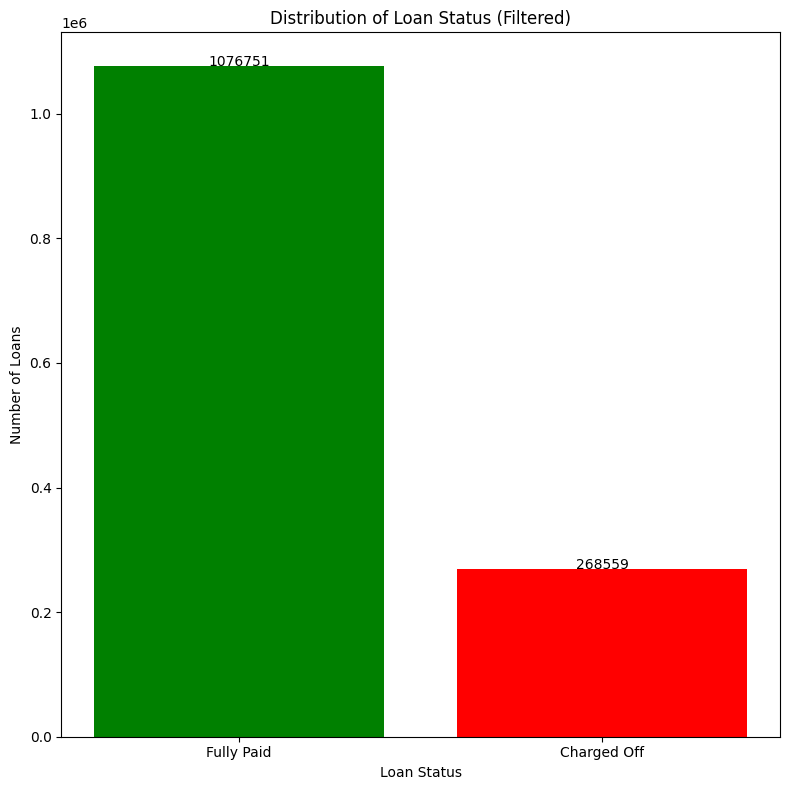

In [11]:
""" visualize the distribution of loan_status after filtering
using a simple bar chart """

status_counts = df['loan_status'].value_counts()
labels = status_counts.index
values = status_counts.values

print(values)

plt.figure(figsize=(8, 8))
plt.bar(labels, values, color=['green', 'red'])
plt.title("Distribution of Loan Status (Filtered)")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

# adding the count number on top of each bar
for i in range(len(labels)):
    plt.text(labels[i], values[i] + 5, str(values[i]), ha='center')

plt.tight_layout()
plt.show()

### 3. Exploring the Dataset Features

In [12]:
""" lets separate the columns into numerical and text
so we can explore each type properly """

num_cols = []
text_cols = []

for col in df.columns:
    col_type = df[col].dtype
    if col_type == 'object' or col_type == 'str':
        text_cols.append(col)
    else:
        num_cols.append(col)

print("Numerical columns:", len(num_cols))
print("Text columns:", len(text_cols))

print("\n--------------------------------------------------")

print("\nNumerical columns list:")
for i in range(len(num_cols)):
    print(i, "-->", num_cols[i])

print("\n--------------------------------------------------")

print("\nText columns list:")
for i in range(len(text_cols)):
    print(i, "-->", text_cols[i])

Numerical columns: 113
Text columns: 38

--------------------------------------------------

Numerical columns list:
0 --> member_id
1 --> loan_amnt
2 --> funded_amnt
3 --> funded_amnt_inv
4 --> int_rate
5 --> installment
6 --> annual_inc
7 --> dti
8 --> delinq_2yrs
9 --> fico_range_low
10 --> fico_range_high
11 --> inq_last_6mths
12 --> mths_since_last_delinq
13 --> mths_since_last_record
14 --> open_acc
15 --> pub_rec
16 --> revol_bal
17 --> revol_util
18 --> total_acc
19 --> out_prncp
20 --> out_prncp_inv
21 --> total_pymnt
22 --> total_pymnt_inv
23 --> total_rec_prncp
24 --> total_rec_int
25 --> total_rec_late_fee
26 --> recoveries
27 --> collection_recovery_fee
28 --> last_pymnt_amnt
29 --> last_fico_range_high
30 --> last_fico_range_low
31 --> collections_12_mths_ex_med
32 --> mths_since_last_major_derog
33 --> policy_code
34 --> annual_inc_joint
35 --> dti_joint
36 --> acc_now_delinq
37 --> tot_coll_amt
38 --> tot_cur_bal
39 --> open_acc_6m
40 --> open_act_il
41 --> open_il_12m


In [13]:
""" exploring each text column to see
how many unique values it has and what they look like
if a column has 15 or less unique values we print all of them
if it has more than 15 we just show the top 5 """

for col in text_cols:
    num_unique = df[col].nunique()
    print("Column:", col)
    print("Unique values:", num_unique)
    if num_unique <= 15:
        counts = df[col].value_counts()
        print(counts)
    else:
        print("(too many unique values to display, showing top 5)")
        top5 = df[col].value_counts()
        top5 = top5.head(5)
        print(top5)
    print("--------------------------------------------------")

Column: id
Unique values: 1345310
(too many unique values to display, showing top 5)
id
88224441    1
68407277    1
68355089    1
68341763    1
68476807    1
Name: count, dtype: int64
--------------------------------------------------
Column: term
Unique values: 2
term
36 months    1020743
60 months     324567
Name: count, dtype: int64
--------------------------------------------------
Column: grade
Unique values: 7
grade
B    392741
C    381686
A    235090
D    200953
E     93650
F     32058
G      9132
Name: count, dtype: int64
--------------------------------------------------
Column: sub_grade
Unique values: 35
(too many unique values to display, showing top 5)
sub_grade
C1    85494
B4    83199
B5    82538
B3    81827
C2    79213
Name: count, dtype: int64
--------------------------------------------------
Column: emp_title
Unique values: 378353
(too many unique values to display, showing top 5)
emp_title
Teacher             21268
Manager             19470
Owner               10302


In [14]:
""" exploring each numerical column to see how many unique values it has
columns with 0 unique values are completely empty
columns with 1 unique value are useless for prediction """

print("Numerical Columns - Unique Value Counts\n")
for col in num_cols:
    num_unique = df[col].nunique()
    padded_name = col.ljust(50)
    print(padded_name, num_unique, "unique values")

Numerical Columns - Unique Value Counts

member_id                                          0 unique values
loan_amnt                                          1556 unique values
funded_amnt                                        1556 unique values
funded_amnt_inv                                    9016 unique values
int_rate                                           654 unique values
installment                                        83307 unique values
annual_inc                                         64362 unique values
dti                                                7067 unique values
delinq_2yrs                                        31 unique values
fico_range_low                                     40 unique values
fico_range_high                                    40 unique values
inq_last_6mths                                     9 unique values
mths_since_last_delinq                             163 unique values
mths_since_last_record                             126 unique

In [15]:
""" finding numerical columns that are useless
either completely empty or have only one value """

print("Columns with 0 unique values (empty)\n")
for col in num_cols:
    num_unique = df[col].nunique()
    if num_unique == 0:
        print(col, "--> all null")

print("\n--------------------------------------------------")

print("\nColumns with only 1 unique value (useless)\n")
for col in num_cols:
    num_unique = df[col].nunique()
    if num_unique == 1:
        the_value = df[col].dropna().unique()
        first_value = the_value[0]
        print(col, "--> only value:", int(first_value))

Columns with 0 unique values (empty)

member_id --> all null

--------------------------------------------------

Columns with only 1 unique value (useless)

out_prncp --> only value: 0
out_prncp_inv --> only value: 0
policy_code --> only value: 1
deferral_term --> only value: 3
hardship_length --> only value: 3


In [16]:
""" checking if any numerical columns have negative values
some columns should never be negative """

print("Checking for negative values in numerical columns\n")
found_any = False

for col in num_cols:
    col_min = df[col].min()
    if col_min < 0:
        padded_name = col.ljust(50)
        print(padded_name, "min value:", col_min)
        found_any = True

if found_any == False:
    print("No columns with negative values found")

Checking for negative values in numerical columns

dti                                                min value: -1.0
total_rec_late_fee                                 min value: -5.1e-09


In [17]:
""" checking if any two columns have the exact same values in every row
if they do one of them is a duplicate """

print("Checking for duplicate columns\n")
already_checked = []
found_any = False

for col1 in df.columns:
    for col2 in df.columns:
        if col1 == col2:
            continue
        if col2 in already_checked:
            continue
        is_same = df[col1].equals(df[col2])
        if is_same == True:
            print(col1, "is identical to", col2)
            found_any = True
    already_checked.append(col1)

if found_any == False:
    print("No duplicate columns found")

Checking for duplicate columns

out_prncp is identical to out_prncp_inv
deferral_term is identical to hardship_length


In [18]:
""" checking which columns have missing values
we only print columns where missing is above 0 """

print("Dataset Shape")
row_count = len(df)
col_count = len(df.columns)
print("Rows:", row_count, "Columns:", col_count)

print("\n--------------------------------------------------")

total_rows = len(df)
missing_count = df.isnull().sum()
missing_data = (missing_count / total_rows) * 100
sorted_missing = missing_data.sort_values(ascending=False)

print("\nColumns with Missing Values\n")
for col in sorted_missing.index:
    pct = round(sorted_missing[col], 2)
    if pct > 0:
        padded_name = col.ljust(50)
        print(padded_name, pct, "%")

Dataset Shape
Rows: 1345310 Columns: 151

--------------------------------------------------

Columns with Missing Values

member_id                                          100.0 %
next_pymnt_d                                       100.0 %
orig_projected_additional_accrued_interest         99.72 %
hardship_payoff_balance_amount                     99.57 %
hardship_last_payment_amount                       99.57 %
hardship_reason                                    99.57 %
hardship_type                                      99.57 %
hardship_status                                    99.57 %
hardship_amount                                    99.57 %
deferral_term                                      99.57 %
hardship_end_date                                  99.57 %
hardship_dpd                                       99.57 %
hardship_loan_status                               99.57 %
hardship_length                                    99.57 %
payment_plan_start_date                            

### 4. Initial Data Cleaning

In [19]:
""" step 1: dropping columns that have more than 50% missing values
if more than half the data is missing the column is not useful """

total_rows = len(df)
cols_to_drop = []

for col in df.columns:
    null_count = df[col].isnull().sum()
    pct = (null_count / total_rows) * 100
    if pct > 50:
        cols_to_drop.append(col)

print("Columns with more than 50% missing to drop:\n")
for col in cols_to_drop:
    null_count = df[col].isnull().sum()
    pct = (null_count / total_rows) * 100
    pct = round(pct, 2)
    padded = col.ljust(50)
    print(padded, pct, "%")

cols_before = len(df.columns)
df = df.drop(columns=cols_to_drop)
cols_after = len(df.columns)
dropped = cols_before - cols_after

print("\nColumns dropped:", dropped)
print("Columns remaining:", cols_after)

Columns with more than 50% missing to drop:

member_id                                          100.0 %
desc                                               90.82 %
mths_since_last_delinq                             50.45 %
mths_since_last_record                             83.01 %
next_pymnt_d                                       100.0 %
mths_since_last_major_derog                        73.7 %
annual_inc_joint                                   98.08 %
dti_joint                                          98.08 %
verification_status_joint                          98.1 %
open_acc_6m                                        60.04 %
open_act_il                                        60.04 %
open_il_12m                                        60.04 %
open_il_24m                                        60.04 %
mths_since_rcnt_il                                 61.1 %
total_bal_il                                       60.04 %
il_util                                            65.43 %
open_rv_12m   

In [20]:
""" step 2: dropping columns that have only 1 unique value
a column with the same value in every row gives the model zero information """

single_cols = []
for col in df.columns:
    num_unique = df[col].nunique()
    if num_unique == 1:
        single_cols.append(col)

print("Single value columns to drop:\n")
for col in single_cols:
    first_val = df[col].dropna().unique()
    val = first_val[0]
    print(col, "-->", val)

cols_before = len(df.columns)
df = df.drop(columns=single_cols)
cols_after = len(df.columns)
dropped = cols_before - cols_after

print("\nColumns dropped:", dropped)
print("Columns remaining:", cols_after)

Single value columns to drop:

pymnt_plan --> n
out_prncp --> 0.0
out_prncp_inv --> 0.0
policy_code --> 1.0
hardship_flag --> N

Columns dropped: 5
Columns remaining: 88


In [21]:
""" step 3: dropping columns we found useless
id and url have a unique value in every row so they are just identifiers
funded_amnt is identical to loan_amnt so it is a duplicate """

cols_to_drop = ['id', 'url', 'funded_amnt']

cols_before = len(df.columns)
df = df.drop(columns=cols_to_drop)
cols_after = len(df.columns)
dropped = cols_before - cols_after

print("Columns dropped:", dropped)
print("Columns remaining:", cols_after)

Columns dropped: 3
Columns remaining: 85


### 5. Advanced Data Cleaning, Feature Engineering & Machine Learning preparation

at this point we already did the basic stuff like dropping mostly empty columns and the obvious junk. now we need to be smarter and look at every remaining column to figure out what it actually means before we touch it again

we will use the data dictionary as our source of truth and split the work into phases. each phase has a clear job

## Catalogue

here is a short overview of the full data preparation pipeline

**Phase 1 - Manual Cleanup**
we drop the columns that cause data leakage and we fix two row-level issues found during the column review

**Phase 2 - Row-wise Feature Engineering**
we work on the columns one row at a time. part A cleans existing columns that are stored in a messy text format. part B creates new ratio features that show credit risk patterns more clearly

**Phase 3 - Train Validation Test Split**
this is the most important step. we split the data into a training set a validation set and a test set before we calculate any statistics

**Phase 4 - Missing Values Imputation**
we fill empty cells using statistics calculated from the training set only then we apply the same values to all three sets

**Phase 5 - Outlier Handling**
we clip extreme values in some columns to fix data quality issues

**Phase 6 - Categorical Encoding**
we convert every text column into numbers using ordinal encoding and one-hot encoding

**Phase 7 - Feature Scaling**
we put all features on the same scale so that big columns do not dominate small ones

**Phase 8 - Multicollinearity Filter**
we find pairs of columns that say almost the same thing and we drop one of them

**Phase 9 - Baseline Algorithm Comparison**
we train 4 different algorithms with class weighting and we compare their results on the validation set to find the best one

**Phase 10 - Baseline Training**
we train one baseline model on all features and look at which features it relies on most and lock in the final feature set

**Phase 11 - Final Clean Feature Lock-in**
we sweep through different feature counts and lock in the best one as our final feature set

In [22]:
""" before we start dropping or changing anything we need to actually
understand what each column means. the data dictionary has the official
description for almost every column so we just loop through and print
the name + description side by side
this becomes our reference sheet for every decision later """

#load the dictionary excel file
dict_path = '/content/LCDataDictionary.xlsx'
dd = pd.read_excel(dict_path)

# clean up whitespace in dictionary names so the lookup actually matches
dd['LoanStatNew'] = dd['LoanStatNew'].str.strip()

# counter to number the columns as we print them
i = 0
for col in df.columns:
    row = dd[dd['LoanStatNew'] == col]
    padded = col.ljust(40)
    if len(row) > 0:
        desc = row.iloc[0]['Description']
        i += 1
        print(i, padded, desc)
    else:
        # if a column isnt in the dictionary we still want to know it exists
        print(padded, "--> NOT FOUND in dictionary")
    print()

1 loan_amnt                                The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.

2 funded_amnt_inv                          The total amount committed by investors for that loan at that point in time.

3 term                                     The number of payments on the loan. Values are in months and can be either 36 or 60.

4 int_rate                                 Interest Rate on the loan

5 installment                              The monthly payment owed by the borrower if the loan originates.

6 grade                                    LC assigned loan grade

7 sub_grade                                LC assigned loan subgrade

8 emp_title                                The job title supplied by the Borrower when applying for the loan.*

9 emp_length                               Employment length in years. Possible values are between 0 and 

**Phase 1 - Manual Cleanup**

now that we understand what every column means we can do three cleanup operations

first we remove the columns that cause data leakage. data leakage happens when the model learns from information that we would not have at the moment of prediction. for example columns like total_pymnt and recoveries only get values after the loan was already issued. if we use these columns the model would basically predict a result we already know which is not a real prediction

second we drop all joint application rows. for these rows the income and dti only show the values of the main applicant after we already removed the joint columns. keeping them would confuse the model

third we replace negative dti values with nan. lending club uses negative numbers like -1 as a placeholder when they could not calculate the real dti. if we keep these values they would lower the median during phase 4 imputation

In [23]:
""" phase 1 manual cleanup
we only drop columns that are 100% guaranteed problems
we also fix two issues at the row level that we found during the column review
issue 1 the joint application rows
issue 2 negative dti values which are lending club placeholders

several categories of column drops
1 post-loan leakage anything that exists only after the loan was funded
2 text columns we cannot use like emp_title which has thousands of unique values
3 disbursement_method which is set after approval
4 lc-derived risk labels (grade and sub_grade) which are outputs of lc's
  own internal risk model not raw borrower data
5 geographic identifiers (addr_state and zip_code) which are both ethically
  questionable for credit decisions and not transferable across jurisdictions
"""
"""
ambiguous columns like
collections_12_mths_ex_med , acc_now_delinq , chargeoff_within_12_mths , can
stay because they could be pre-application
history and we will let feature importance in phase 10 rank them
if they have suspiciously high importance that signals leakage we missed
otherwise they were legitimate features
"""

""" first row level fix we drop the joint application rows
we already removed annual_inc_joint and dti_joint earlier so for joint applications
the income and dti only show the values of the main applicant
this would confuse the model so we just remove these rows
"""
joint_count = (df['application_type'] == 'Joint App').sum()
df = df[df['application_type'] != 'Joint App']
df = df.reset_index(drop=True)
print("dropped joint application rows:", joint_count)

# now drop the leakage and useless columns
leakage_cols = [
    # post-loan payment info only known after the loan started repaying
    'funded_amnt_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',

    # fico scores pulled AFTER the loan was issued
    'last_credit_pull_d',
    'last_fico_range_high',
    'last_fico_range_low',

    # only set after the borrower already charged off
    'debt_settlement_flag',

    # set after approval so technically post-decision
    'disbursement_method',

    # internal lc operational flag not a borrower feature
    'initial_list_status',

    # redundant or unusable free-text
    'title',
    'emp_title',

    """
    lc-derived risk labels produced by lendingclub's proprietary internal
    risk model not raw borrower data. using them would mean our model is
    learning to copy lc's existing classification instead of learning from
    the underlying financial signals. they would also fail to transfer to
    any deployment outside lc since no equivalent grade exists elsewhere
    """

    'grade',
    'sub_grade',

    """ geographic identifiers we deliberately exclude for two reasons
    first using a borrower's location to judge creditworthiness is
    ethically questionable and conflicts with fair lending principles
    second these features are us-specific and would not transfer to a
    saudi deployment where the geographic distribution and economic
    patterns are completely different"""


    'addr_state',
    'zip_code',

    # application_type is now uniform Individual after we dropped joint rows
    'application_type',
]

# filter to only drop cols that actually exist in df
existing_drops = []
for col in leakage_cols:
    if col in df.columns:
        existing_drops.append(col)

cols_before = len(df.columns)
df = df.drop(columns=existing_drops)
cols_after = len(df.columns)
dropped = cols_before - cols_after

""" second row level fix lending club uses negative dti values like -1 as a
placeholder when they could not calculate the real dti
we replace any negative dti with nan now so phase 4 can fill it correctly
with the median. if we keep negative values they would make the median
lower than the real value"""

# we count how many rows we will change before we change them
neg_dti_count = (df['dti'] < 0).sum()
df.loc[df['dti'] < 0, 'dti'] = np.nan
print("replaced negative dti placeholders with nan:", neg_dti_count)

print("\nPhase 1 Summary")
print("Reason: post-loan leakage, lc-derived labels, geographic identifiers, audit fixes")
print("Columns dropped:", dropped)
print("Columns remaining:", cols_after)
print()
print("Dropped columns:")
for col in existing_drops:
    print(col)

print("\n--------------------------------------------------")

print("\nNew dataframe shape:", df.shape)

dropped joint application rows: 25800
replaced negative dti placeholders with nan: 1

Phase 1 Summary
Reason: post-loan leakage, lc-derived labels, geographic identifiers, audit fixes
Columns dropped: 23
Columns remaining: 62

Dropped columns:
funded_amnt_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
last_credit_pull_d
last_fico_range_high
last_fico_range_low
debt_settlement_flag
disbursement_method
initial_list_status
title
emp_title
grade
sub_grade
addr_state
zip_code
application_type

--------------------------------------------------

New dataframe shape: (1319510, 62)


**Phase 2 - Row-wise Feature Engineering**

in this phase we work on the columns one row at a time. the strict rule is that every change uses values from one single row only. we do not use any value that comes from another row like a median or a mean. if we used those values we would have data leakage because we did not split the data yet

this phase has two parts

**Part A - Cleaning Existing Columns**
some columns are stored in a messy text format. for example "36 months" or "10+ years" or "Aug-2003". the model cannot do math on text so we need to convert these values into real numbers

**Part B - Creating New Features**
the original columns alone do not show all the credit risk patterns clearly. for example a high income alone does not tell us if a loan is affordable but the installment divided by the monthly income does. so we create some new ratio columns that combine existing values in useful ways

In [24]:
""" phase 2 part A cleaning existing columns
strict rule every transformation uses only values from one single row
no medians no means no aggregates

we have three cleaning steps in part A
step 1 term: remove the word "months" so "36 months" becomes the number 36
step 2 emp_length: convert "10+ years" and "< 1 year" and "5 years" into numbers
       we also create a flag column to remember which rows had a missing value
       because a missing emp_length often means the person is unemployed
step 3 earliest_cr_line: convert the date string into the number of months
       between earliest_cr_line and issue_d
       we use issue_d as the reference NOT today because today is 2026
       and the loan officer in 2015 could not see a credit history that long """

#step 1 convert term from "36 months" to 36
new_term = []
for val in df['term']:
    cleaned = val.replace('months', '').strip()
    cleaned_int = int(cleaned)
    new_term.append(cleaned_int)
df['term'] = new_term

""" step 2 emp_length conversion
first we save which rows have a missing emp_length value because this often
means the person is unemployed and the model should know that
then we convert the values into real numbers
later in phase 4 the missing values will be filled with the median but the
flag column will still tell the model that the original value was missing """

# build the missing flag BEFORE we change anything
emp_missing_flag = []
for val in df['emp_length']:
    if pd.isnull(val):
        emp_missing_flag.append(1)
    else:
        emp_missing_flag.append(0)
df['emp_length_was_missing'] = emp_missing_flag

#now we do the actual conversion to numbers
new_emp = []
for val in df['emp_length']:
    if pd.isnull(val):
        new_emp.append(np.nan)
    elif val == '< 1 year':
        new_emp.append(0)
    elif val == '10+ years':
        new_emp.append(10)
    else:
        cleaned = val.replace('years', '').replace('year', '').strip()
        new_emp.append(int(cleaned))
df['emp_length'] = new_emp

In [25]:
""" step 3 convert earliest_cr_line into credit_history_months
we measure the time from earliest_cr_line UP TO issue_d not up to today
this gives us the real credit history length that the loan officer would
have seen at the time of the application """

#we convert both date columns into real datetime objects
issue_dates = pd.to_datetime(df['issue_d'], format='%b-%Y')
cr_dates = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

months_history = []
for i in range(len(df)):
    issue = issue_dates.iloc[i]
    cr = cr_dates.iloc[i]
    diff_years = issue.year - cr.year
    diff_months = issue.month - cr.month
    total_months = (diff_years * 12) + diff_months
    months_history.append(total_months)

df['credit_history_months'] = months_history

In [26]:
""" we remove the original date columns now because we already extracted
the credit history feature we needed from them"""

#we dont need these anymore now that we have credit_history_months
df = df.drop(columns=['earliest_cr_line', 'issue_d'])

#quick check that the converted columns look clean and numeric
print("Sample of converted columns:")
print(df[['term', 'emp_length', 'credit_history_months']].head(10))
print()
print("New shape:", df.shape)

Sample of converted columns:
   term  emp_length  credit_history_months
0    36        10.0                    148
1    36        10.0                    192
2    60         3.0                    210
3    36         4.0                    338
4    36        10.0                    306
5    36        10.0                    202
6    36         6.0                    164
7    36        10.0                    253
8    36         3.0                    234
9    60         7.0                    126

New shape: (1319510, 62)


**Part B - Creating New Features**

now we move to the second part. we will create 7 new ratio columns that combine existing values to show credit risk more clearly. all the calculations are still row-wise so they are safe to do before the train test split

we add +1 to every denominator to avoid division by zero. for very large numbers like income the +1 is so small that it does not affect the result. for small numbers it just protects the calculation

three of the ratios use source columns that can be nan for borrowers with no credit history. since +1 only protects against zero not nan we fill the resulting nan ratios with 0. this is still row-wise because every row gets the same constant 0 with no statistics from other rows. logically a borrower with no credit limit reported has no leverage no delinquency rate and no loan-to-credit footprint to measure

In [27]:
"""phase 2 part B financial feature engineering
we create 7 new features by combining existing columns
all calculations are row-wise so each value uses one single row only

the 7 new features
1 installment_to_income_ratio: how much of the monthly income goes to this loan
2 loan_to_income_ratio: the loan size compared to the yearly income
3 revol_bal_to_income_ratio: the existing debt compared to the income
4 fico_avg: a single clean fico score instead of two correlated columns
5 delinquency_rate: serious delinquencies as a percentage of total accounts
6 debt_to_credit_ratio: the leverage across non-mortgage credit
7 loan_amnt_to_total_credit: the requested loan size compared to the total credit

we add +1 to every denominator to prevent division by zero. for large numbers
like income the +1 is too small to change the result so it does not hurt accuracy

we use vectorized pandas operations because a normal for loop on 1.3 million rows
would be very slow. each calculation is still row-wise mathematically just written
in a faster vector form

note for ratios 5 6 and 7 the source columns can have nan values for borrowers
with no credit history. since +1 only protects against zero not nan we fill
the resulting nan ratios with 0 because no credit limit reported logically means
no leverage no delinquency rate and no loan-to-credit footprint """

# feature 1 monthly affordability
#how much of the monthly income goes to this loan payment
monthly_income = (df['annual_inc'] / 12) + 1
df['installment_to_income_ratio'] = df['installment'] / monthly_income

#feature 2 loan size compared to the yearly income
income_safe = df['annual_inc'] + 1
df['loan_to_income_ratio'] = df['loan_amnt'] / income_safe

# feature 3 existing revolving debt compared to the income
# this shows how much debt the person already has before this new loan
df['revol_bal_to_income_ratio'] = df['revol_bal'] / income_safe

#feature 4 clean fico average
# fico_range_low and fico_range_high are the bounds of the same range
# so we average them and we drop the originals to keep the data clean
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df = df.drop(columns=['fico_range_low', 'fico_range_high'])

# feature 5 delinquency rate as a percentage
#5 delinquencies out of 50 accounts is way different from 5 out of 5
total_acc_safe = df['total_acc'] + 1
df['delinquency_rate'] = df['num_accts_ever_120_pd'] / total_acc_safe
#fill nan with 0 because no account info means no delinquency to report
df['delinquency_rate'] = df['delinquency_rate'].fillna(0)

# feature 6 overall debt-to-credit leverage
total_credit_safe = df['tot_hi_cred_lim'] + 1
df['debt_to_credit_ratio'] = df['total_bal_ex_mort'] / total_credit_safe
# fill nan with 0 because no credit limit means no leverage
df['debt_to_credit_ratio'] = df['debt_to_credit_ratio'].fillna(0)

# feature 7 requested loan size compared to the total existing credit
# a small loan with large existing credit = lower risk
df['loan_amnt_to_total_credit'] = df['loan_amnt'] / total_credit_safe
#fill nan with 0 because no existing credit footprint to compare against
df['loan_amnt_to_total_credit'] = df['loan_amnt_to_total_credit'].fillna(0)

#quick check that the new features have reasonable values
print("New engineered features summary")
new_features = [
    'installment_to_income_ratio',
    'loan_to_income_ratio',
    'revol_bal_to_income_ratio',
    'fico_avg',
    'delinquency_rate',
    'debt_to_credit_ratio',
    'loan_amnt_to_total_credit'
]

for col in new_features:
    col_min = df[col].min()
    col_max = df[col].max()
    col_mean = df[col].mean()
    col_min_round = round(col_min, 4)
    col_max_round = round(col_max, 4)
    col_mean_round = round(col_mean, 4)
    print(col, "| min:", col_min_round, "| max:", col_max_round, "| mean:", col_mean_round)

print("\n--------------------------------------------------")

""" inf/nan validation
we did add +1 smoothing but lets actually verify nothing slipped through
this catches any silent bugs before they propagate to the model """

print("\nchecking engineered features for inf and nan")
for col in new_features:
    inf_count = np.isinf(df[col]).sum()
    nan_count = df[col].isnull().sum()
    print(col, "| inf:", inf_count, "| nan:", nan_count)

print("\n--------------------------------------------------")

print("\nNew shape:", df.shape)
print("Sample of new features (first 5 rows)")
print(df[new_features].head())

New engineered features summary
installment_to_income_ratio | min: 0.0001 | max: 0.5257 | mean: 0.078
loan_to_income_ratio | min: 0.0002 | max: 1.3186 | mean: 0.2113
revol_bal_to_income_ratio | min: 0.0 | max: 10.2166 | mean: 0.2242
fico_avg | min: 627.0 | max: 847.5 | mean: 698.0267
delinquency_rate | min: 0.0 | max: 0.85 | mean: 0.0184
debt_to_credit_ratio | min: 0.0 | max: 10.0047 | mean: 0.4127
loan_amnt_to_total_credit | min: 0.0 | max: 25000.0 | mean: 0.2841

--------------------------------------------------

checking engineered features for inf and nan
installment_to_income_ratio | inf: 0 | nan: 0
loan_to_income_ratio | inf: 0 | nan: 0
revol_bal_to_income_ratio | inf: 0 | nan: 0
fico_avg | inf: 0 | nan: 0
delinquency_rate | inf: 0 | nan: 0
debt_to_credit_ratio | inf: 0 | nan: 0
loan_amnt_to_total_credit | inf: 0 | nan: 0

--------------------------------------------------

New shape: (1319510, 67)
Sample of new features (first 5 rows)
   installment_to_income_ratio  loan_to_inc

**Phase 3 - Train Validation Test Split**

this is the most important step in the whole pipeline. we split the data into three sets in a 60/20/20 ratio

the training set (60 percent) is used to fit our models and to calculate any statistic like a median or a scaler. the validation set (20 percent) is used to compare different models and pick a winner. the test set (20 percent) stays completely locked until the very final evaluation. we never fit anything on the validation or test sets we only transform them

the split is stratified which means all three sets keep the same ratio of fully paid and charged off loans. we use random_state=42 so the split is reproducible. if we run the notebook again later we get the exact same three sets

In [28]:
""" phase 3 train validation test split 60/20/20
this cell does four things in order

step 1 convert loan_status from text to binary 0 fully paid 1 charged off
step 2 separate the features (X) from the target (y)
step 3 first split 80/20 into temp and test
step 4 second split the temp set 75/25 into train and val
final result is 60% train 20% val 20% test

we have to do the split in two passes because train_test_split only splits
into 2 parts at a time

each set has its own job
train: used to fit models and to calculate any statistics like medians and scalers
val: used to compare models tune hyperparameters and pick a winner
     this protects the test set from being seen too early
test: stays locked until the very final evaluation

stratified split preserves the original class ratio in all 3 sets """

# step 1 convert target to binary 0 = fully paid 1 = charged off
new_target = []
for val in df['loan_status']:
    if val == 'Fully Paid':
        new_target.append(0)
    else:
        new_target.append(1)
df['loan_status'] = new_target

# step 2 separate features and target
y = df['loan_status']
X = df.drop(columns=['loan_status'])

# step 3 first split: 80% (train+val) vs 20% (test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# step 4 second split: 60% train vs 20% val (75/25 of the temp set)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

In [29]:
""" verify the 60/20/20 split worked correctly
and class ratio is preserved across all 3 sets """

print("Shapes after 60/20/20 split")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("\n--------------------------------------------------")

# verify class distribution preserved in all sets
print("\nclass distribution check")

train_counts = y_train.value_counts()
val_counts = y_val.value_counts()
test_counts = y_test.value_counts()

for label in [0, 1]:
    train_pct = round((train_counts[label] / len(y_train)) * 100, 2)
    val_pct = round((val_counts[label] / len(y_val)) * 100, 2)
    test_pct = round((test_counts[label] / len(y_test)) * 100, 2)
    print("class", label)
    print("  train:", train_counts[label], "rows", train_pct, "%")
    print("  val:  ", val_counts[label], "rows", val_pct, "%")
    print("  test: ", test_counts[label], "rows", test_pct, "%")

Shapes after 60/20/20 split
X_train: (791706, 66)
X_val: (263902, 66)
X_test: (263902, 66)
y_train: (791706,)
y_val: (263902,)
y_test: (263902,)

--------------------------------------------------

class distribution check
class 0
  train: 634377 rows 80.13 %
  val:   211459 rows 80.13 %
  test:  211459 rows 80.13 %
class 1
  train: 157329 rows 19.87 %
  val:   52443 rows 19.87 %
  test:  52443 rows 19.87 %


**Phase 4 - Missing Values Imputation**

we still have empty cells in some numerical and categorical columns. the model cannot work with empty values so we need to fill them

the key rule is that the medians and modes are calculated from X_train ONLY. then we use those exact same values to fill the empty cells in all three sets X_train X_val and X_test. if we calculated the medians from the full data the validation and test sets would secretly leak information into our training process

we use the median for numerical columns because it is robust against outliers and we use the mode for categorical columns which is just the most common value. we also save these values in dictionaries because the streamlit app will need them later when a new applicant has missing fields

In [30]:
""" phase 4 missing values imputation
strict rule we calculate medians and modes ONLY from X_train
then apply those same values to fill nulls in ALL THREE sets X_train X_val and X_test
X_val and X_test never contribute to calculating fill values

we use median for numerical because loan data is skewed and median is robust
to outliers like 9 million dollar incomes
we use mode for categorical which is just the most common value

the dictionaries get saved later for the streamlit app
when a new applicant has missing fields we apply the same fills """

# step 1 separate columns into numerical and categorical
num_cols = []
cat_cols = []

for col in X_train.columns:
    col_type = X_train[col].dtype
    if col_type == 'object' or col_type == 'str':
        cat_cols.append(col)
    else:
        num_cols.append(col)

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

print("\n--------------------------------------------------")

""" step 2 calculate medians from X_train only
we calculate a median for ALL numerical columns even the ones that have zero
empty cells right now. this way if X_val or X_test has a surprise empty cell
in any column we already have a fill value ready """

median_dict = {}
for col in num_cols:
    median_val = X_train[col].median()
    median_dict[col] = median_val

#step 3 calculate modes from X_train only
mode_dict = {}
for col in cat_cols:
    mode_val = X_train[col].mode()
    # mode returns a series so we take the first value
    mode_dict[col] = mode_val[0]

#we print only a small sample so the output is not huge
print("\nMedian/Mode values calculated from X_train (sample of 5)")
count = 0
for col in median_dict:
    if count >= 5:
        break
    print(col, "median:", median_dict[col])
    count = count + 1

count = 0
for col in mode_dict:
    if count >= 5:
        break
    print(col, "mode:", mode_dict[col])
    count = count + 1

Numerical columns: 63
Categorical columns: 3

--------------------------------------------------

Median/Mode values calculated from X_train (sample of 5)
loan_amnt median: 12000.0
term median: 36.0
int_rate median: 12.74
installment median: 373.22
emp_length median: 6.0
home_ownership mode: MORTGAGE
verification_status mode: Source Verified
purpose mode: debt_consolidation


In [31]:
""" step 4 apply the fill values to ALL THREE sets train val test
we use the same dictionaries on all sides so val and test are filled
with the medians and modes from training set only """

# fill numerical empty cells with the training medians
for col in num_cols:
    fill_val = median_dict[col]
    X_train[col] = X_train[col].fillna(fill_val)
    X_val[col] = X_val[col].fillna(fill_val)
    X_test[col] = X_test[col].fillna(fill_val)

# fill categorical empty cells with the training modes
for col in cat_cols:
    fill_val = mode_dict[col]
    X_train[col] = X_train[col].fillna(fill_val)
    X_val[col] = X_val[col].fillna(fill_val)
    X_test[col] = X_test[col].fillna(fill_val)

""" step 5 verify zero nulls remain in all three sets """

print("verification of null fill")
train_nulls_total = X_train.isnull().sum().sum()
val_nulls_total = X_val.isnull().sum().sum()
test_nulls_total = X_test.isnull().sum().sum()
print("total nulls remaining in x_train:", train_nulls_total)
print("total nulls remaining in x_val:", val_nulls_total)
print("total nulls remaining in x_test:", test_nulls_total)

verification of null fill
total nulls remaining in x_train: 0
total nulls remaining in x_val: 0
total nulls remaining in x_test: 0


**Phase 5 - Outlier Handling**

we clip extreme values in some columns early in the pipeline. this fixes data quality issues like income values of $1 or dti values above 999 percent which would otherwise damage models that are sensitive to scale like logistic regression and mlp

we calculate the cap thresholds from the training set only. then we apply the same caps to all three sets X_train X_val and X_test. if we calculated the caps from the full data the validation and test sets would secretly leak information into the training process

In [32]:
""" preparation for winsorization
we build a scanner to detect which numeric columns have extreme outliers
for every column we compare the maximum value to the 99th percentile (the normal ceiling)
if the max is more than 2 times the 99th percentile we flag the column as a candidate for clipping
the printed report calls this ratio "How_Crazy" because the higher the ratio the more extreme the outlier """

# grab only the numeric columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

outlier_report = []

for col in numeric_cols:
    # p99 is the 99th percentile our reference ceiling
    p99 = X_train[col].quantile(0.99)
    max_val = X_train[col].max()

    # avoid dividing by zero
    if p99 > 0:
        # how many times is the max bigger than the 99th percentile
        ratio = max_val / p99

        # if the ratio is more than 2 the column has extreme outliers
        if ratio > 2:
            outlier_report.append({
                'Column_Name': col,
                'Normal_Max (99%)': p99,
                'Crazy_Max (100%)': max_val,
                'How_Crazy (Ratio)': round(ratio, 2)
            })

# sort the report from highest ratio (most extreme) to lowest
outlier_df = pd.DataFrame(outlier_report).sort_values(by='How_Crazy (Ratio)', ascending=False)

print("Outliers Report (Candidates for Winsorization):")
print("-" * 55)
print(outlier_df.to_string(index=False))

Outliers Report (Candidates for Winsorization):
-------------------------------------------------------
                Column_Name  Normal_Max (99%)  Crazy_Max (100%)  How_Crazy (Ratio)
  loan_amnt_to_total_credit          1.020356      2.000000e+04           19601.00
               tot_coll_amt       4691.000000      9.152545e+06            1951.09
           total_rev_hi_lim     154296.400000      9.999999e+06              64.81
                 annual_inc     255000.000000      9.550000e+06              37.45
                    pub_rec          2.000000      6.100000e+01              30.50
                  tax_liens          2.000000      6.100000e+01              30.50
                  revol_bal      94884.850000      2.560703e+06              26.99
 collections_12_mths_ex_med          1.000000      2.000000e+01              20.00
         num_tl_90g_dpd_24m          2.000000      3.900000e+01              19.50
            tot_hi_cred_lim     756314.350000      9.999999e+06   

In [33]:
""" phase 5 winsorize outliers in raw and engineered columns
we calculate caps from X_train ONLY then apply the same caps to all three sets
X_train X_val and X_test

the cols_to_clip list has 9 columns total: 3 raw columns and 6 of the 7 engineered ratios
fico_avg is excluded because fico scores are always bounded between 300 and 850 by=
definition so it cannot have outliers
this also protects models like logistic regression and mlp which are sensitive to scale """

cols_to_clip = [
    'annual_inc',
    'dti',
    'revol_bal',
    'installment_to_income_ratio',
    'loan_to_income_ratio',
    'revol_bal_to_income_ratio',
    'delinquency_rate',
    'debt_to_credit_ratio',
    'loan_amnt_to_total_credit'
]

# calculate caps from x_train only
clip_caps = {}
for col in cols_to_clip:
    if col in X_train.columns:
        lower = X_train[col].quantile(0.01)
        upper = X_train[col].quantile(0.99)
        clip_caps[col] = (lower, upper)

# apply same caps to all three sets
for col in clip_caps:
    lower = clip_caps[col][0]
    upper = clip_caps[col][1]
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_val[col] = X_val[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

print("winsorization caps from x_train (1st and 99th percentile)")
for col in clip_caps:
    lower = round(clip_caps[col][0], 4)
    upper = round(clip_caps[col][1], 4)
    print(col, "| lower:", lower, "| upper:", upper)

# save the caps dict for streamlit later
joblib.dump(clip_caps, 'clip_caps.pkl')
print("\nsaved clip_caps.pkl")

winsorization caps from x_train (1st and 99th percentile)
annual_inc | lower: 18927.35 | upper: 255000.0
dti | lower: 1.81 | upper: 37.48
revol_bal | lower: 186.0 | upper: 94884.85
installment_to_income_ratio | lower: 0.0101 | upper: 0.1901
loan_to_income_ratio | lower: 0.0254 | upper: 0.4872
revol_bal_to_income_ratio | lower: 0.0027 | upper: 0.9188
delinquency_rate | lower: 0.0 | upper: 0.2222
debt_to_credit_ratio | lower: 0.0 | upper: 1.0234
loan_amnt_to_total_credit | lower: 0.0 | upper: 1.0204

saved clip_caps.pkl


**Phase 6 - Categorical Encoding**

models cannot work with text so we need to convert every text column into numbers

we use one-hot encoding for all the text columns we have. there is no natural order between values like home_ownership=RENT vs home_ownership=MORTGAGE so each unique value becomes its own column. we also set handle_unknown='ignore' so any new category in the validation or test set that the training set did not see becomes all zeros instead of crashing the program

In [34]:
from sklearn.preprocessing import OneHotEncoder

""" phase 6 categorical encoding
we convert text categorical columns into a numeric format the model can process
strict rule we fit the encoder on X_train ONLY then we transform all three sets
X_train X_val and X_test

we use one-hot encoding for every text column we have left
each unique value becomes its own column
handle_unknown='ignore' makes new categories in the validation or test set
become all zeros instead of crashing the program

we save the fitted encoder and the column list so the streamlit app can use
them later to encode new applicant inputs in the exact same way """

# step 1 identify the categorical columns
# we exclude the numeric columns because they are already in number format
cat_cols = []
for col in X_train.columns:
    col_type = X_train[col].dtype
    if col_type == 'object' or col_type == 'str':
        cat_cols.append(col)

print("Categorical columns to encode:", len(cat_cols))
for col in cat_cols:
    n_unique = X_train[col].nunique()
    print(col, "-->", n_unique, "unique values")

Categorical columns to encode: 3
home_ownership --> 6 unique values
verification_status --> 3 unique values
purpose --> 14 unique values


In [35]:
""" step 2 one-hot encoding for the text columns
fit on x_train ONLY then transform all three sets """

# every cat column gets one-hot encoded
onehot_cols = cat_cols.copy()

print("One-hot encoding these columns:")
for col in onehot_cols:
    print(col)

# we fit the encoder on X_train ONLY
# handle_unknown='ignore' makes new categories in the validation or test set become all zeros
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[onehot_cols])

# transform all three sets
train_encoded = encoder.transform(X_train[onehot_cols])
val_encoded = encoder.transform(X_val[onehot_cols])
test_encoded = encoder.transform(X_test[onehot_cols])

# we get the new column names like home_ownership_RENT etc
new_col_names = encoder.get_feature_names_out(onehot_cols)

# convert the numpy arrays back to dataframes with proper column names
train_encoded_df = pd.DataFrame(train_encoded, columns=new_col_names, index=X_train.index)
val_encoded_df = pd.DataFrame(val_encoded, columns=new_col_names, index=X_val.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=new_col_names, index=X_test.index)

# we drop the original text columns and we add the encoded ones
X_train = X_train.drop(columns=onehot_cols)
X_val = X_val.drop(columns=onehot_cols)
X_test = X_test.drop(columns=onehot_cols)

X_train = pd.concat([X_train, train_encoded_df], axis=1)
X_val = pd.concat([X_val, val_encoded_df], axis=1)
X_test = pd.concat([X_test, test_encoded_df], axis=1)

print("\n--------------------------------------------------")

# step 3 verify that the encoding worked
print("\nFinal shapes after encoding")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nSample of X_train (first 5 rows)")
print(X_train.head())

One-hot encoding these columns:
home_ownership
verification_status
purpose

--------------------------------------------------

Final shapes after encoding
X_train: (791706, 86)
X_val: (263902, 86)
X_test: (263902, 86)

Sample of X_train (first 5 rows)
        loan_amnt  term  int_rate  installment  emp_length  annual_inc    dti  \
851844     5000.0    36     15.31       174.09        10.0     70000.0  19.54   
513545     8000.0    36     15.05       277.52        10.0    130000.0  25.13   
961262    15000.0    36     11.39       493.86         0.0     70000.0  19.49   
685390    10800.0    36      8.19       339.39        10.0     56000.0  24.62   
525198    16000.0    60      9.44       335.57         2.0     97000.0  14.88   

        delinq_2yrs  inq_last_6mths  open_acc  ...  purpose_home_improvement  \
851844          0.0             0.0       8.0  ...                       0.0   
513545          0.0             0.0      17.0  ...                       1.0   
961262          0.0 

**Phase 7 - Feature Scaling**

some models like logistic regression and mlp need all features on the same scale otherwise large columns like annual_inc would dominate small columns like dti and the model would learn the wrong patterns. tree models like xgboost and random forest do not care about scale but we scale once for everyone so the model comparison is fair

we use StandardScaler which transforms each column to have mean 0 and standard deviation 1. we fit it on X_train only then we apply the same transformation to X_val and X_test. binary columns like one-hot encoded categories and the emp_length_was_missing flag are skipped because they are already 0 or 1 and scaling them would destroy their meaning

In [36]:
from sklearn.preprocessing import StandardScaler
""" phase 7 feature scaling
some models like logistic regression and mlp need features on the same scale
otherwise large-magnitude columns like annual_inc dominate small-magnitude
columns like dti. tree models like xgboost and random forest do not care
about scale but we scale once for everyone so the comparison is fair

we chose StandardScaler for two reasons
1 it centers each column at 0 with unit variance which is the textbook default
2 StandardScaler is sensitive to outliers but we already clipped them in phase 5
so this concern is no longer an issue

strict rules
1 we fit ONLY on X_train so the validation and test sets never leak into the scaler
2 we transform all three sets X_train X_val and X_test using the same fitted scaler
3 we skip the one-hot binary columns and the emp_length_was_missing flag
because they are already 0/1 and scaling would destroy their meaning
4 we save the fitted scaler so the streamlit app can use it later
to scale new applicant inputs the exact same way """


"""
step 1 figure out which columns are binary so we can skip them
binary = only contains 0 and 1 values
we identify these dynamically instead of hardcoding the list"""


 # check if its strictly 2 unique values both being 0 and 1
binary_cols = []
continuous_cols = []
for col in X_train.columns:
    unique_vals = X_train[col].unique()

    if len(unique_vals) == 2 and 0 in unique_vals and 1 in unique_vals:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print("scaling strategy")
print("binary columns to skip:", len(binary_cols))
print("continuous columns to scale:", len(continuous_cols))

print("\n--------------------------------------------------")

""" step 2 fit the scaler on X_train continuous columns only
this calculates the mean and std for each column from X_train
the validation and test sets never contribute to these statistics """

scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])

"""
step 3 transform all three sets using the fitted scaler
we get back numpy arrays so we wrap them back into dataframes
with the original column names and indexes preserved
"""
train_scaled = scaler.transform(X_train[continuous_cols])
val_scaled = scaler.transform(X_val[continuous_cols])
test_scaled = scaler.transform(X_test[continuous_cols])

# put the scaled values back into the dataframes
X_train[continuous_cols] = train_scaled
X_val[continuous_cols] = val_scaled
X_test[continuous_cols] = test_scaled

scaling strategy
binary columns to skip: 24
continuous columns to scale: 62

--------------------------------------------------


In [37]:
""" step 4 verification
after scaling the training set continuous columns should have
mean very close to 0 and std very close to 1
the test set will be slightly off from this because we used
training-set stats which is the correct behavior """

# check 5 sample columns to confirm scaling worked
# check 5 sample columns to confirm scaling worked
print("\nverification (sample of 5 continuous columns)")
sample_cols = continuous_cols[:5]
for col in sample_cols:
    train_mean = round(X_train[col].mean(), 4)
    train_std = round(X_train[col].std(), 4)

    val_mean = round(X_val[col].mean(), 4)
    val_std = round(X_val[col].std(), 4)

    test_mean = round(X_test[col].mean(), 4)
    test_std = round(X_test[col].std(), 4)

    print(col)
    print("  train mean:", train_mean, "| train std:", train_std)
    print("  val mean:  ", val_mean,   "| val std:  ", val_std)
    print("  test mean: ", test_mean,  "| test std: ", test_std)

print("\n--------------------------------------------------")

# step 5 save the scaler and the column list for streamlit
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(continuous_cols, 'continuous_cols.pkl')

print("\nsaved pipeline artifacts")
print("scaler.pkl - fitted standardscaler")
print("continuous_cols.pkl - list of columns the scaler was fit on")

print("\nfinal shapes")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


verification (sample of 5 continuous columns)
loan_amnt
  train mean: -0.0 | train std: 1.0
  val mean:   -0.0014 | val std:   0.9986
  test mean:  -0.0016 | test std:  0.9994
term
  train mean: -0.0 | train std: 1.0
  val mean:   -0.0006 | val std:   0.9996
  test mean:  -0.0017 | test std:  0.9989
int_rate
  train mean: -0.0 | train std: 1.0
  val mean:   -0.0019 | val std:   1.0005
  test mean:  -0.0078 | test std:  0.9954
installment
  train mean: 0.0 | train std: 1.0
  val mean:   -0.0011 | val std:   0.9991
  test mean:  -0.0021 | test std:  0.9999
emp_length
  train mean: -0.0 | train std: 1.0
  val mean:   -0.0031 | val std:   1.0015
  test mean:  -0.0023 | test std:  1.0012

--------------------------------------------------

saved pipeline artifacts
scaler.pkl - fitted standardscaler
continuous_cols.pkl - list of columns the scaler was fit on

final shapes
X_train: (791706, 86)
X_test: (263902, 86)


**Phase 8 - Multicollinearity Filter**

when two features carry almost the same information they confuse the model. logistic regression coefficients become unstable feature importance gets split between duplicates and we waste time training on redundant signal

we calculate the correlation matrix on the training set only then for any pair of features above 0.9 absolute correlation we drop one of them. we choose which one to drop using a 3-priority system

priority 1 if one of the two columns is in our whitelist of business-critical columns we always keep it and drop the other
priority 2 if both columns are in the whitelist we keep both and skip the pair
priority 3 otherwise we fall back to target correlation and drop the column with less predictive signal

one-hot encoded columns are skipped because dropping one would break the encoding scheme

In [38]:
""" phase 8 multicollinearity filter
we identify pairs of features with high correlation and drop the redundant ones

strategy
1 we only look at continuous columns (one-hot stays untouched)
2 correlation matrix is calculated on X_train ONLY no leakage
3 threshold is 0.9 = 90% absolute correlation
4 we use a 3-priority system to decide which column to drop from each pair
   priority 1: keep the column that is in our business whitelist
   priority 2: if both are whitelisted keep both
   priority 3: otherwise drop the one less correlated with the target
5 we drop the loser from all three sets X_train X_val and X_test
6 we save the dropped list so the streamlit app can mirror the drops """

"""
step 1 calculate the absolute correlation matrix on x_train continuous columns only
we use abs because both positive and negative high correlation = redundancy
 """
corr_matrix = X_train[continuous_cols].corr().abs()

""" step 2 walk through the upper triangle to find correlated pairs
upper triangle only so we dont count A-B and B-A as two separate pairs
we collect every pair above the 0.9 threshold for later inspection """

threshold = 0.9
correlated_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col_a = corr_matrix.columns[i]
        col_b = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        if corr_value > threshold:
            correlated_pairs.append((col_a, col_b, corr_value))

print("correlated pairs found above", threshold, "threshold:", len(correlated_pairs))
print()

# show all the pairs we found before deciding what to drop
for pair in correlated_pairs:
    rounded = round(pair[2], 4)
    print(pair[0], "<-->", pair[1], "| corr:", rounded)

correlated pairs found above 0.9 threshold: 5

loan_amnt <--> installment | corr: 0.9537
open_acc <--> num_sats | corr: 0.9833
tot_cur_bal <--> tot_hi_cred_lim | corr: 0.9755
num_actv_rev_tl <--> num_rev_tl_bal_gt_0 | corr: 0.9818
installment_to_income_ratio <--> loan_to_income_ratio | corr: 0.9486


In [39]:
""" step 3 for each pair decide which column to drop
we use a 3-priority system that combines a business whitelist with the target
correlation fallback. the priority order is documented in step 5 below """

""" why a whitelist
pure math might drop important business signals just because they correlate
with other features. for example int_rate is the bank's core risk pricing
so it must stay regardless of any correlation findings """

whitelist = [
    'int_rate',
    'installment',
    'installment_to_income_ratio',
    'fico_avg',
    'dti',
    'loan_amnt',
]

print("\ndomain-critical whitelist (always kept)")
for col in whitelist:
    print(col)

print("\n--------------------------------------------------")

""" step 4 calculate target correlation for the fallback rule
we only need this for pairs where neither column is whitelisted """

target_corr = {}
for col in continuous_cols:
    target_corr[col] = abs(X_train[col].corr(y_train))

""" step 5 decide which column to drop from each pair
priority 1 if one column is whitelisted drop the other
priority 2 if both are whitelisted skip this pair (keep both)
priority 3 otherwise drop the column with lower target correlation """

cols_to_drop = set()

for pair in correlated_pairs:
    col_a = pair[0]
    col_b = pair[1]
    a_is_whitelisted = col_a in whitelist
    b_is_whitelisted = col_b in whitelist

    # both whitelisted skip the pair
    if a_is_whitelisted and b_is_whitelisted:
        print("both whitelisted keeping both:", col_a, "and", col_b)
        continue

    # only col_a whitelisted drop col_b
    if a_is_whitelisted and not b_is_whitelisted:
        cols_to_drop.add(col_b)
        continue

    # only col_b whitelisted drop col_a
    if b_is_whitelisted and not a_is_whitelisted:
        cols_to_drop.add(col_a)
        continue

    """ neither is whitelisted fall back to target correlation
    drop the column with less predictive signal """
    target_a = target_corr[col_a]
    target_b = target_corr[col_b]
    if target_a >= target_b:
        cols_to_drop.add(col_b)
    else:
        cols_to_drop.add(col_a)

cols_to_drop = list(cols_to_drop)

print("\ncolumns to drop after multicollinearity filter:", len(cols_to_drop))
for col in cols_to_drop:
    rounded = round(target_corr[col], 4)
    print(col, "| target corr:", rounded)

print("\n--------------------------------------------------")

# step 6 actually drop selected columns from all three sets
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print("\nfinal shapes after multicollinearity filter")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

""" step 7 save the dropped column list for streamlit
the app needs to know which columns to remove from new applicant data
so the input matches what the model expects """

joblib.dump(cols_to_drop, 'multicollinearity_drops.pkl')
print("\nsaved multicollinearity_drops.pkl")


domain-critical whitelist (always kept)
int_rate
installment
installment_to_income_ratio
fico_avg
dti
loan_amnt

--------------------------------------------------
both whitelisted keeping both: loan_amnt and installment

columns to drop after multicollinearity filter: 4
loan_to_income_ratio | target corr: 0.1389
num_rev_tl_bal_gt_0 | target corr: 0.0701
num_sats | target corr: 0.0288
tot_cur_bal | target corr: 0.0662

--------------------------------------------------

final shapes after multicollinearity filter
X_train: (791706, 82)
X_val: (263902, 82)
X_test: (263902, 82)

saved multicollinearity_drops.pkl


**Phase 9 - Baseline Algorithm Comparison**

before locking in our champion algorithm for hyperparameter tuning, we run a clean comparison of 4 representative classical ml algorithms on the full preprocessed feature set. each algorithm uses its native class-weighting parameter to handle the 80/20 imbalance between fully paid and charged off loans.

we test 4 algorithms covering the major classification paradigms relevant to tabular credit data:

| algorithm | category |
|-----------|----------|
| XGBoost | gradient boosting (residual-based) |
| LightGBM | gradient boosting (histogram-based) |
| Random Forest | bagging |
| Logistic Regression | linear |

evaluation strictly on the validation set. test set remains locked. no synthetic data oversampling is used. native class weighting is the production-quality strategy for handling imbalanced credit data.

In [40]:
""" phase 1 step 1 install libraries and import everything we need """

import subprocess
subprocess.run(['pip', 'install', 'optuna', '-q'])
subprocess.run(['pip', 'install', 'lightgbm', '-q'])

import os
import time
import shutil
import joblib
from google.colab import drive
import optuna
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, average_precision_score, precision_recall_curve, make_scorer
from sklearn.calibration import CalibratedClassifierCV


In [41]:
""" phase 9 baseline algorithm comparison
4 algorithms each trained with native class weighting
no smote no synthetic data
clean comparison on full preprocessed features

evaluation on validation set test set stays locked """


# step 1 calculate class imbalance ratio for the weighting strategy
# this is the same ratio used as scale_pos_weight in xgboost
# class 0 count divided by class 1 count gives us the weight to apply to class 1
class_0_count = (y_train == 0).sum()
class_1_count = (y_train == 1).sum()
imbalance_ratio = class_0_count / class_1_count

print("class 0 (fully paid) count:", class_0_count)
print("class 1 (charged off) count:", class_1_count)
print("imbalance ratio:", round(imbalance_ratio, 2))

class 0 (fully paid) count: 634377
class 1 (charged off) count: 157329
imbalance ratio: 4.03


In [42]:
""" step 2 train all 4 models on the imbalanced training data
each model uses its own native class-weight parameter
no synthetic samples are generated for any model """

# storage for the comparison results
results = []

# helper function to evaluate a fitted model on validation set
# extracts predictions probabilities and computes 5 metrics
def evaluate_model(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    metrics = {
        'algorithm': model_name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred),
        'recall': recall_score(y_eval, y_pred),
        'f1': f1_score(y_eval, y_pred),
        'auc': roc_auc_score(y_eval, y_proba)
    }
    return metrics

# model 1 xgboost with scale_pos_weight
print("\n[1] xgboost + scale_pos_weight")
start = time.time()
model_xgb = xgb.XGBClassifier(
    tree_method='hist',
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio,
    n_jobs=-1
)
model_xgb.fit(X_train, y_train)
print("training time:", round(time.time() - start, 2), "s")
results.append(evaluate_model('XGBoost', model_xgb, X_val, y_val))

# model 2 lightgbm with class_weight balanced
# lightgbm prefers the string 'balanced' over manual weights
# verbose=-1 silences the lightgbm progress messages
print("\n[2] lightgbm + class_weight balanced")
start = time.time()
model_lgb = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
model_lgb.fit(X_train, y_train)
print("training time:", round(time.time() - start, 2), "s")
results.append(evaluate_model('LightGBM', model_lgb, X_val, y_val))

# model 3 random forest with class_weight balanced
print("\n[3] random forest + class_weight balanced")
start = time.time()
model_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)
print("training time:", round(time.time() - start, 2), "s")
results.append(evaluate_model('RandomForest', model_rf, X_val, y_val))

# model 4 logistic regression with class_weight balanced
# max_iter=1000 ensures convergence on our large training set
print("\n[4] logistic regression + class_weight balanced")
start = time.time()
model_lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)
model_lr.fit(X_train, y_train)
print("training time:", round(time.time() - start, 2), "s")
results.append(evaluate_model('LogisticRegression', model_lr, X_val, y_val))

print("\n--------------------------------------------------")
print("all 4 models trained successfully")


[1] xgboost + scale_pos_weight
training time: 5.57 s

[2] lightgbm + class_weight balanced
training time: 7.63 s

[3] random forest + class_weight balanced
training time: 114.35 s

[4] logistic regression + class_weight balanced
training time: 11.21 s

--------------------------------------------------
all 4 models trained successfully


In [43]:
""" step 3 compare all 4 models on validation set metrics """

print("\nVALIDATION SET RESULTS - 4 MODEL COMPARISON")
print("=" * 80)
print(f"{'algorithm':<20} {'accuracy':<10} {'precision':<10} {'recall':<10} {'f1':<10} {'auc':<10}")
print("-" * 80)

for r in results:
    print(f"{r['algorithm']:<20} "
          f"{r['accuracy']:<10.4f} {r['precision']:<10.4f} "
          f"{r['recall']:<10.4f} {r['f1']:<10.4f} {r['auc']:<10.4f}")

print("=" * 80)

# find winners by each metric
# we initialize each winner with the first model then loop through
# and replace the winner whenever we find a model with a better score
winner_recall = results[0]
winner_auc = results[0]
winner_f1 = results[0]

for r in results:
    # check if current model has better recall
    if r['recall'] > winner_recall['recall']:
        winner_recall = r

    # check if current model has better auc
    if r['auc'] > winner_auc['auc']:
        winner_auc = r

    # check if current model has better f1
    if r['f1'] > winner_f1['f1']:
        winner_f1 = r

print("\nWINNER BY RECALL:", winner_recall['algorithm'], "=", round(winner_recall['recall'], 4))
print("WINNER BY AUC:   ", winner_auc['algorithm'], "=", round(winner_auc['auc'], 4))
print("WINNER BY F1:    ", winner_f1['algorithm'], "=", round(winner_f1['f1'], 4))

# save results for later reference in the thesis
joblib.dump(results, 'phase9_baseline_results.pkl')
print("\nsaved phase9_baseline_results.pkl")


VALIDATION SET RESULTS - 4 MODEL COMPARISON
algorithm            accuracy   precision  recall     f1         auc       
--------------------------------------------------------------------------------
XGBoost              0.6642     0.3292     0.6648     0.4404     0.7272    
LightGBM             0.6549     0.3244     0.6808     0.4395     0.7277    
RandomForest         0.8032     0.5574     0.0461     0.0852     0.7115    
LogisticRegression   0.6642     0.3266     0.6497     0.4347     0.7191    

WINNER BY RECALL: LightGBM = 0.6808
WINNER BY AUC:    LightGBM = 0.7277
WINNER BY F1:     XGBoost = 0.4404

saved phase9_baseline_results.pkl


**Phase 10 - Baseline Training and cross algorithm feature importance**


before we lock in our final feature set in phase 11 we look at which features each of the 4 baseline models from phase 9 considered most important. each algorithm measures importance differently so checking all 4 gives us a stable cross-check on which features actually carry predictive signal across different model families

- lightgbm uses split-count importance: how many times each feature was picked as a split point across all trees
- xgboost uses gain-based importance: the average improvement each split brought to the model
- random forest uses gini importance: how much each feature reduced impurity across the forest
- logistic regression has no native importance attribute so we use the absolute value of each coefficient as a proxy. this works here because all features were scaled to mean=0 std=1 in phase 7 so the magnitudes are directly comparable


In [44]:
""" phase 10 step 1 lightgbm feature importance
we extract split-count scores from the lightgbm trained in phase 9
then normalize to percentages because lightgbm returns raw counts """

feature_names = X_train.columns.tolist()
n_features = len(feature_names)

# step 1a extract scores and normalize
lgb_scores = model_lgb.feature_importances_
lgb_total = 0
for s in lgb_scores:
    lgb_total = lgb_total + s

lgb_importance = []
for i in range(n_features):
    name = feature_names[i]
    pct = (lgb_scores[i] / lgb_total) * 100
    lgb_importance.append((name, pct))

""" step 1b sort descending using selection sort
at each step we find the highest remaining score and move it to the sorted list """

sorted_lgb = []
remaining = lgb_importance.copy()

while len(remaining) > 0:
    max_index = 0
    for i in range(1, len(remaining)):
        if remaining[i][1] > remaining[max_index][1]:
            max_index = i
    sorted_lgb.append(remaining[max_index])
    remaining.pop(max_index)

lgb_importance = sorted_lgb

# step 1c print the full ranking
print("LIGHTGBM - FEATURE IMPORTANCE RANKING")
print("=" * 60)
for i in range(len(lgb_importance)):
    name = lgb_importance[i][0]
    pct = round(lgb_importance[i][1], 2)
    print(f"{i+1:>3}. {name:<40} {pct}%")

LIGHTGBM - FEATURE IMPORTANCE RANKING
  1. int_rate                                 9.13%
  2. dti                                      5.77%
  3. installment_to_income_ratio              4.37%
  4. acc_open_past_24mths                     4.17%
  5. term                                     4.0%
  6. fico_avg                                 3.5%
  7. loan_amnt                                3.33%
  8. mo_sin_old_rev_tl_op                     3.13%
  9. num_actv_rev_tl                          3.1%
 10. loan_amnt_to_total_credit                3.03%
 11. revol_bal_to_income_ratio                2.97%
 12. annual_inc                               2.93%
 13. credit_history_months                    2.6%
 14. mths_since_recent_bc                     2.47%
 15. mort_acc                                 2.17%
 16. emp_length_was_missing                   2.17%
 17. total_bc_limit                           2.13%
 18. bc_open_to_buy                           2.03%
 19. revol_bal                

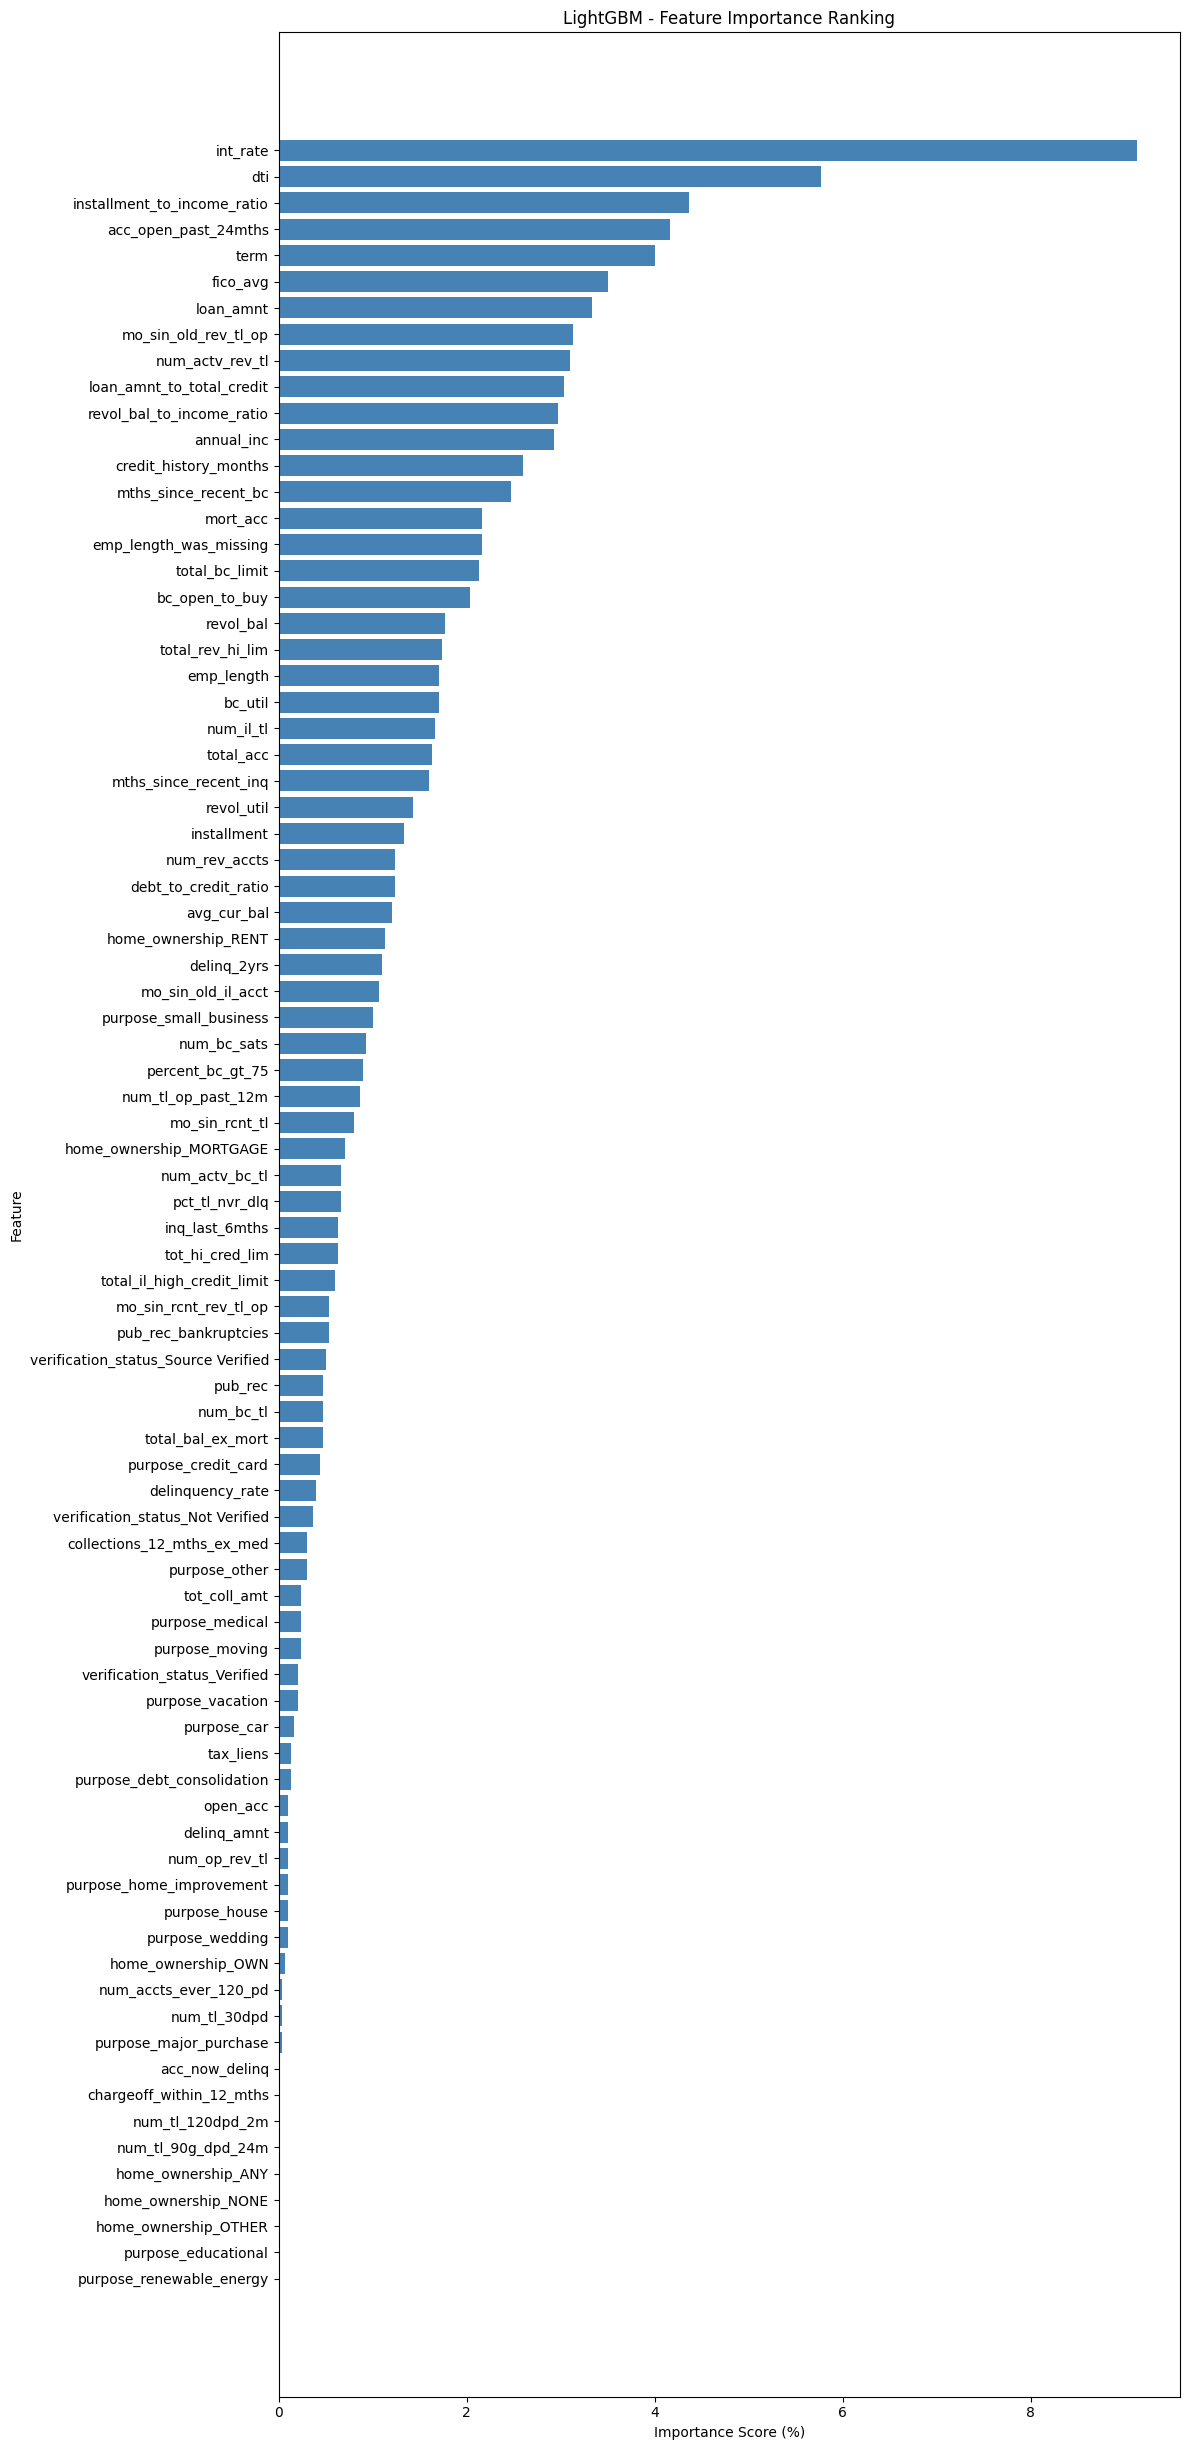

In [45]:
""" step 1d visualize lightgbm full importance as a horizontal bar chart
we use a tall figure so all features display clearly without squishing """

lgb_names = []
lgb_pct = []
for item in lgb_importance:
    lgb_names.append(item[0])
    lgb_pct.append(item[1])

lgb_names = lgb_names[::-1]
lgb_pct = lgb_pct[::-1]

n_features = len(lgb_names)
fig_height = max(12, n_features * 0.3)

plt.figure(figsize=(12, fig_height))
plt.barh(lgb_names, lgb_pct, color='steelblue')
plt.xlabel('Importance Score (%)')
plt.ylabel('Feature')
plt.title('LightGBM - Feature Importance Ranking')
plt.tight_layout()
plt.savefig('phase10_lgb_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [46]:
""" phase 10 step 2 xgboost feature importance
xgboost returns gain importance already normalized to sum to 1
so we just multiply by 100 to get percentages """

xgb_scores = model_xgb.feature_importances_

xgb_importance = []
for i in range(n_features):
    name = feature_names[i]
    pct = xgb_scores[i] * 100
    xgb_importance.append((name, pct))

# sort descending using selection sort
sorted_xgb = []
remaining = xgb_importance.copy()

while len(remaining) > 0:
    max_index = 0
    for i in range(1, len(remaining)):
        if remaining[i][1] > remaining[max_index][1]:
            max_index = i
    sorted_xgb.append(remaining[max_index])
    remaining.pop(max_index)

xgb_importance = sorted_xgb

print("XGBOOST - FEATURE IMPORTANCE RANKING (gain)")
print("=" * 60)
for i in range(len(xgb_importance)):
    name = xgb_importance[i][0]
    pct = round(xgb_importance[i][1], 2)
    print(f"{i+1:>3}. {name:<40} {pct}%")

XGBOOST - FEATURE IMPORTANCE RANKING (gain)
  1. int_rate                                 18.09000015258789%
  2. term                                     8.3100004196167%
  3. emp_length_was_missing                   4.420000076293945%
  4. acc_open_past_24mths                     3.299999952316284%
  5. verification_status_Not Verified         2.9600000381469727%
  6. home_ownership_MORTGAGE                  2.7899999618530273%
  7. home_ownership_RENT                      2.3399999141693115%
  8. purpose_small_business                   2.200000047683716%
  9. mort_acc                                 2.0799999237060547%
 10. fico_avg                                 2.0299999713897705%
 11. loan_amnt_to_total_credit                1.9500000476837158%
 12. installment_to_income_ratio              1.649999976158142%
 13. dti                                      1.6299999952316284%
 14. num_actv_rev_tl                          1.5299999713897705%
 15. avg_cur_bal                        

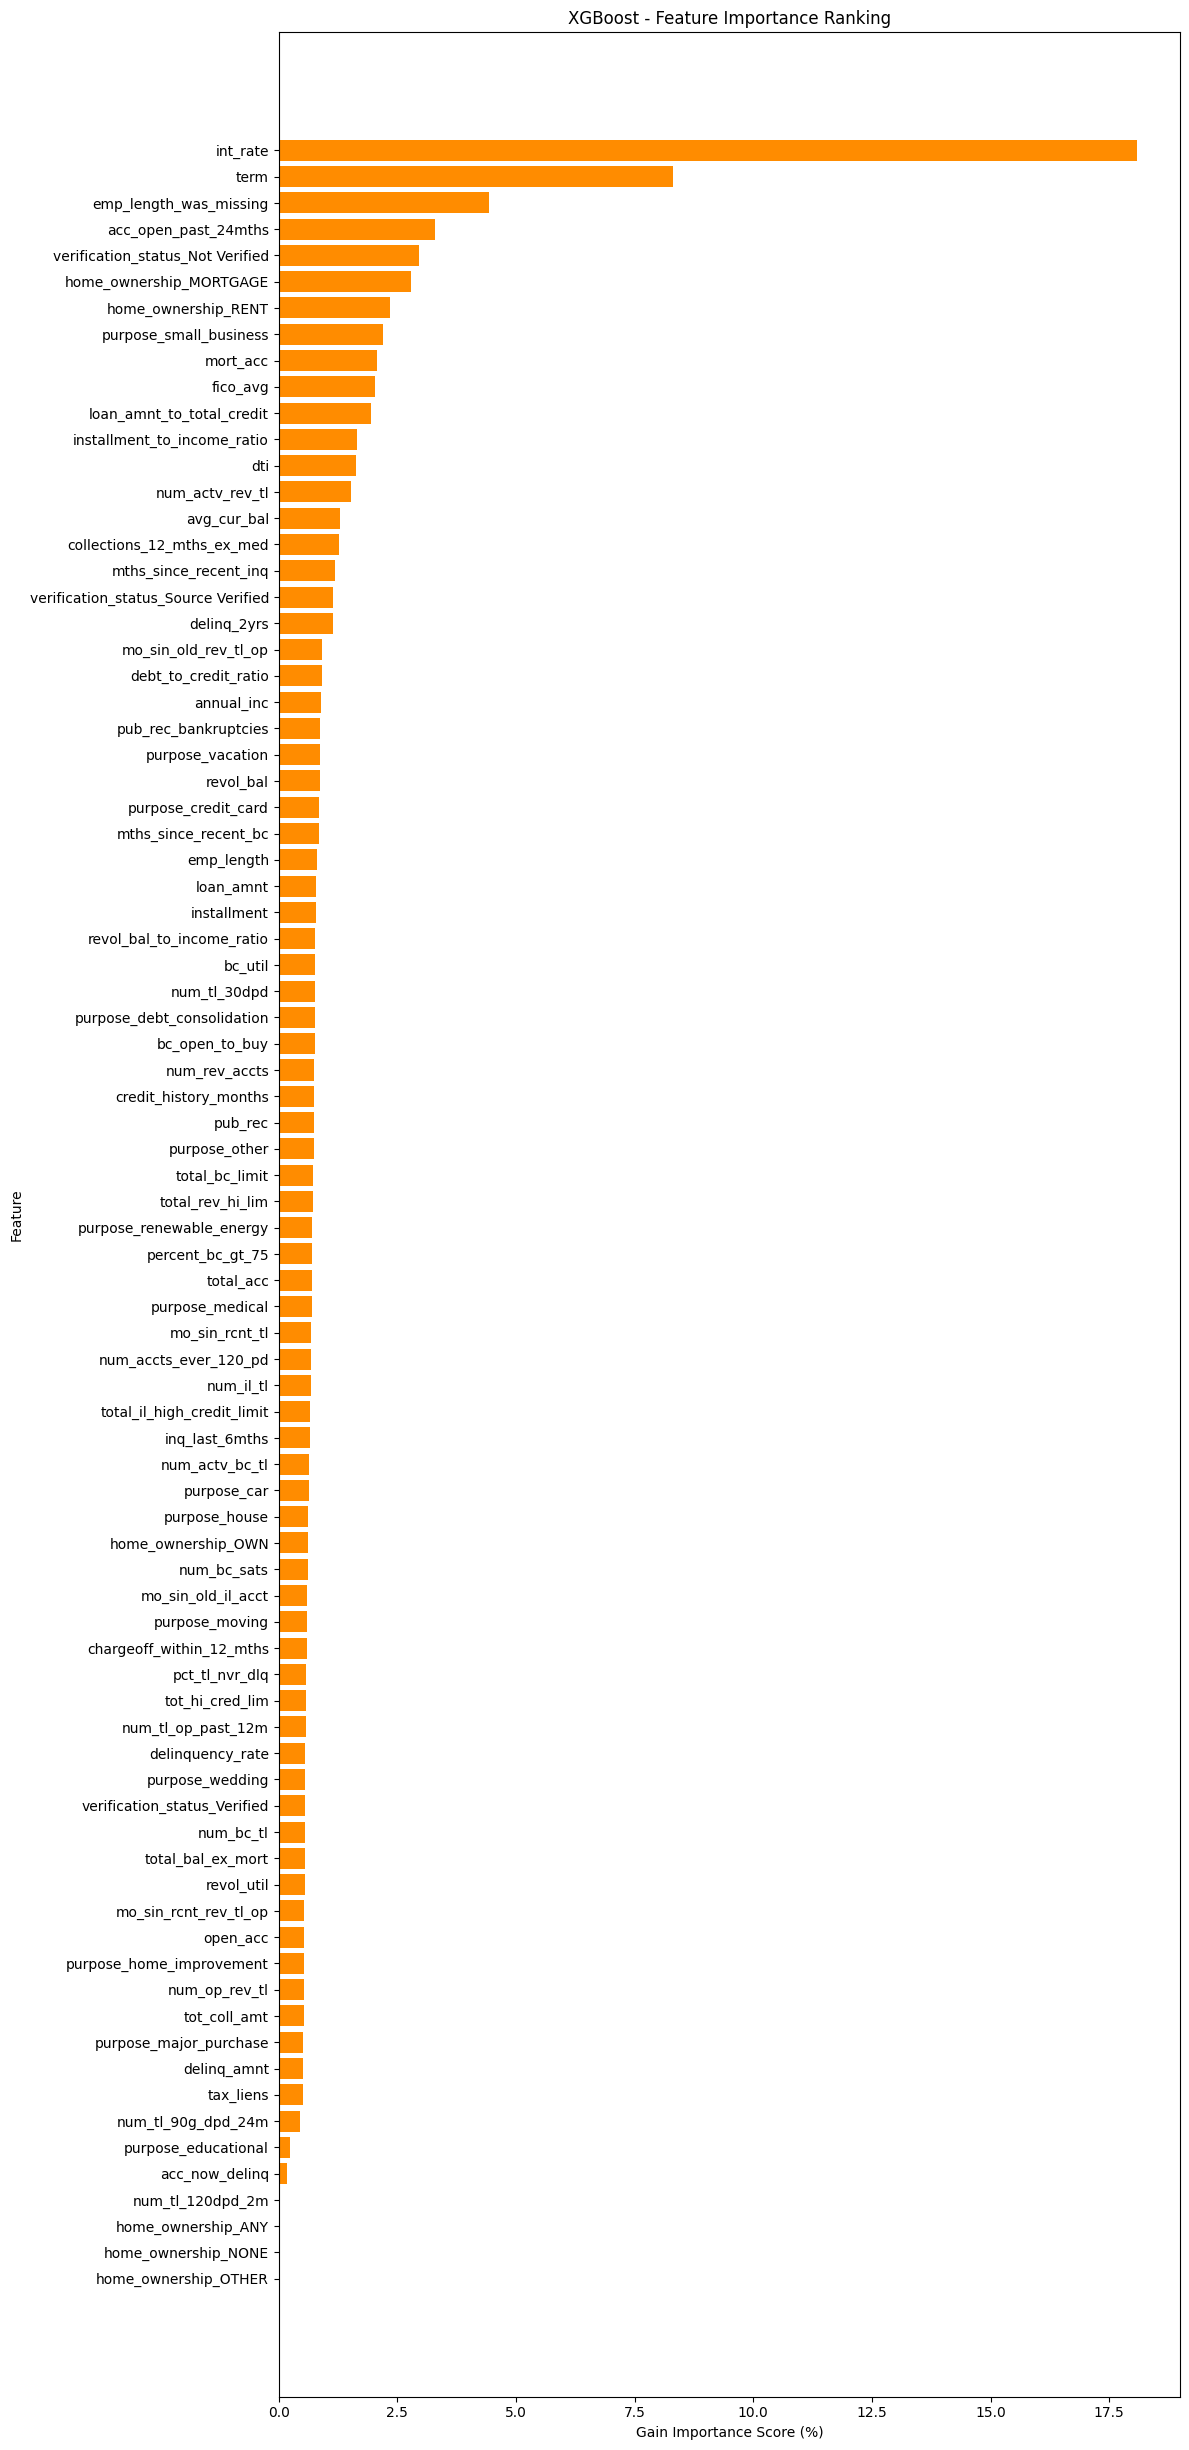

In [47]:
""" visualize xgboost full importance as a horizontal bar chart
we use a tall figure so all features display clearly without squishing """

xgb_names = []
xgb_pct = []
for item in xgb_importance:
    xgb_names.append(item[0])
    xgb_pct.append(item[1])

xgb_names = xgb_names[::-1]
xgb_pct = xgb_pct[::-1]

n_features = len(xgb_names)
fig_height = max(12, n_features * 0.3)

plt.figure(figsize=(12, fig_height))
plt.barh(xgb_names, xgb_pct, color='darkorange')
plt.xlabel('Gain Importance Score (%)')
plt.ylabel('Feature')
plt.title('XGBoost - Feature Importance Ranking')
plt.tight_layout()
plt.savefig('phase10_xgb_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [48]:
""" phase 10 step 3 random forest feature importance
random forest uses gini importance already normalized to sum to 1
so we just multiply by 100 to get percentages """

rf_scores = model_rf.feature_importances_

rf_importance = []
for i in range(n_features):
    name = feature_names[i]
    pct = rf_scores[i] * 100
    rf_importance.append((name, pct))

# sort descending using selection sort
sorted_rf = []
remaining = rf_importance.copy()

while len(remaining) > 0:
    max_index = 0
    for i in range(1, len(remaining)):
        if remaining[i][1] > remaining[max_index][1]:
            max_index = i
    sorted_rf.append(remaining[max_index])
    remaining.pop(max_index)

rf_importance = sorted_rf

print("RANDOM FOREST - FEATURE IMPORTANCE RANKING (gini)")
print("=" * 60)
for i in range(len(rf_importance)):
    name = rf_importance[i][0]
    pct = round(rf_importance[i][1], 2)
    print(f"{i+1:>3}. {name:<40} {pct}%")

RANDOM FOREST - FEATURE IMPORTANCE RANKING (gini)
  1. int_rate                                 7.18%
  2. dti                                      3.3%
  3. installment_to_income_ratio              3.27%
  4. loan_amnt_to_total_credit                2.87%
  5. debt_to_credit_ratio                     2.64%
  6. installment                              2.6%
  7. revol_util                               2.53%
  8. bc_open_to_buy                           2.53%
  9. credit_history_months                    2.53%
 10. revol_bal_to_income_ratio                2.51%
 11. avg_cur_bal                              2.47%
 12. revol_bal                                2.41%
 13. mo_sin_old_rev_tl_op                     2.4%
 14. annual_inc                               2.4%
 15. tot_hi_cred_lim                          2.4%
 16. mo_sin_old_il_acct                       2.35%
 17. fico_avg                                 2.35%
 18. term                                     2.34%
 19. total_bc_limit

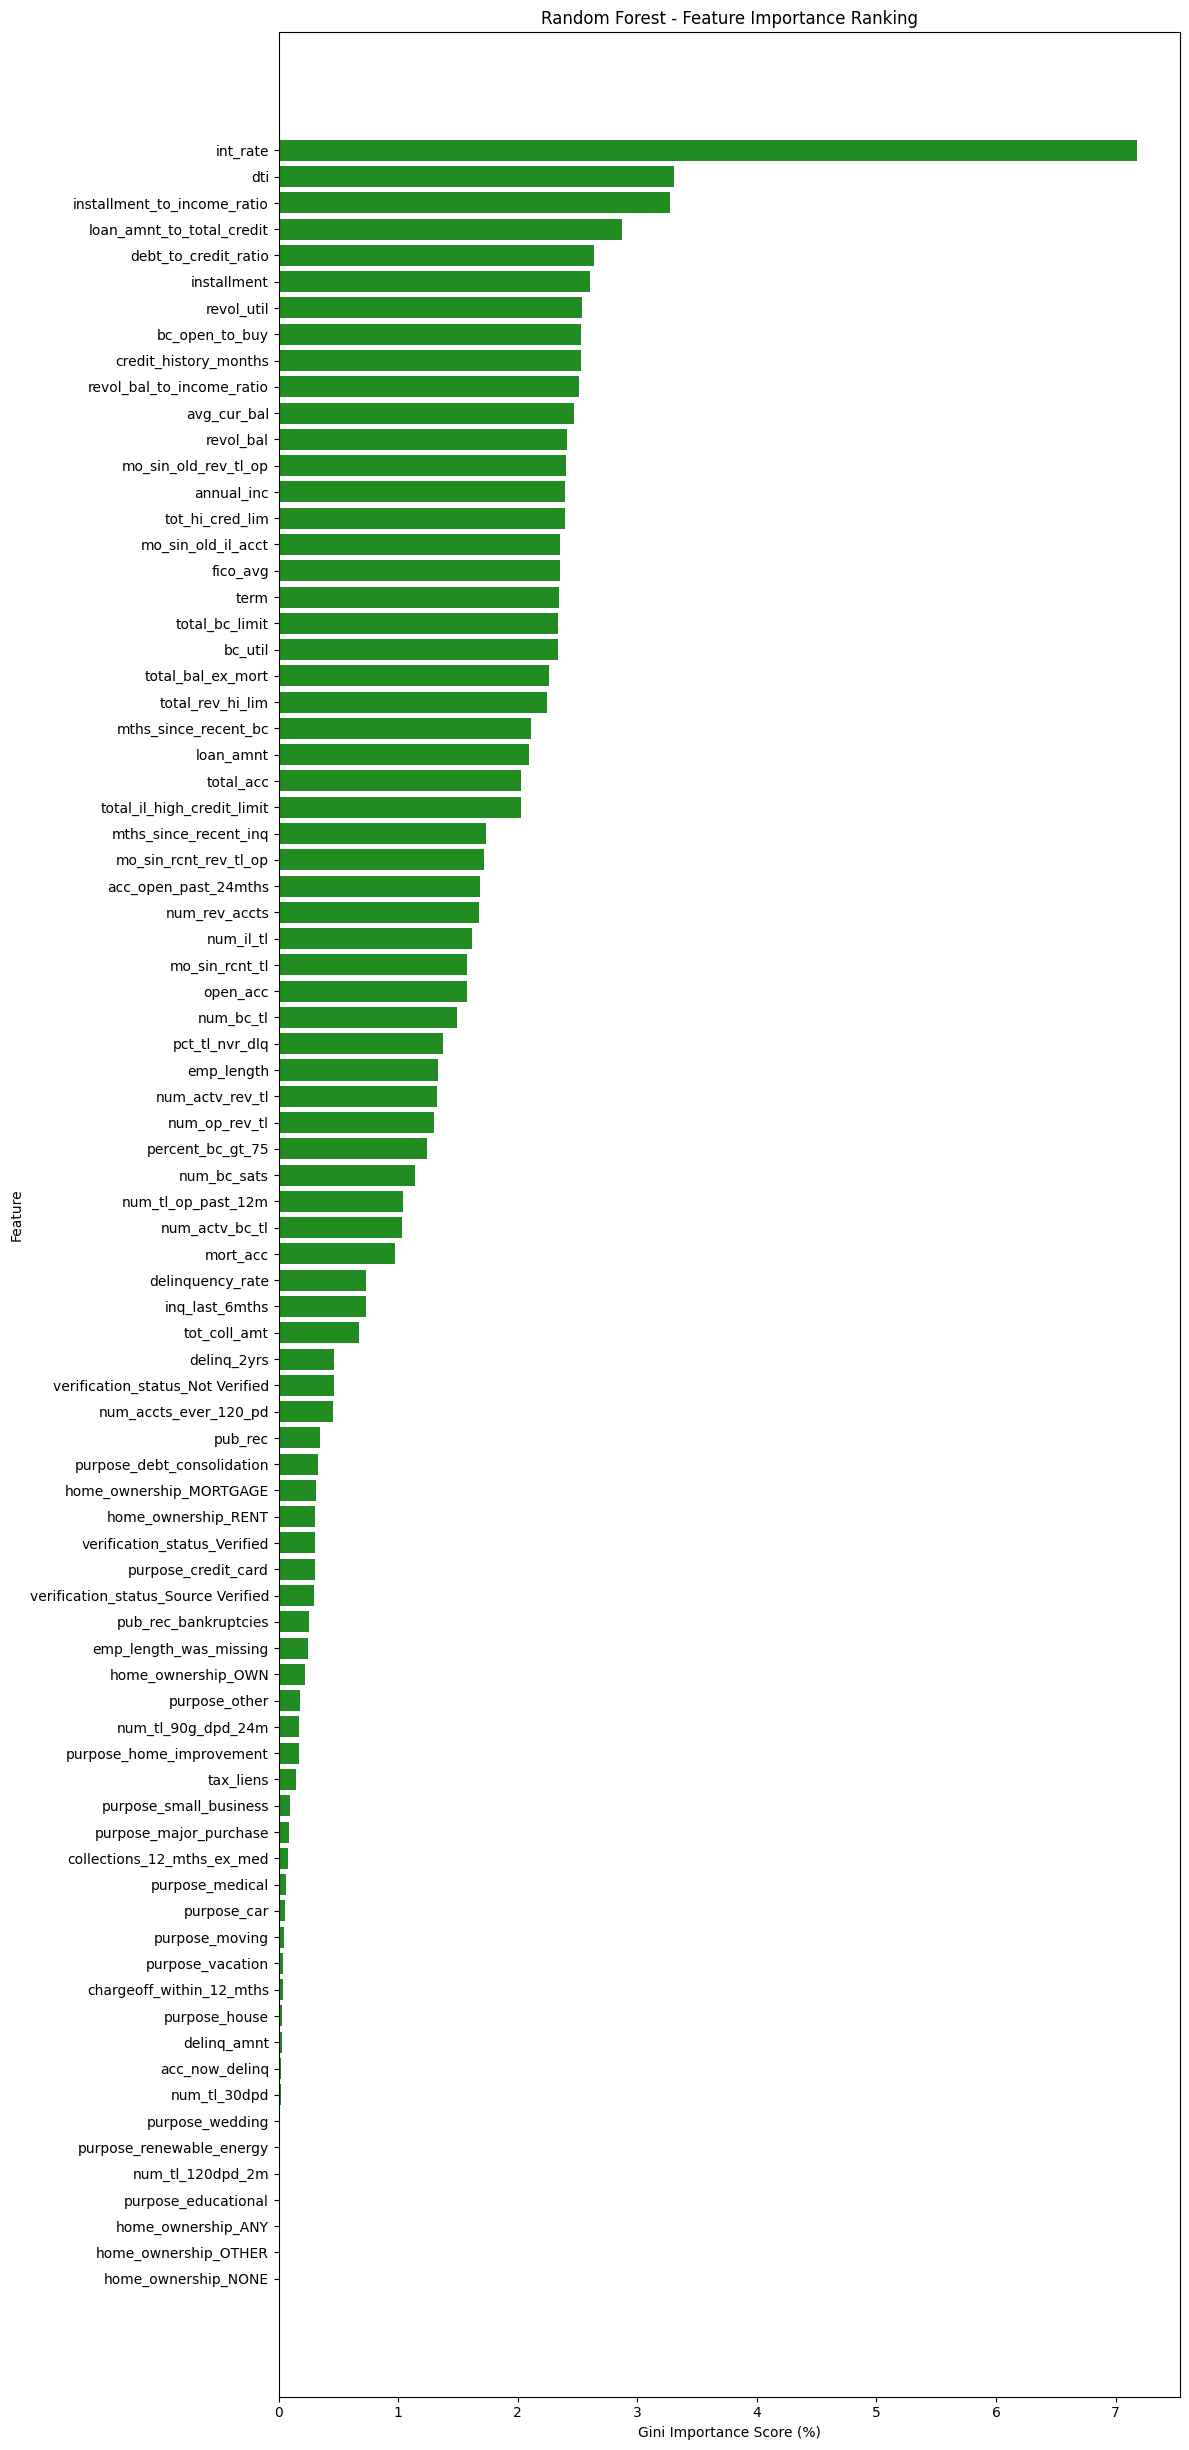

In [49]:
""" visualize random forest full importance as a horizontal bar chart
we use a tall figure so all features display clearly without squishing """

rf_names = []
rf_pct = []
for item in rf_importance:
    rf_names.append(item[0])
    rf_pct.append(item[1])

rf_names = rf_names[::-1]
rf_pct = rf_pct[::-1]

n_features = len(rf_names)
fig_height = max(12, n_features * 0.3)

plt.figure(figsize=(12, fig_height))
plt.barh(rf_names, rf_pct, color='forestgreen')
plt.xlabel('Gini Importance Score (%)')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance Ranking')
plt.tight_layout()
plt.savefig('phase10_rf_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [50]:
""" phase 10 step 4 logistic regression feature importance
logistic regression has no feature_importances_ attribute
we use the absolute value of each coefficient as a proxy for importance
this works because all features were scaled to mean=0 std=1 in phase 7
so the coefficient magnitudes are directly comparable

we take the absolute value because both negative and positive coefficients
indicate predictive signal just in different directions """

# coef_ has shape (1, n_features) so we take row 0
lr_coefs = model_lr.coef_[0]

# take the absolute value of each coefficient
lr_abs = []
for c in lr_coefs:
    if c < 0:
        lr_abs.append(-c)
    else:
        lr_abs.append(c)

# normalize to percentages
lr_total = 0
for v in lr_abs:
    lr_total = lr_total + v

lr_importance = []
for i in range(n_features):
    name = feature_names[i]
    pct = (lr_abs[i] / lr_total) * 100
    lr_importance.append((name, pct))

# sort descending using selection sort
sorted_lr = []
remaining = lr_importance.copy()

while len(remaining) > 0:
    max_index = 0
    for i in range(1, len(remaining)):
        if remaining[i][1] > remaining[max_index][1]:
            max_index = i
    sorted_lr.append(remaining[max_index])
    remaining.pop(max_index)

lr_importance = sorted_lr

print("LOGISTIC REGRESSION - FEATURE IMPORTANCE RANKING (|coefficients|)")
print("=" * 60)
for i in range(len(lr_importance)):
    name = lr_importance[i][0]
    pct = round(lr_importance[i][1], 2)
    print(f"{i+1:>3}. {name:<40} {pct}%")

LOGISTIC REGRESSION - FEATURE IMPORTANCE RANKING (|coefficients|)
  1. emp_length_was_missing                   8.25%
  2. purpose_small_business                   7.34%
  3. int_rate                                 4.81%
  4. term                                     4.7%
  5. purpose_car                              3.96%
  6. purpose_credit_card                      3.55%
  7. dti                                      3.16%
  8. purpose_wedding                          2.92%
  9. acc_open_past_24mths                     2.69%
 10. total_acc                                2.69%
 11. fico_avg                                 2.52%
 12. mo_sin_old_rev_tl_op                     2.33%
 13. credit_history_months                    2.33%
 14. purpose_debt_consolidation               2.18%
 15. home_ownership_MORTGAGE                  2.12%
 16. purpose_medical                          2.1%
 17. purpose_house                            1.97%
 18. purpose_moving                           1.92%


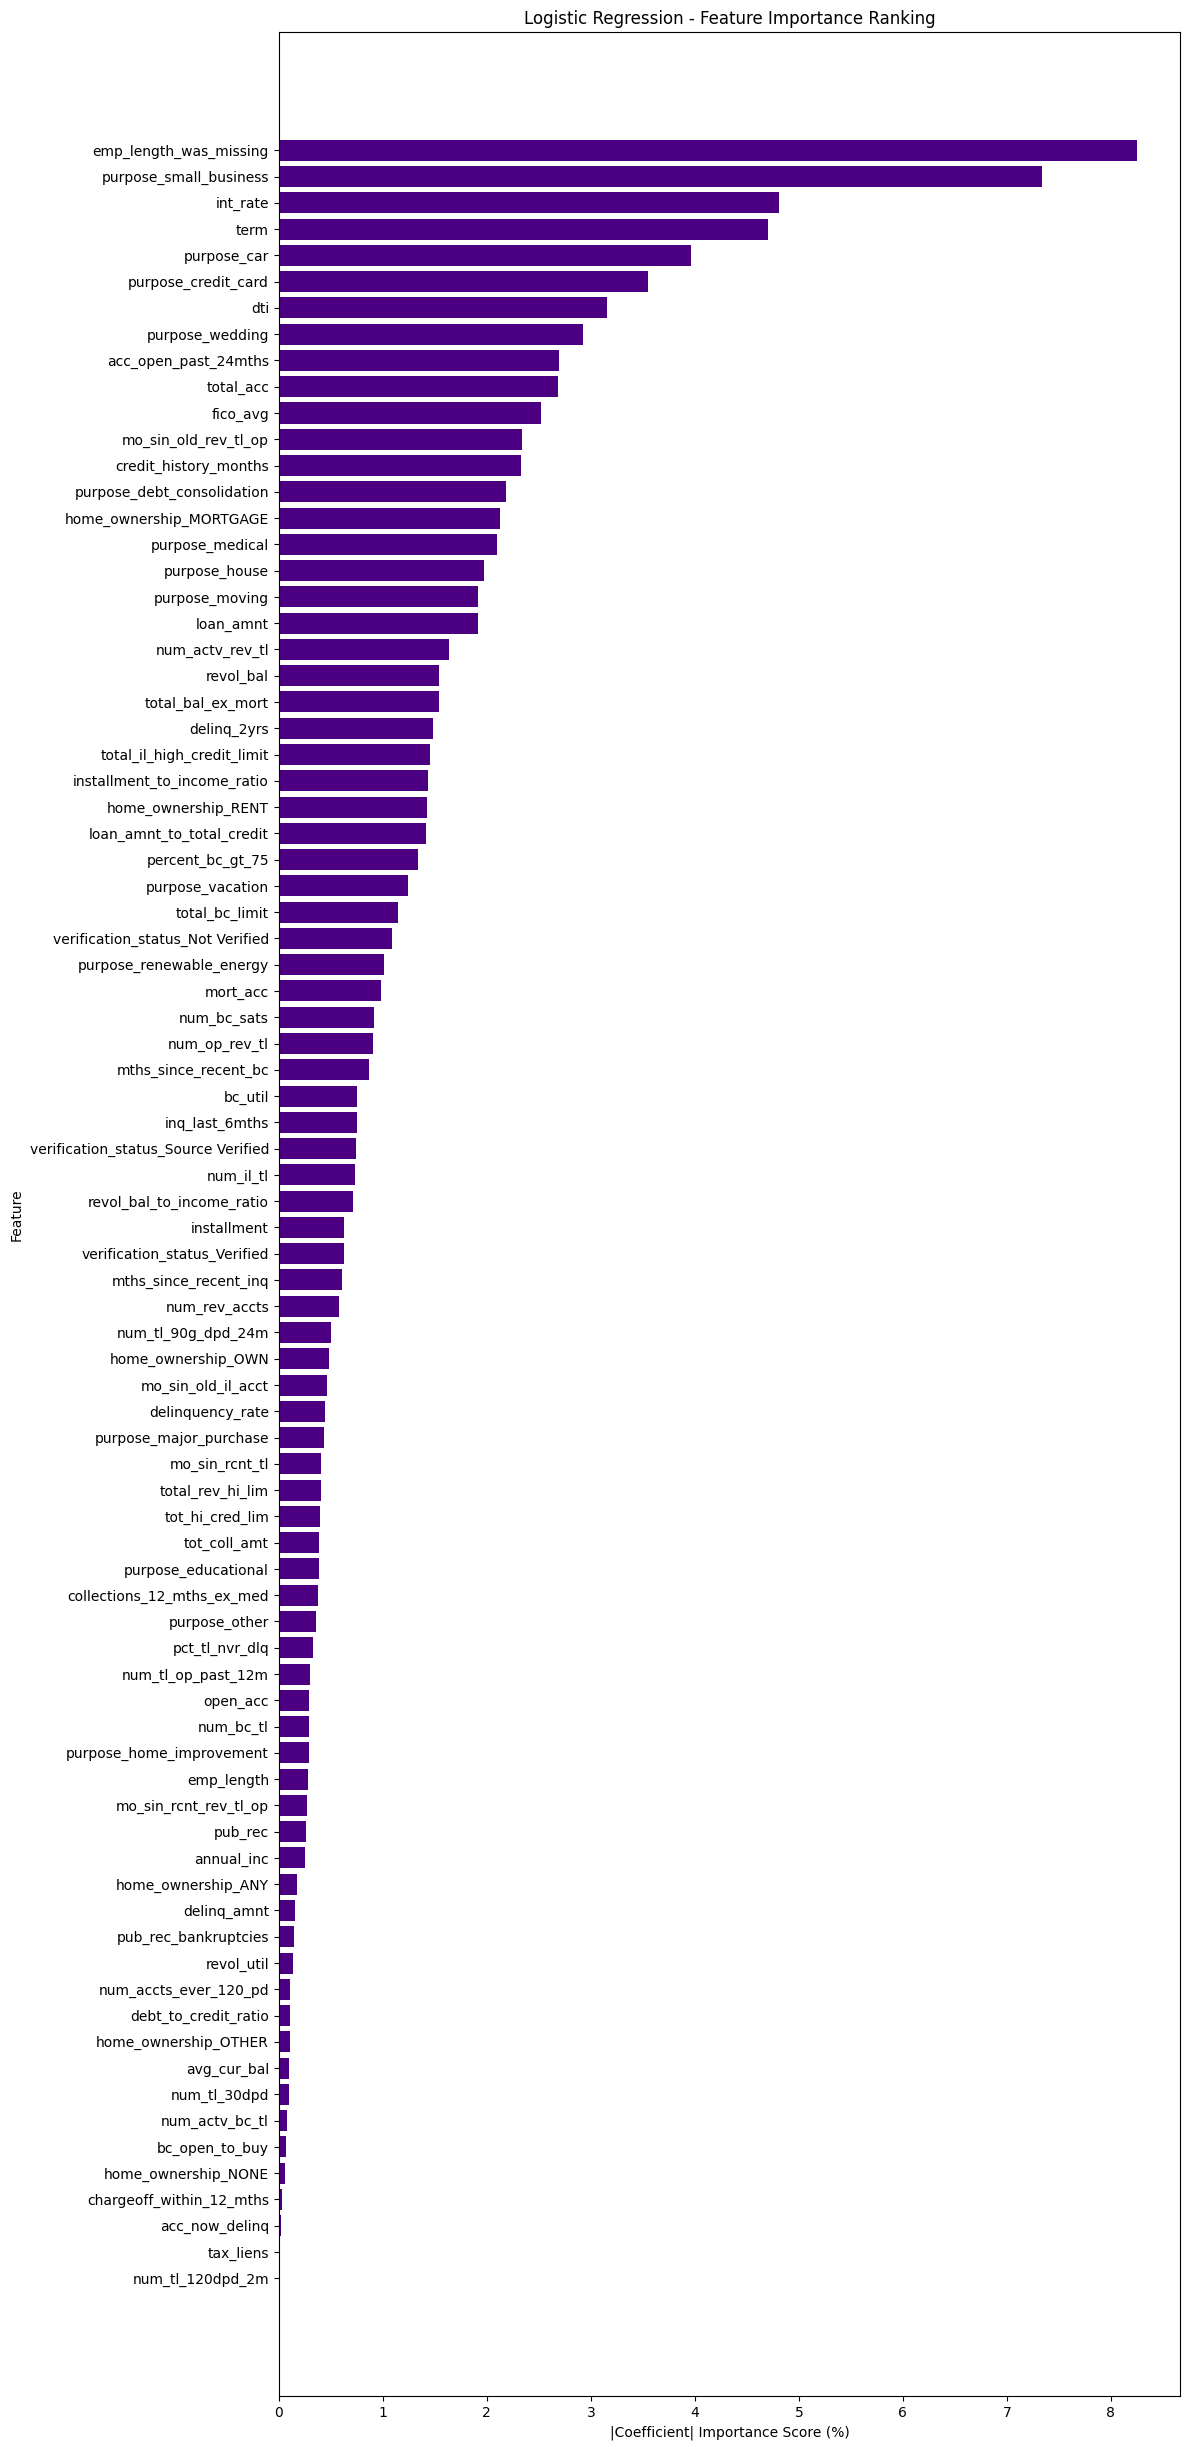

In [51]:
""" visualize logistic regression full importance as a horizontal bar chart
we use a tall figure so all features display clearly without squishing """

lr_names = []
lr_pct = []
for item in lr_importance:
    lr_names.append(item[0])
    lr_pct.append(item[1])

lr_names = lr_names[::-1]
lr_pct = lr_pct[::-1]

n_features = len(lr_names)
fig_height = max(12, n_features * 0.3)

plt.figure(figsize=(12, fig_height))
plt.barh(lr_names, lr_pct, color='indigo')
plt.xlabel('|Coefficient| Importance Score (%)')
plt.ylabel('Feature')
plt.title('Logistic Regression - Feature Importance Ranking')
plt.tight_layout()
plt.savefig('phase10_lr_importance.png', dpi=100, bbox_inches='tight')
plt.show()


**Phase 11 - Final Clean Feature Lock-in**

phase 10 produced four feature importance rankings (lightgbm xgboost random forest logistic regression). we picked one as the basis for our feature selection sweep based on four eliminations:

1. logistic regression is excluded because |coefficient| measures linear effect magnitude which is mathematically different from tree split utility. its top 10 contains rare categorical features (purpose_wedding purpose_car) whose coefficients are inflated by small sample variance. mixing it with tree rankings would introduce noise

2. xgboost is excluded because its gain importance is too concentrated. int_rate alone holds 18.09% of total importance and the top 5 features hold 37%. this concentration masks mid-tier features and produces an unstable ranking sensitive to random seeds

3. random forest gini importance is biased toward continuous features with many unique values. it demotes binary categorical signals like home_ownership_RENT and purpose_small_business which carry real predictive signal for borrower profile in credit risk

4. lightgbm split-count importance avoids all three problems. it treats continuous and categorical features symmetrically and distributes scores smoothly across ranks. this balanced distribution makes the ranking informative across both head and mid-tier features which is what we need for a feature selection cutoff

we use lightgbm's ranking for the sweep below


In [52]:
print("X_train total columns:", len(X_train.columns))
print("sub_grade in X_train:", 'sub_grade' in X_train.columns)
state_cols = [c for c in X_train.columns if 'addr_state' in c]
print("addr_state cols:", len(state_cols))
print("\nfirst 20 columns:")
print(X_train.columns.tolist()[:20])

X_train total columns: 82
sub_grade in X_train: False
addr_state cols: 0

first 20 columns:
['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal']


In [53]:
""" phase 11 step 1 sweep through different feature counts using three algorithms
each cutoff trains lightgbm xgboost and logistic regression on the top-N features
this lets us see if the choice of feature count is robust across model families

we exclude random forest from this sweep because at default hyperparameters it
suffers from the accuracy paradox on imbalanced data (see phase 9 results) and
its recall stays uniformly low across all feature counts which makes it
uninformative for finding the elbow point. we include random forest in
section 6 after f2-targeted hyperparameter tuning resolves this issue

we reuse lgb_importance from phase 10 as our ranking source
the cross-algorithm comparison in phase 10 showed substantial overlap in top features
so any reasonable ranking would give similar sweep results """

ranked_features = []
for item in lgb_importance:
    ranked_features.append(item[0])

total_features = len(ranked_features)
print("total features available:", total_features)

# pick the cutoffs to test
test_sizes = [10, 15, 20, 25, 30,
              35,  40, 45, 50, total_features]

sweep_results = []

for n in test_sizes:
    print(f"\n--- testing top {n} features ---")
    selected = ranked_features[:n]
    X_tr = X_train[selected]
    X_v = X_val[selected]

    # lightgbm
    m_lgb = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    m_lgb.fit(X_tr, y_train)
    p_lgb = m_lgb.predict(X_v)
    pr_lgb = m_lgb.predict_proba(X_v)[:, 1]

    # xgboost
    m_xgb = xgb.XGBClassifier(tree_method='hist', random_state=42, eval_metric='logloss',
                               scale_pos_weight=imbalance_ratio, n_jobs=-1)
    m_xgb.fit(X_tr, y_train)
    p_xgb = m_xgb.predict(X_v)
    pr_xgb = m_xgb.predict_proba(X_v)[:, 1]

    # logistic regression
    m_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1)
    m_lr.fit(X_tr, y_train)
    p_lr = m_lr.predict(X_v)
    pr_lr = m_lr.predict_proba(X_v)[:, 1]

    result = {
        'n_features': n,
        'lgb_acc': accuracy_score(y_val, p_lgb),
        'lgb_prec': precision_score(y_val, p_lgb, zero_division=0),
        'lgb_recall': recall_score(y_val, p_lgb),
        'lgb_f1': f1_score(y_val, p_lgb, zero_division=0),
        'lgb_auc': roc_auc_score(y_val, pr_lgb),
        'xgb_acc': accuracy_score(y_val, p_xgb),
        'xgb_prec': precision_score(y_val, p_xgb, zero_division=0),
        'xgb_recall': recall_score(y_val, p_xgb),
        'xgb_f1': f1_score(y_val, p_xgb, zero_division=0),
        'xgb_auc': roc_auc_score(y_val, pr_xgb),
        'lr_acc': accuracy_score(y_val, p_lr),
        'lr_prec': precision_score(y_val, p_lr, zero_division=0),
        'lr_recall': recall_score(y_val, p_lr),
        'lr_f1': f1_score(y_val, p_lr, zero_division=0),
        'lr_auc': roc_auc_score(y_val, pr_lr),
    }
    sweep_results.append(result)

    print(f"  lgb: acc={round(result['lgb_acc'], 4)} prec={round(result['lgb_prec'], 4)} rec={round(result['lgb_recall'], 4)} f1={round(result['lgb_f1'], 4)} auc={round(result['lgb_auc'], 4)}")
    print(f"  xgb: acc={round(result['xgb_acc'], 4)} prec={round(result['xgb_prec'], 4)} rec={round(result['xgb_recall'], 4)} f1={round(result['xgb_f1'], 4)} auc={round(result['xgb_auc'], 4)}")
    print(f"  lr:  acc={round(result['lr_acc'], 4)} prec={round(result['lr_prec'], 4)} rec={round(result['lr_recall'], 4)} f1={round(result['lr_f1'], 4)} auc={round(result['lr_auc'], 4)}")

# print summary table per algorithm
for algo in ['lgb', 'xgb', 'lr']:
    algo_name = {'lgb': 'LIGHTGBM', 'xgb': 'XGBOOST', 'lr': 'LOGISTIC REGRESSION'}[algo]
    print(f"\n{algo_name} - SWEEP RESULTS")
    print("=" * 80)
    print(f"{'n':<5} {'acc':<10} {'prec':<10} {'recall':<10} {'f1':<10} {'auc':<10}")
    print("-" * 80)
    for r in sweep_results:
        n = r['n_features']
        acc = round(r[f'{algo}_acc'], 4)
        prec = round(r[f'{algo}_prec'], 4)
        rec = round(r[f'{algo}_recall'], 4)
        f1 = round(r[f'{algo}_f1'], 4)
        auc = round(r[f'{algo}_auc'], 4)
        print(f"{n:<5} {acc:<10} {prec:<10} {rec:<10} {f1:<10} {auc:<10}")
    print("=" * 80)

total features available: 82

--- testing top 10 features ---
  lgb: acc=0.649 prec=0.3184 rec=0.6719 f1=0.4321 auc=0.7172
  xgb: acc=0.6526 prec=0.3204 rec=0.6675 f1=0.433 auc=0.7166
  lr:  acc=0.6618 prec=0.3215 rec=0.6318 f1=0.4262 auc=0.7087

--- testing top 15 features ---
  lgb: acc=0.6524 prec=0.3215 rec=0.6744 f1=0.4354 auc=0.7209
  xgb: acc=0.6562 prec=0.3227 rec=0.6645 f1=0.4344 auc=0.7194
  lr:  acc=0.6622 prec=0.3228 rec=0.6376 f1=0.4286 auc=0.7114

--- testing top 20 features ---
  lgb: acc=0.6525 prec=0.3219 rec=0.6765 f1=0.4362 auc=0.7232
  xgb: acc=0.6588 prec=0.3246 rec=0.6634 f1=0.4359 auc=0.7211
  lr:  acc=0.6634 prec=0.3242 rec=0.6396 f1=0.4303 auc=0.7137

--- testing top 25 features ---
  lgb: acc=0.6537 prec=0.3234 rec=0.6796 f1=0.4382 auc=0.7249
  xgb: acc=0.6602 prec=0.3258 rec=0.6638 f1=0.437 auc=0.7237
  lr:  acc=0.663 prec=0.3244 rec=0.6427 f1=0.4312 auc=0.7151

--- testing top 30 features ---
  lgb: acc=0.6535 prec=0.3233 rec=0.6799 f1=0.4382 auc=0.7251
  xg

In [54]:
""" save the sweep results to drive for later
we save the full sweep_results list which contains all metrics
for all three algorithms at every feature count tested """

DRIVE_PATH = '/content/drive/MyDrive/MLLDP_artifacts'

joblib.dump(sweep_results, DRIVE_PATH + '/phase11_sweep_results.pkl')
print("saved phase11_sweep_results.pkl to drive")
print(f"contains {len(sweep_results)} cutoffs with metrics for lgb xgb lr")

saved phase11_sweep_results.pkl to drive
contains 10 cutoffs with metrics for lgb xgb lr


In [55]:
""" phase 11 step 2 lock in 40 features as the final feature set
the sweep showed lightgbm peaks at 40 features (recall 0.6816) and xgboost stabilizes
at 40 with subsequent improvements within noise margin
this is the smallest feature set capturing the predictive signal across model families
this becomes the feature set for tuning shap analysis and deployment """

FINAL_N = 40

print("locking in top", FINAL_N, "features")

final_features = ranked_features[:FINAL_N]

X_train_final = X_train[final_features]
X_val_final = X_val[final_features]

joblib.dump(final_features, 'final_feature_list.pkl')

print(f"\nLOCKED IN {FINAL_N} FEATURES:")
for i in range(len(final_features)):
    print(f"  {i+1:>2}. {final_features[i]}")

locking in top 40 features

LOCKED IN 40 FEATURES:
   1. int_rate
   2. dti
   3. installment_to_income_ratio
   4. acc_open_past_24mths
   5. term
   6. fico_avg
   7. loan_amnt
   8. mo_sin_old_rev_tl_op
   9. num_actv_rev_tl
  10. loan_amnt_to_total_credit
  11. revol_bal_to_income_ratio
  12. annual_inc
  13. credit_history_months
  14. mths_since_recent_bc
  15. mort_acc
  16. emp_length_was_missing
  17. total_bc_limit
  18. bc_open_to_buy
  19. revol_bal
  20. total_rev_hi_lim
  21. emp_length
  22. bc_util
  23. num_il_tl
  24. total_acc
  25. mths_since_recent_inq
  26. revol_util
  27. installment
  28. num_rev_accts
  29. debt_to_credit_ratio
  30. avg_cur_bal
  31. home_ownership_RENT
  32. delinq_2yrs
  33. mo_sin_old_il_acct
  34. purpose_small_business
  35. num_bc_sats
  36. percent_bc_gt_75
  37. num_tl_op_past_12m
  38. mo_sin_rcnt_tl
  39. home_ownership_MORTGAGE
  40. num_actv_bc_tl


# Section 6 - Machine Learning Hyperparameter Tuning

with our 40 production features locked in we now tune four candidate algorithms to find the best possible model for credit default prediction. this is the most computationally expensive section of the entire pipeline

we use the gold standard methodology:
- TPE optimization via Optuna (smarter than grid search finds better hyperparameters in fewer trials)
- 5-fold cross-validation on training data for lightgbm xgboost and logistic regression
- 3-fold cross-validation for random forest (it is the slowest model fewer folds keep runtime feasible)
- F2 score as the optimization target for xgboost random forest and logistic regression (recall weighted 2x precision but precision still penalized)
- stratified folds (preserves class distribution across folds)

the validation set remains untouched during tuning. we use cv on the training data to score each hyperparameter trial then evaluate the final tuned model on the validation set as a sanity check

algorithms tuned in order from fastest to slowest:
1. LightGBM
2. XGBoost
3. Random Forest
4. Logistic Regression

after all 4 are tuned we compare them on the validation set. the top 3 tree models plus a stacking ensemble move forward to the calibration stage. logistic regression is included for context but does not advance because tree-based models clearly outperform it on this task

**Phase 1 - resetup ML Tuning Environment**

import all libraries we need across the tuning phases. configure global settings like the cv splitter and target metric. mount google drive so all model artifacts are saved permanently.

In [ ]:
""" phase 1 step 1 install libraries and import everything we need """

import subprocess
subprocess.run(['pip', 'install', 'optuna', '-q'])
subprocess.run(['pip', 'install', 'lightgbm', '-q'])

import os
import time
import shutil
import joblib
from google.colab import drive
import optuna
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, average_precision_score, precision_recall_curve, make_scorer
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
""" phase 1 step 1 install libraries and import everything we need """

# install optuna which is the bayesian/tpe hyperparameter search library
# also install lightgbm in case the runtime restarted

# silence optuna's verbose default logging so the output stays clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("all libraries imported successfully")

all libraries imported successfully


In [ ]:
# @title
""" phase 1 step 2 mount google drive
we save all model artifacts to drive so they survive colab disconnects
this is critical when tuning takes 30+ hours per model """
drive.mount('/content/drive')

# create our project folder if it does not exist
DRIVE_PATH = '/content/drive/MyDrive/MLLDP_artifacts'
if not os.path.exists(DRIVE_PATH):
    os.makedirs(DRIVE_PATH)
    print("created", DRIVE_PATH)
else:
    print("using existing", DRIVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
using existing /content/drive/MyDrive/MLLDP_artifacts


In [ ]:
""" phase 1 step 3 helper function for saving artifacts
we save to working directory first (faster access during the session)
then copy to drive for persistence
this gives us redundancy if anything fails """

def save_artifact(obj, filename):
    # save to working directory first
    local_path = filename
    joblib.dump(obj, local_path)

    # then copy to drive for persistence
    drive_path = DRIVE_PATH + '/' + filename
    shutil.copy(local_path, drive_path)

    print(f"saved {filename} to both working dir and drive")

# quick test that the function works
test_var = "checking save works"
save_artifact(test_var, 'test_save.pkl')
print("\ntest save successful - cleaning up test file")
os.remove('test_save.pkl')
os.remove(DRIVE_PATH + '/test_save.pkl')

saved test_save.pkl to both working dir and drive

test save successful - cleaning up test file


**Phase 2 - Prepare Cross Validation and Final Features**

we configure stratified cross validation which preserves the class ratio in each fold. we also load the locked feature list and define the F2 scorer that we will use as the optimization target.

In [ ]:
""" phase 2 prepare cross-validation splitter and verify our data is ready
we configure stratified 5-fold cv which preserves the class ratio in each fold
this is essential for imbalanced data like our 80/20 credit default scenario """

# load the locked feature list from phase 12 of section 5
final_features = joblib.load(DRIVE_PATH + '/final_feature_list.pkl')
print("loaded", len(final_features), "production features")

# subset our data to only those features
X_train_final = X_train[final_features]
X_val_final = X_val[final_features]
X_test_final = X_test[final_features]

# verify shapes are correct
print("X_train_final shape:", X_train_final.shape)
print("X_val_final shape:", X_val_final.shape)
print("X_test_final shape:", X_test_final.shape)

# configure stratified 5-fold cross-validation for lightgbm and xgboost
# random_state for reproducibility shuffle helps avoid systematic biases
cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 3-fold splitter for random forest only since it is the slowest model
cv_splitter_rf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("\n5-fold stratified cv configured for lightgbm and xgboost")
print("3-fold stratified cv configured for random forest")

# create the f2 scorer
# beta=2 means recall weighs 2x precision
# this is our credit risk priority but precision is still penalized
f2_scorer = make_scorer(fbeta_score, beta=2)
print("\nf2 scorer ready (beta=2 means recall is weighted 2x more than precision)")

# compute imbalance ratio for class weighting
# this will be used by xgboost as scale_pos_weight
class_0_count = (y_train == 0).sum()
class_1_count = (y_train == 1).sum()
imbalance_ratio = class_0_count / class_1_count
print("\nimbalance ratio for class weighting:", round(imbalance_ratio, 2))

# global storage for tuned models so we can compare them all later
tuned_models = {}
tuned_results = {}

print("\nready to start tuning. lightgbm will go first because it is the fastest")

loaded 40 production features
X_train_final shape: (791706, 40)
X_val_final shape: (263902, 40)
X_test_final shape: (263902, 40)

5-fold stratified cv configured for lightgbm and xgboost
3-fold stratified cv configured for random forest

f2 scorer ready (beta=2 means recall is weighted 2x more than precision)

imbalance ratio for class weighting: 4.03

ready to start tuning. lightgbm will go first because it is the fastest


**Phase 3 - LightGBM Hyperparameter Tuning**

lightgbm is our fastest model so we run more trials (100) and use 5-fold cross validation. each trial trains lightgbm 5 times so this is roughly 500 model trainings in total.

In [ ]:
# """ phase 3 lightgbm hyperparameter tuning with tpe and 5-fold cv """

# def objective_lgb(trial):
#     # define the hyperparameter search space
#     # these ranges are based on lightgbm best practices
#     params = {
#         'class_weight': 'balanced',
#         'random_state': 42,
#         'n_jobs': -1,
#         'verbose': -1,
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 255),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#     }

#     model = lgb.LGBMClassifier(**params)

#     # use f2 scorer for consistency with xgboost and random forest
#     scores = cross_val_score(
#         model,
#         X_train_final,
#         y_train,
#         cv=cv_splitter,
#         scoring=f2_scorer,
#         n_jobs=1
#     )

#     return scores.mean()

# # create the optuna study to maximize f2
# study_lgb = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42)
# )

# print("starting lightgbm tuning with 100 trials and 5-fold cv...")

# print()

# study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

# print("\nlightgbm tuning complete")

# # save the optuna study so we have full history
# save_artifact(study_lgb, 'optuna_study_lightgbm.pkl')

# best_params_lgb = study_lgb.best_params
# best_f2_lgb = study_lgb.best_value

# print(f"best cv f2 achieved: {round(best_f2_lgb, 4)}")
# print("best parameters found:")
# for key in best_params_lgb:
#     print(f"  {key}: {best_params_lgb[key]}")


# # the best hyperparameters optuna found
# best_params_lgb = study_lgb.best_params
# best_lgb = study_lgb.best_value

# # evaluate on validation set
# y_pred = tuned_lgb.predict(X_val_final)
# y_proba = tuned_lgb.predict_proba(X_val_final)[:, 1]

# val_acc = accuracy_score(y_val, y_pred)
# val_prec = precision_score(y_val, y_pred, zero_division=0)
# val_recall = recall_score(y_val, y_pred)
# val_f1 = f1_score(y_val, y_pred, zero_division=0)
# val_f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
# val_auc = roc_auc_score(y_val, y_proba)

# print("LIGHTGBM TUNING SUMMARY")
# print("=" * 70)
# print(f"trials: 100 | cv folds: 5 | scoring: F2")
# print()
# print(f"best cv recall achieved: {round(best_lgb, 4)}")
# print()
# print("best hyperparameters found by optuna tpe:")
# for key in best_params_lgb:
#     val = best_params_lgb[key]
#     if isinstance(val, float):
#         val = round(val, 6)
#     print(f"  {key}: {val}")

# print()
# print("TUNED LIGHTGBM - VALIDATION SET RESULTS")
# print("=" * 70)
# print(f"  accuracy:   {round(val_acc, 4)}")
# print(f"  precision:  {round(val_prec, 4)}")
# print(f"  recall:     {round(val_recall, 4)}")
# print(f"  f1-score:   {round(val_f1, 4)}")
# print(f"  f2-score:   {round(val_f2, 4)}")
# print(f"  auc-roc:    {round(val_auc, 4)}")
# print("=" * 70)

In [ ]:
""" lightgbm display the tuning results
load the study and tuned model from drive then print best params and validation metrics """

study_lgb = joblib.load(DRIVE_PATH + '/optuna_study_lightgbm.pkl')
tuned_lgb = joblib.load(DRIVE_PATH + '/tuned_lightgbm.pkl')

best_params_lgb = study_lgb.best_params
best_f2_lgb = study_lgb.best_value

# evaluate on validation set
y_pred = tuned_lgb.predict(X_val_final)
y_proba = tuned_lgb.predict_proba(X_val_final)[:, 1]

val_acc = accuracy_score(y_val, y_pred)
val_prec = precision_score(y_val, y_pred, zero_division=0)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred, zero_division=0)
val_f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
val_auc = roc_auc_score(y_val, y_proba)

print("LIGHTGBM TUNING SUMMARY")
print("=" * 70)
print("trials: 100 | cv folds: 5 | scoring: F2")
print()
print(f"best cv f2 achieved: {round(best_f2_lgb, 4)}")
print()
print("best hyperparameters found by optuna tpe:")
for key in best_params_lgb:
    val = best_params_lgb[key]
    if isinstance(val, float):
        val = round(val, 6)
    print(f"  {key}: {val}")

print()
print("TUNED LIGHTGBM - VALIDATION SET RESULTS")
print("=" * 70)
print(f"  accuracy:   {round(val_acc, 4)}")
print(f"  precision:  {round(val_prec, 4)}")
print(f"  recall:     {round(val_recall, 4)}")
print(f"  f1-score:   {round(val_f1, 4)}")
print(f"  f2-score:   {round(val_f2, 4)}")
print(f"  auc-roc:    {round(val_auc, 4)}")
print("=" * 70)

LIGHTGBM TUNING SUMMARY
trials: 100 | cv folds: 5 | scoring: F2

best cv f2 achieved: 0.5589

best hyperparameters found by optuna tpe:
  n_estimators: 939
  max_depth: 12
  num_leaves: 19
  learning_rate: 0.021634
  min_child_samples: 58
  subsample: 0.642267
  colsample_bytree: 0.609291
  reg_alpha: 0.0
  reg_lambda: 6.057131

TUNED LIGHTGBM - VALIDATION SET RESULTS
  accuracy:   0.6571
  precision:  0.3263
  recall:     0.6814
  f1-score:   0.4413
  f2-score:   0.5596
  auc-roc:    0.7288


In [ ]:
""" save lightgbm to global dicts for downstream phases """

if 'tuned_models' not in dir():
    tuned_models = {}
if 'tuned_results' not in dir():
    tuned_results = {}

tuned_models['lightgbm'] = tuned_lgb
tuned_results['lightgbm'] = {
    'cv_score': best_f2_lgb,
    'cv_metric': 'f2',
    'val_accuracy': val_acc,
    'val_precision': val_prec,
    'val_recall': val_recall,
    'val_f1': val_f1,
    'val_f2': val_f2,
    'val_auc': val_auc,
    'best_params': best_params_lgb
}

print("lightgbm added to tuned_models and tuned_results")

lightgbm added to tuned_models and tuned_results


**Phase 4 - XGBoost Hyperparameter Tuning**

we use F2 score as the optimization target - F2 weights recall 2x precision but still penalizes precision collapse, which prevents the degenerate optimum we saw with lightgbm.

In [ ]:
# # @title
# # # @title
# """ phase 4 xgboost hyperparameter tuning with tpe and 5-fold cv
# we use f2 score instead of raw recall as the optimization target
# f2 weights recall 2x precision but still penalizes precision collapse
# this avoids the degenerate optimum where the model just predicts everything as positive
# expected runtime 30-50 hours """

# def objective_xgb(trial):
#     params = {
#         'tree_method': 'hist',
#         'random_state': 42,
#         'eval_metric': 'logloss',
#         'n_jobs': -1,
#         'scale_pos_weight': imbalance_ratio,
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
#     }

#     model = xgb.XGBClassifier(**params)

#     # use f2 scorer instead of recall for better balance
#     scores = cross_val_score(
#         model,
#         X_train_final,
#         y_train,
#         cv=cv_splitter,
#         scoring=f2_scorer,
#         n_jobs=1
#     )

#     return scores.mean()

# study_xgb = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42)
# )

# print("starting xgboost tuning with 100 trials and 5-fold cv...")
# print("scoring metric: F2 (recall weighted 2x precision)")
# print()

# start_time = time.time()
# study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
# elapsed = round((time.time() - start_time) / 3600, 2)

# print(f"\nxgboost tuning complete after {elapsed} hours")

# save_artifact(study_xgb, 'optuna_study_xgboost.pkl')

# best_params_xgb = study_xgb.best_params
# best_f2_xgb = study_xgb.best_value

# print(f"best cv f2 score: {round(best_f2_xgb, 4)}")
# print("best parameters:")
# for key in best_params_xgb:
#     print(f"  {key}: {best_params_xgb[key]}")

# print("XGBOOST TUNING SUMMARY")
# print("=" * 70)
# print(f"trials: 100 | cv folds: 5 | scoring: F2")
# print()
# print(f"best cv f2 achieved: {round(best_f2_xgb, 4)}")
# print()
# print("best hyperparameters found by optuna tpe:")
# for key in best_params_xgb:
#     val = best_params_xgb[key]
#     if isinstance(val, float):
#         val = round(val, 6)
#     print(f"  {key}: {val}")

In [ ]:
""" xgboost display the tuning results
load the study and tuned model from drive then print best params and validation metrics """

study_xgb = joblib.load(DRIVE_PATH + '/optuna_study_xgboost.pkl')
tuned_xgb = joblib.load(DRIVE_PATH + '/tuned_xgboost.pkl')

best_params_xgb = study_xgb.best_params
best_f2_xgb = study_xgb.best_value

# evaluate on validation set
y_pred = tuned_xgb.predict(X_val_final)
y_proba = tuned_xgb.predict_proba(X_val_final)[:, 1]

val_acc = accuracy_score(y_val, y_pred)
val_prec = precision_score(y_val, y_pred, zero_division=0)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred, zero_division=0)
val_f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
val_auc = roc_auc_score(y_val, y_proba)

print("XGBOOST TUNING SUMMARY")
print("=" * 70)
print("trials: 100 | cv folds: 5 | scoring: F2")
print()
print(f"best cv f2 achieved: {round(best_f2_xgb, 4)}")
print()
print("best hyperparameters found by optuna tpe:")
for key in best_params_xgb:
    val = best_params_xgb[key]
    if isinstance(val, float):
        val = round(val, 6)
    print(f"  {key}: {val}")

print()
print("TUNED XGBOOST - VALIDATION SET RESULTS")
print("=" * 70)
print(f"  accuracy:   {round(val_acc, 4)}")
print(f"  precision:  {round(val_prec, 4)}")
print(f"  recall:     {round(val_recall, 4)}")
print(f"  f1-score:   {round(val_f1, 4)}")
print(f"  f2-score:   {round(val_f2, 4)}")
print(f"  auc-roc:    {round(val_auc, 4)}")
print("=" * 70)

XGBOOST TUNING SUMMARY
trials: 100 | cv folds: 5 | scoring: F2

best cv f2 achieved: 0.5579

best hyperparameters found by optuna tpe:
  n_estimators: 784
  max_depth: 3
  learning_rate: 0.105681
  min_child_weight: 10
  subsample: 0.7826
  colsample_bytree: 0.699419
  reg_alpha: 0.01237
  reg_lambda: 0.005034
  gamma: 0.0

TUNED XGBOOST - VALIDATION SET RESULTS
  accuracy:   0.6603
  precision:  0.328
  recall:     0.6765
  f1-score:   0.4418
  f2-score:   0.5579
  auc-roc:    0.7296


In [ ]:
""" save xgboost to global dicts for downstream phases """

if 'tuned_models' not in dir():
    tuned_models = {}
if 'tuned_results' not in dir():
    tuned_results = {}

tuned_models['xgboost'] = tuned_xgb
tuned_results['xgboost'] = {
    'cv_score': best_f2_xgb,
    'cv_metric': 'f2',
    'val_accuracy': val_acc,
    'val_precision': val_prec,
    'val_recall': val_recall,
    'val_f1': val_f1,
    'val_f2': val_f2,
    'val_auc': val_auc,
    'best_params': best_params_xgb
}

print("xgboost added to tuned_models and tuned_results")

xgboost added to tuned_models and tuned_results


**Phase 5 - Random Forest Hyperparameter Tuning**

random forest is the slowest model so we use 50 trials with 3-fold cross validation (instead of 5-fold). this is a deliberate compute tradeoff - the slower model gets fewer folds to keep total runtime under control. we still use F2 score as the optimization target for consistency with xgboost. expected runtime 30-50 hours.

In [ ]:
# @title
# # @title
# """ phase 5 random forest hyperparameter tuning with tpe and 3-fold cv
# we use 3-fold cv instead of 5-fold to keep runtime feasible
# we use f2 score as the optimization target for consistency with xgboost
#  """

# def objective_rf(trial):
#     params = {
#         'class_weight': 'balanced',
#         'random_state': 42,
#         'n_jobs': -1,
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'max_depth': trial.suggest_int('max_depth', 5, 25),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
#     }

#     model = RandomForestClassifier(**params)

#     # use the 3-fold splitter and f2 scorer for random forest
#     scores = cross_val_score(
#         model,
#         X_train_final,
#         y_train,
#         cv=cv_splitter_rf,
#         scoring=f2_scorer,
#         n_jobs=1
#     )

#     return scores.mean()

# study_rf = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42)
# )

# print("starting random forest tuning with 50 trials and 3-fold cv...")
# print("scoring metric: F2 (recall weighted 2x precision)")
# print()

# start_time = time.time()
# study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)
# elapsed = round((time.time() - start_time) / 3600, 2)

# print(f"\nrandom forest tuning complete after {elapsed} hours")

# save_artifact(study_rf, 'optuna_study_randomforest.pkl')

# best_params_rf = study_rf.best_params
# best_f2_rf = study_rf.best_value

# print(f"best cv f2 score: {round(best_f2_rf, 4)}")
# print("best parameters:")
# for key in best_params_rf:
#     print(f"  {key}: {best_params_rf[key]}")
# load study from drive instead of running tuning
# study_rf = joblib.load(DRIVE_PATH + '/optuna_study_randomforest.pkl')

# best_params_rf = study_rf.best_params
# best_f2_rf = study_rf.best_value

# print("RANDOM FOREST TUNING SUMMARY")
# print("=" * 70)
# print("trials: 50 | cv folds: 3 | scoring: F2")
# print()
# print(f"best cv f2 score: {round(best_f2_rf, 4)}")
# print()
# print("best hyperparameters found by optuna tpe:")
# for key in best_params_rf:
#     val = best_params_rf[key]
#     if isinstance(val, float):
#         val = round(val, 6)
#     print(f"  {key}: {val}")
# print("=" * 70)

In [ ]:
""" random forest display the tuning results
load the study and tuned model from drive then print best params and validation metrics """

study_rf = joblib.load(DRIVE_PATH + '/optuna_study_randomforest.pkl')
tuned_rf = joblib.load(DRIVE_PATH + '/tuned_randomforest.pkl')

best_params_rf = study_rf.best_params
best_f2_rf = study_rf.best_value

# evaluate on validation set
y_pred = tuned_rf.predict(X_val_final)
y_proba = tuned_rf.predict_proba(X_val_final)[:, 1]

val_acc = accuracy_score(y_val, y_pred)
val_prec = precision_score(y_val, y_pred, zero_division=0)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred, zero_division=0)
val_f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
val_auc = roc_auc_score(y_val, y_proba)

print("RANDOM FOREST TUNING SUMMARY")
print("=" * 70)
print("trials: 50 | cv folds: 3 | scoring: F2")
print()
print(f"best cv f2 achieved: {round(best_f2_rf, 4)}")
print()
print("best hyperparameters found by optuna tpe:")
for key in best_params_rf:
    val = best_params_rf[key]
    if isinstance(val, float):
        val = round(val, 6)
    print(f"  {key}: {val}")

print()
print("TUNED RANDOM FOREST - VALIDATION SET RESULTS")
print("=" * 70)
print(f"  accuracy:   {round(val_acc, 4)}")
print(f"  precision:  {round(val_prec, 4)}")
print(f"  recall:     {round(val_recall, 4)}")
print(f"  f1-score:   {round(val_f1, 4)}")
print(f"  f2-score:   {round(val_f2, 4)}")
print(f"  auc-roc:    {round(val_auc, 4)}")
print("=" * 70)

RANDOM FOREST TUNING SUMMARY
trials: 50 | cv folds: 3 | scoring: F2

best cv f2 achieved: 0.5463

best hyperparameters found by optuna tpe:
  n_estimators: 486
  max_depth: 7
  min_samples_split: 12
  min_samples_leaf: 7
  max_features: sqrt

TUNED RANDOM FOREST - VALIDATION SET RESULTS
  accuracy:   0.6428
  precision:  0.3137
  recall:     0.6715
  f1-score:   0.4276
  f2-score:   0.5468
  auc-roc:    0.7136


In [ ]:
""" save random forest to global dicts for downstream phases """

if 'tuned_models' not in dir():
    tuned_models = {}
if 'tuned_results' not in dir():
    tuned_results = {}

tuned_models['random_forest'] = tuned_rf
tuned_results['random_forest'] = {
    'cv_score': best_f2_rf,
    'cv_metric': 'f2',
    'val_accuracy': val_acc,
    'val_precision': val_prec,
    'val_recall': val_recall,
    'val_f1': val_f1,
    'val_f2': val_f2,
    'val_auc': val_auc,
    'best_params': best_params_rf
}

print("random forest added to tuned_models and tuned_results")

random forest added to tuned_models and tuned_results


**Phase 6 - Logistic Regression Hyperparameter Tuning**

logistic regression is a linear model. unlike the 3 tree models from phases 3-5 it does not capture nonlinear interactions between features. we tune it as a 4th candidate to have a linear baseline benchmark for comparison purposes

we use 100 trials with 5-fold cv and F2 scoring for consistency with the other models. we search over regularization strength C (log-uniform from 0.001 to 100) the penalty type (l1 or l2) and max_iter (1000 to 5000). class_weight='balanced' handles the imbalance just like the other models

note logistic regression is included in the validation comparison for context but does not advance to the calibration stage because tree-based methods clearly outperform it on this task

In [ ]:
# import warnings
# warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.linear_model._logistic')
# """ phase 6 logistic regression hyperparameter tuning with tpe and 5-fold cv
# we tune logistic regression as a 4th candidate alongside the 3 tree models
# this gives us a linear baseline benchmark in addition to the tree-based methods

# logistic regression has no native feature_importances_ attribute but uses coefficients
# we use class_weight='balanced' just like the other models to handle the imbalance

# note logistic regression is included in the validation set comparison for context
# but does not advance to the calibration stage because tree models outperform it here
# """

# def objective_lr(trial):
#     # define the hyperparameter search space
#     # C is the inverse of regularization strength (smaller = stronger regularization)
#     params = {
#         'class_weight': 'balanced',
#         'random_state': 42,
#         'n_jobs': -1,
#         'C': trial.suggest_float('C', 0.001, 100.0, log=True),
#         'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
#         'max_iter': trial.suggest_int('max_iter', 1000, 5000),
#     }

#     # solver must be compatible with the penalty
#     # liblinear supports both l1 and l2 but is slower on large data
#     # saga supports both and is faster on large data
#     if params['penalty'] == 'l1':
#         params['solver'] = trial.suggest_categorical('solver_l1', ['liblinear', 'saga'])
#     else:
#         params['solver'] = trial.suggest_categorical('solver_l2', ['liblinear', 'saga'])

#     model = LogisticRegression(**params)

#     # use f2 scorer for consistency with all other algorithms
#     scores = cross_val_score(
#         model,
#         X_train_final,
#         y_train,
#         cv=cv_splitter,
#         scoring=f2_scorer,
#         n_jobs=1
#     )

#     return scores.mean()

# study_lr = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42)
# )

# print("starting logistic regression tuning with 100 trials and 5-fold cv...")
# print("scoring metric: F2 ")
# print()

# start_time = time.time()
# study_lr.optimize(objective_lr, n_trials=100, show_progress_bar=True)
# elapsed = round((time.time() - start_time) / 60, 2)

# print(f"\nlogistic regression tuning complete after {elapsed} minutes")

# save_artifact(study_lr, 'optuna_study_logisticregression.pkl')

# best_params_lr = study_lr.best_params
# best_f2_lr = study_lr.best_value

# print(f"best cv f2 score: {round(best_f2_lr, 4)}")
# print("best parameters:")
# for key in best_params_lr:
#     print(f"  {key}: {best_params_lr[key]}")

# # train final logistic regression with best params on full training data
# # clean up the solver key from the search namespace
# final_lr_params = {}
# for key in best_params_lr:
#     if key == 'solver_l1' or key == 'solver_l2':
#         final_lr_params['solver'] = best_params_lr[key]
#     else:
#         final_lr_params[key] = best_params_lr[key]

# final_lr_params['class_weight'] = 'balanced'
# final_lr_params['random_state'] = 42
# final_lr_params['n_jobs'] = -1

# tuned_lr = LogisticRegression(**final_lr_params)
# tuned_lr.fit(X_train_final, y_train)

# save_artifact(tuned_lr, 'tuned_logisticregression.pkl')
# print("\ntuned logistic regression saved to drive")

In [ ]:
""" logistic regression display the tuning results
load the study and tuned model from drive then print best params and validation metrics """

study_lr = joblib.load(DRIVE_PATH + '/optuna_study_logisticregression.pkl')
tuned_lr = joblib.load(DRIVE_PATH + '/tuned_logisticregression.pkl')

best_params_lr = study_lr.best_params
best_f2_lr = study_lr.best_value

# evaluate on validation set
y_pred = tuned_lr.predict(X_val_final)
y_proba = tuned_lr.predict_proba(X_val_final)[:, 1]

val_acc = accuracy_score(y_val, y_pred)
val_prec = precision_score(y_val, y_pred, zero_division=0)
val_recall = recall_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred, zero_division=0)
val_f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
val_auc = roc_auc_score(y_val, y_proba)

print("LOGISTIC REGRESSION TUNING SUMMARY")
print("=" * 70)
print("trials: 100 | cv folds: 5 | scoring: F2")
print()
print(f"best cv f2 achieved: {round(best_f2_lr, 4)}")
print()
print("best hyperparameters found by optuna tpe:")
for key in best_params_lr:
    val = best_params_lr[key]
    if isinstance(val, float):
        val = round(val, 6)
    print(f"  {key}: {val}")

print()
print("TUNED LOGISTIC REGRESSION - VALIDATION SET RESULTS")
print("=" * 70)
print(f"  accuracy:   {round(val_acc, 4)}")
print(f"  precision:  {round(val_prec, 4)}")
print(f"  recall:     {round(val_recall, 4)}")
print(f"  f1-score:   {round(val_f1, 4)}")
print(f"  f2-score:   {round(val_f2, 4)}")
print(f"  auc-roc:    {round(val_auc, 4)}")
print("=" * 70)

LOGISTIC REGRESSION TUNING SUMMARY
trials: 100 | cv folds: 5 | scoring: F2

best cv f2 achieved: 0.5406

best hyperparameters found by optuna tpe:
  C: 23.952211
  penalty: l2
  max_iter: 2033
  solver_l2: saga

TUNED LOGISTIC REGRESSION - VALIDATION SET RESULTS
  accuracy:   0.6639
  precision:  0.326
  recall:     0.6476
  f1-score:   0.4337
  f2-score:   0.5409
  auc-roc:    0.7175


In [ ]:
""" save logistic regression to global dicts for downstream phases """

if 'tuned_models' not in dir():
    tuned_models = {}
if 'tuned_results' not in dir():
    tuned_results = {}

tuned_models['logistic_regression'] = tuned_lr
tuned_results['logistic_regression'] = {
    'cv_score': best_f2_lr,
    'cv_metric': 'f2',
    'val_accuracy': val_acc,
    'val_precision': val_prec,
    'val_recall': val_recall,
    'val_f1': val_f1,
    'val_f2': val_f2,
    'val_auc': val_auc,
    'best_params': best_params_lr
}

print("logistic regression added to tuned_models and tuned_results")

logistic regression added to tuned_models and tuned_results


**TUNED MODELS COMPARISON**




In [ ]:
""" compare the 4 tuned models side by side
this gives us a clear picture before we add stacking as a 5th candidate
note logistic regression is shown here for context but does not advance to calibration """

print("TUNED MODELS COMPARISON - VALIDATION SET")
print("=" * 90)
print(f"{'model':<22} {'accuracy':<12} {'precision':<12} {'recall':<12} {'f1':<10} {'f2':<10} {'auc':<10}")
print("-" * 90)

for name in ['lightgbm', 'xgboost', 'random_forest', 'logistic_regression']:
    r = tuned_results[name]
    acc = round(r['val_accuracy'], 4)
    prec = round(r['val_precision'], 4)
    rec = round(r['val_recall'], 4)
    f1 = round(r['val_f1'], 4)
    f2 = round(r['val_f2'], 4)
    auc = round(r['val_auc'], 4)
    print(f"{name:<22} {acc:<12} {prec:<12} {rec:<12} {f1:<10} {f2:<10} {auc:<10}")

print("=" * 90)

# find winners by each key metric
winner_f2 = ('lightgbm', tuned_results['lightgbm']['val_f2'])
winner_recall = ('lightgbm', tuned_results['lightgbm']['val_recall'])
winner_auc = ('lightgbm', tuned_results['lightgbm']['val_auc'])
winner_f1 = ('lightgbm', tuned_results['lightgbm']['val_f1'])
winner_acc = ('lightgbm', tuned_results['lightgbm']['val_accuracy'])
winner_prec = ('lightgbm', tuned_results['lightgbm']['val_precision'])

for name in ['lightgbm', 'xgboost', 'random_forest', 'logistic_regression']:
    r = tuned_results[name]
    if r['val_f2'] > winner_f2[1]:
        winner_f2 = (name, r['val_f2'])
    if r['val_recall'] > winner_recall[1]:
        winner_recall = (name, r['val_recall'])
    if r['val_auc'] > winner_auc[1]:
        winner_auc = (name, r['val_auc'])
    if r['val_f1'] > winner_f1[1]:
        winner_f1 = (name, r['val_f1'])
    if r['val_accuracy'] > winner_acc[1]:
        winner_acc = (name, r['val_accuracy'])
    if r['val_precision'] > winner_prec[1]:
        winner_prec = (name, r['val_precision'])

print("\nWINNERS BY METRIC:")
print(f"  best accuracy:  {winner_acc[0]:<18} = {round(winner_acc[1], 4)}")
print(f"  best precision: {winner_prec[0]:<18} = {round(winner_prec[1], 4)}")
print(f"  best recall:    {winner_recall[0]:<18} = {round(winner_recall[1], 4)}")
print(f"  best F1:        {winner_f1[0]:<18} = {round(winner_f1[1], 4)}")
print(f"  best F2:        {winner_f2[0]:<18} = {round(winner_f2[1], 4)}")
print(f"  best AUC:       {winner_auc[0]:<18} = {round(winner_auc[1], 4)}")

TUNED MODELS COMPARISON - VALIDATION SET
model                  accuracy     precision    recall       f1         f2         auc       
------------------------------------------------------------------------------------------
lightgbm               0.6571       0.3263       0.6814       0.4413     0.5596     0.7288    
xgboost                0.6603       0.328        0.6765       0.4418     0.5579     0.7296    
random_forest          0.6428       0.3137       0.6715       0.4276     0.5468     0.7136    
logistic_regression    0.6639       0.326        0.6476       0.4337     0.5409     0.7175    

WINNERS BY METRIC:
  best accuracy:  logistic_regression = 0.6639
  best precision: xgboost            = 0.328
  best recall:    lightgbm           = 0.6814
  best F1:        xgboost            = 0.4418
  best F2:        lightgbm           = 0.5596
  best AUC:       xgboost            = 0.7296


**Phase 7 - Stacking Ensemble**

stacking combines the 3 tuned tree base models (lightgbm xgboost random forest) into one composite model. each base predicts a probability and a meta learner (logistic regression) learns the best way to weight those 3 probabilities. this is what reference [7] in our literature review used (Akinjole et al). we test this approach in our clean methodology and add it as a 4th candidate alongside the 3 tuned tree models

note we do not use the standalone logistic regression from phase 6 as a base model here. that LR was a separate baseline benchmark. for stacking we keep logistic regression in its role as the meta learner combining the tree models

how it works internally
1. each base model is refit 5 times via cross validation to generate out of fold predictions
2. those out of fold predictions become training data for the logistic regression meta learner
3. each base model is also refit one final time on the full training data for inference
4. at prediction time each base predicts and the meta learner aggregates their outputs

In [ ]:
# """ phase 7 stacking ensemble
# combines lightgbm xgboost and random forest with a logistic regression meta learner
# this gives us a 5th candidate (after the 4 base models from phases 3-6)
# but only the top 3 tree models plus stacking advance to calibration
# logistic regression is included as a baseline only """

# # rebuild lightgbm with its tuned params for use as a base model
# lgb_params = tuned_results['lightgbm']['best_params'].copy()
# lgb_params['class_weight'] = 'balanced'
# lgb_params['random_state'] = 42
# lgb_params['n_jobs'] = -1
# lgb_params['verbose'] = -1
# lgb_base = lgb.LGBMClassifier(**lgb_params)

# # rebuild xgboost with its tuned params
# xgb_params = tuned_results['xgboost']['best_params'].copy()
# xgb_params['tree_method'] = 'hist'
# xgb_params['random_state'] = 42
# xgb_params['eval_metric'] = 'logloss'
# xgb_params['n_jobs'] = -1
# xgb_params['scale_pos_weight'] = imbalance_ratio
# xgb_base = xgb.XGBClassifier(**xgb_params)

# # rebuild random forest with its tuned params
# rf_params = tuned_results['random_forest']['best_params'].copy()
# rf_params['class_weight'] = 'balanced'
# rf_params['random_state'] = 42
# rf_params['n_jobs'] = -1
# rf_base = RandomForestClassifier(**rf_params)

# # meta learner is logistic regression with balanced class weighting
# # we keep it simple to avoid overfitting on the 3 base predictions
# meta_learner = LogisticRegression(
#     class_weight='balanced',
#     max_iter=1000,
#     random_state=42
# )

# # build the stacking classifier
# # cv=5 generates the out of fold predictions for the meta learner
# base_estimators = [
#     ('lgb', lgb_base),
#     ('xgb', xgb_base),
#     ('rf', rf_base)
# ]

# stacker = StackingClassifier(
#     estimators=base_estimators,
#     final_estimator=meta_learner,
#     cv=5,
#     n_jobs=-1,
#     passthrough=False
# )

# print("training stacking ensemble on full training data")
# start = time.time()
# stacker.fit(X_train_final, y_train)
# elapsed = round((time.time() - start) / 60, 2)
# print(f"stacking complete in {elapsed} minutes")

# # save to drive
# save_artifact(stacker, 'stacking_ensemble.pkl')

In [ ]:
""" stacking ensemble display the results
load the stacker from drive then evaluate on validation and print metrics """

stacker = joblib.load(DRIVE_PATH + '/stacking_ensemble.pkl')

# evaluate on validation set at default threshold 0.5
y_val_proba_stack = stacker.predict_proba(X_val_final)[:, 1]
y_val_pred_stack = (y_val_proba_stack >= 0.5).astype(int)

stack_acc = accuracy_score(y_val, y_val_pred_stack)
stack_prec = precision_score(y_val, y_val_pred_stack, zero_division=0)
stack_rec = recall_score(y_val, y_val_pred_stack)
stack_f1 = f1_score(y_val, y_val_pred_stack, zero_division=0)
stack_f2 = fbeta_score(y_val, y_val_pred_stack, beta=2, zero_division=0)
stack_auc = roc_auc_score(y_val, y_val_proba_stack)

print("STACKING ENSEMBLE - VALIDATION RESULTS at threshold 0.5")
print("=" * 70)
print(f"  accuracy:   {round(stack_acc, 4)}")
print(f"  precision:  {round(stack_prec, 4)}")
print(f"  recall:     {round(stack_rec, 4)}")
print(f"  f1-score:   {round(stack_f1, 4)}")
print(f"  f2-score:   {round(stack_f2, 4)}")
print(f"  auc-roc:    {round(stack_auc, 4)}")
print("=" * 70)

STACKING ENSEMBLE - VALIDATION RESULTS at threshold 0.5
  accuracy:   0.659
  precision:  0.3274
  recall:     0.6789
  f1-score:   0.4417
  f2-score:   0.5588
  auc-roc:    0.7296


In [ ]:
""" save stacking to global dicts for downstream phases """

if 'tuned_models' not in dir():
    tuned_models = {}
if 'tuned_results' not in dir():
    tuned_results = {}

tuned_models['stacking'] = stacker
tuned_results['stacking'] = {
    'val_accuracy': stack_acc,
    'val_precision': stack_prec,
    'val_recall': stack_rec,
    'val_f1': stack_f1,
    'val_f2': stack_f2,
    'val_auc': stack_auc,
    'best_params': 'stacking does not have hyperparameters of its own'
}

print("stacking added to tuned_models and tuned_results")

stacking added to tuned_models and tuned_results


**Phase 8 - Uncalibrated Comparison Table**

we sweep all 4 models at every threshold from 0.20 to 0.50. this gives us a complete map of how each model behaves across the entire reasonable operating range. note that these probabilities are uncalibrated which is fine for ranking purposes but the actual probability values are not yet honest. we will calibrate next.

In [ ]:
""" phase 8 uncalibrated comparison table
sweeps all 4 models across every threshold from 0.20 to 0.50
this is the complete map of model behavior we will use later to pick the hero """

# get probabilities from each tuned model on validation set
proba_dict_uncal = {}
# we skip logistic regression because it does not advance to calibration (path A decision)
# LR was tuned in phase 6 as a linear baseline only and stays out of phases 8-12
for name in tuned_models:
    if name == 'logistic_regression':
        continue
    proba_dict_uncal[name] = tuned_models[name].predict_proba(X_val_final)[:, 1]

# auc is threshold independent so we compute it once per model
auc_dict_uncal = {}
for name in proba_dict_uncal:
    auc_dict_uncal[name] = roc_auc_score(y_val, proba_dict_uncal[name])

# threshold list
# the 20s are quick because they blow up the model with too many false positives
# the 30s in 0.02 steps to see the trade off
# the 40s in 0.01 steps because that is the most likely sweet spot
threshold_list = [
    0.20, 0.25, 0.28,
    0.30, 0.32, 0.34, 0.36, 0.38,
    0.40, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.50
]

# print the header
print("UNCALIBRATED COMPARISON - 4 MODELS AT ALL THRESHOLDS (validation set)")
print("=" * 110)
header = "{:<14} {:<10} {:<10} {:<11} {:<10} {:<10} {:<10} {:<10}"
print(header.format('model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'f2', 'auc'))
print("-" * 110)

# loop over every model and every threshold
for name in proba_dict_uncal:
    proba = proba_dict_uncal[name]
    auc = auc_dict_uncal[name]

    for t in threshold_list:
        preds = (proba >= t).astype(int)
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, zero_division=0)
        rec = recall_score(y_val, preds)
        f1 = f1_score(y_val, preds, zero_division=0)
        f2 = fbeta_score(y_val, preds, beta=2, zero_division=0)

        row = "{:<14} {:<10.2f} {:<10.4f} {:<11.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}"
        print(row.format(name, t, acc, prec, rec, f1, f2, auc))

    # separator between models for readability
    print("-" * 110)

print("\nuncalibrated table complete - we will calibrate all 4 models next")

UNCALIBRATED COMPARISON - 4 MODELS AT ALL THRESHOLDS (validation set)
model          threshold  accuracy   precision   recall     f1         f2         auc       
--------------------------------------------------------------------------------------------------------------
lightgbm       0.20       0.3042     0.2196      0.9791     0.3587     0.5787     0.7288    
lightgbm       0.25       0.3579     0.2311      0.9590     0.3725     0.5884     0.7288    
lightgbm       0.28       0.3927     0.2391      0.9420     0.3814     0.5932     0.7288    
lightgbm       0.30       0.4174     0.2451      0.9283     0.3877     0.5960     0.7288    
lightgbm       0.32       0.4417     0.2510      0.9122     0.3937     0.5975     0.7288    
lightgbm       0.34       0.4669     0.2577      0.8949     0.4002     0.5988     0.7288    
lightgbm       0.36       0.4918     0.2645      0.8741     0.4061     0.5983     0.7288    
lightgbm       0.38       0.5166     0.2717      0.8525     0.4121     0.59

**Phase 9 - Calibrate All 4 Models**

class weighting distorts probability outputs. when a model says 0.7 it does not really mean 70 percent likelihood. for the streamlit web app we need honest probabilities so the displayed risk score actually reflects reality. we calibrate all 4 candidates with isotonic regression and 5 fold cross validation. this is the most rigorous approach because we then re-pick the hero on calibrated probabilities rather than assuming uncalibrated rankings carry over.

In [ ]:
# @title
# """ phase 9 calibrate all 4 models with isotonic regression and 5-fold cv
# we use isotonic because we have 791k training rows
# isotonic is non-parametric and works well with large datasets
# cv=5 retrains each model 5 times internally for proper calibration

# this is the most rigorous approach because calibration can change which model wins
# we will redo the comparison table on calibrated probabilities next """

# # dictionary to hold calibrated versions of each model
# calibrated_models = {}

# # we recreate fresh base models with their tuned params then wrap in calibratedclassifiercv
# # we have to do this because calibratedclassifiercv needs an unfitted estimator when cv is an integer

# # calibrate lightgbm
# print("calibrating lightgbm...")
# start = time.time()
# lgb_params = tuned_results['lightgbm']['best_params'].copy()
# lgb_params['class_weight'] = 'balanced'
# lgb_params['random_state'] = 42
# lgb_params['n_jobs'] = -1
# lgb_params['verbose'] = -1
# lgb_fresh = lgb.LGBMClassifier(**lgb_params)

# calibrated_lgb = CalibratedClassifierCV(
#     estimator=lgb_fresh,
#     method='isotonic',
#     cv=5,
#     n_jobs=-1
# )
# calibrated_lgb.fit(X_train_final, y_train)
# calibrated_models['lightgbm'] = calibrated_lgb
# elapsed = round((time.time() - start) / 60, 2)
# print(f"  done in {elapsed} minutes")

# # calibrate xgboost
# print("calibrating xgboost")
# start = time.time()
# xgb_params = tuned_results['xgboost']['best_params'].copy()
# xgb_params['tree_method'] = 'hist'
# xgb_params['random_state'] = 42
# xgb_params['eval_metric'] = 'logloss'
# xgb_params['n_jobs'] = -1
# xgb_params['scale_pos_weight'] = imbalance_ratio
# xgb_fresh = xgb.XGBClassifier(**xgb_params)

# calibrated_xgb = CalibratedClassifierCV(
#     estimator=xgb_fresh,
#     method='isotonic',
#     cv=5,
#     n_jobs=-1
# )
# calibrated_xgb.fit(X_train_final, y_train)
# calibrated_models['xgboost'] = calibrated_xgb
# elapsed = round((time.time() - start) / 60, 2)
# print(f"  done in {elapsed} minutes")

# # calibrate random forest
# print("calibrating random forest...")
# start = time.time()
# rf_params = tuned_results['random_forest']['best_params'].copy()
# rf_params['class_weight'] = 'balanced'
# rf_params['random_state'] = 42
# rf_params['n_jobs'] = -1
# rf_fresh = RandomForestClassifier(**rf_params)

# calibrated_rf = CalibratedClassifierCV(
#     estimator=rf_fresh,
#     method='isotonic',
#     cv=5,
#     n_jobs=-1
# )
# calibrated_rf.fit(X_train_final, y_train)
# calibrated_models['random_forest'] = calibrated_rf
# elapsed = round((time.time() - start) / 60, 2)
# print(f"  done in {elapsed} minutes")

# # calibrate stacking
# # we have to rebuild it from scratch because calibratedclassifiercv needs unfitted
# print("calibrating stacking ensemble...")
# start = time.time()
# lgb_params2 = tuned_results['lightgbm']['best_params'].copy()
# lgb_params2['class_weight'] = 'balanced'
# lgb_params2['random_state'] = 42
# lgb_params2['n_jobs'] = -1
# lgb_params2['verbose'] = -1

# xgb_params2 = tuned_results['xgboost']['best_params'].copy()
# xgb_params2['tree_method'] = 'hist'
# xgb_params2['random_state'] = 42
# xgb_params2['eval_metric'] = 'logloss'
# xgb_params2['n_jobs'] = -1
# xgb_params2['scale_pos_weight'] = imbalance_ratio

# rf_params2 = tuned_results['random_forest']['best_params'].copy()
# rf_params2['class_weight'] = 'balanced'
# rf_params2['random_state'] = 42
# rf_params2['n_jobs'] = -1

# stacker_fresh = StackingClassifier(
#     estimators=[
#         ('lgb', lgb.LGBMClassifier(**lgb_params2)),
#         ('xgb', xgb.XGBClassifier(**xgb_params2)),
#         ('rf', RandomForestClassifier(**rf_params2))
#     ],
#     final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
#     cv=5,
#     n_jobs=-1
# )

# calibrated_stacker = CalibratedClassifierCV(
#     estimator=stacker_fresh,
#     method='isotonic',
#     cv=5,
#     n_jobs=-1
# )
# calibrated_stacker.fit(X_train_final, y_train)
# calibrated_models['stacking'] = calibrated_stacker
# elapsed = round((time.time() - start) / 60, 2)
# print(f"  done in {elapsed} minutes")

# # save all calibrated models to drive
# save_artifact(calibrated_models['lightgbm'], 'calibrated_lightgbm.pkl')
# save_artifact(calibrated_models['xgboost'], 'calibrated_xgboost.pkl')
# save_artifact(calibrated_models['random_forest'], 'calibrated_random_forest.pkl')
# save_artifact(calibrated_models['stacking'], 'calibrated_stacking.pkl')


In [ ]:
# rebuild the calibrated_models dict from drive
calibrated_models = {}
calibrated_models['lightgbm'] = joblib.load(DRIVE_PATH + '/calibrated_lightgbm.pkl')
calibrated_models['xgboost'] = joblib.load(DRIVE_PATH + '/calibrated_xgboost.pkl')
calibrated_models['random_forest'] = joblib.load(DRIVE_PATH + '/calibrated_random_forest.pkl')
calibrated_models['stacking'] = joblib.load(DRIVE_PATH + '/calibrated_stacking.pkl')

stacker = joblib.load(DRIVE_PATH + '/stacking_ensemble.pkl')


tuned_models['stacking'] = stacker

print("loaded calibrated models from drive:")
for name in calibrated_models:
    print(f"  calibrated_{name}")

print("\nalso loaded:")
print("  stacking_ensemble (uncalibrated)")




print("\nall 4 models calibrated and saved to drive")

# verify calibration worked by checking mean predicted probabilities
# calibrated probabilities should average around 20% (the actual default rate)

base_rate = y_val.mean()

print("CALIBRATION VERIFICATION")
print("=" * 70)
print(f"actual default rate in validation set: {round(base_rate, 4)} (~20%)")
print()
print("mean predicted probability per calibrated model:")
for name in calibrated_models:
    cal_proba = calibrated_models[name].predict_proba(X_val_final)[:, 1]
    avg_proba = cal_proba.mean()
    print(f"  calibrated_{name}: {round(avg_proba, 4)}")

print()
print("if values are close to 0.20 the calibration is working correctly")
print("=" * 70)

loaded calibrated models from drive:
  calibrated_lightgbm
  calibrated_xgboost
  calibrated_random_forest
  calibrated_stacking

also loaded:
  stacking_ensemble (uncalibrated)

all 4 models calibrated and saved to drive
CALIBRATION VERIFICATION
actual default rate in validation set: 0.1987 (~20%)

mean predicted probability per calibrated model:
  calibrated_lightgbm: 0.1985
  calibrated_xgboost: 0.1986
  calibrated_random_forest: 0.1986
  calibrated_stacking: 0.1986

if values are close to 0.20 the calibration is working correctly


**Phase 10 - Calibrated Comparison Table**

now we rebuild the comparison table using calibrated probabilities. this is the table we use to pick the hero because the threshold values here are honest, the probabilities mean what they say, and the comparison is methodologically rigorous.

In [ ]:
""" phase 10 calibrated comparison table
same as phase 8 but using the calibrated models
this is the table that drives our hero selection in phase 11 """

# get calibrated probabilities from each model on validation set
proba_dict_cal = {}
for name in calibrated_models:
    proba_dict_cal[name] = calibrated_models[name].predict_proba(X_val_final)[:, 1]

# auc is threshold independent
auc_dict_cal = {}
for name in proba_dict_cal:
    auc_dict_cal[name] = roc_auc_score(y_val, proba_dict_cal[name])

# same threshold list as phase 8 for direct comparison
threshold_list = [
    0.10 , 0.15 , 0.16,
    0.17, 0.18, 0.19,
    0.20, 0.25, 0.28,
    0.30, 0.32, 0.34, 0.36, 0.38,
    0.40, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.50
]

print("CALIBRATED COMPARISON - 4 MODELS AT ALL THRESHOLDS (validation set)")
print("=" * 110)
header = "{:<14} {:<10} {:<10} {:<11} {:<10} {:<10} {:<10} {:<10}"
print(header.format('model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'f2', 'auc'))
print("-" * 110)

# loop over every calibrated model and every threshold
# also store all results in a dict so phase 11 can use them for cost analysis
calibrated_table = []

for name in proba_dict_cal:
    proba = proba_dict_cal[name]
    auc = auc_dict_cal[name]

    for t in threshold_list:
        preds = (proba >= t).astype(int)
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, zero_division=0)
        rec = recall_score(y_val, preds)
        f1 = f1_score(y_val, preds, zero_division=0)
        f2 = fbeta_score(y_val, preds, beta=2, zero_division=0)

        # store this row for cost analysis later
        calibrated_table.append({
            'model': name,
            'threshold': t,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'f2': f2,
            'auc': auc,
            'predictions': preds
        })

        row = "{:<14} {:<10.2f} {:<10.4f} {:<11.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}"
        print(row.format(name, t, acc, prec, rec, f1, f2, auc))

    print("-" * 110)

print(f"\ncalibrated table complete - {len(calibrated_table)} (model, threshold) combinations evaluated")
# save the calibrated table for phase 11
# save_artifact(calibrated_table, 'calibrated_table.pkl')

CALIBRATED COMPARISON - 4 MODELS AT ALL THRESHOLDS (validation set)
model          threshold  accuracy   precision   recall     f1         f2         auc       
--------------------------------------------------------------------------------------------------------------
lightgbm       0.10       0.4261     0.2468      0.9205     0.3893     0.5955     0.7263    
lightgbm       0.15       0.5549     0.2834      0.8113     0.4201     0.5911     0.7263    
lightgbm       0.16       0.5806     0.2924      0.7820     0.4256     0.5858     0.7263    
lightgbm       0.17       0.6003     0.2999      0.7579     0.4297     0.5805     0.7263    
lightgbm       0.18       0.6180     0.3073      0.7352     0.4334     0.5751     0.7263    
lightgbm       0.19       0.6354     0.3151      0.7112     0.4368     0.5684     0.7263    
lightgbm       0.20       0.6516     0.3225      0.6841     0.4383     0.5588     0.7263    
lightgbm       0.25       0.7229     0.3669      0.5434     0.4380     0.4957

**Phase 11 - HERO Selection**

we examine the calibrated comparison table from phase 10 and pick the hero model and threshold based on what we actually see.

the f2 score we used in tuning already weights recall twice as much as precision so this metric reflects the asymmetric cost of credit risk without needing explicit dollar values that we cannot accurately estimate without real bank data.

In [ ]:

""" phase 11 hero selection
hardcoded based on phase 10 calibrated comparison table
recall above 0.70 with the highest possible precision is the goal """

hero_name = 'xgboost'
hero_threshold = 0.17

# look up our pick in the calibrated table to confirm it exists
calibrated_table = joblib.load(DRIVE_PATH + '/calibrated_table.pkl')

hero_row = None
for row in calibrated_table:
    if row['model'] == hero_name and abs(row['threshold'] - hero_threshold) < 0.001:
        hero_row = row
        break

if hero_row is None:
    print(f"ERROR: could not find {hero_name} at threshold {hero_threshold} in the table")
    print(f"check that hero_name is one of: lightgbm xgboost random_forest stacking")
    print(f"check that hero_threshold matches a value from the threshold list")
else:
    # also compute uncalibrated metrics at the same threshold for the before/after story
    uncal_proba = tuned_models[hero_name].predict_proba(X_val_final)[:, 1]
    uncal_preds = (uncal_proba >= hero_threshold).astype(int)

    uncal_acc = accuracy_score(y_val, uncal_preds)
    uncal_prec = precision_score(y_val, uncal_preds, zero_division=0)
    uncal_rec = recall_score(y_val, uncal_preds)
    uncal_f1 = f1_score(y_val, uncal_preds, zero_division=0)
    uncal_f2 = fbeta_score(y_val, uncal_preds, beta=2, zero_division=0)
    uncal_auc = roc_auc_score(y_val, uncal_proba)

    print(f"OUR HERO MODEL")
    print("=" * 75)
    print(f"  model:     {hero_name}")
    print(f"  threshold: {hero_threshold}")
    print()
    print(f"{'metric':<15} {'uncalibrated':<18} {'calibrated':<18} {'change':<12}")
    print("-" * 75)
    print(f"{'accuracy':<15} {round(uncal_acc, 4):<18} {round(hero_row['accuracy'], 4):<18} {round(hero_row['accuracy'] - uncal_acc, 4):<12}")
    print(f"{'precision':<15} {round(uncal_prec, 4):<18} {round(hero_row['precision'], 4):<18} {round(hero_row['precision'] - uncal_prec, 4):<12}")
    print(f"{'recall':<15} {round(uncal_rec, 4):<18} {round(hero_row['recall'], 4):<18} {round(hero_row['recall'] - uncal_rec, 4):<12}")
    print(f"{'f1':<15} {round(uncal_f1, 4):<18} {round(hero_row['f1'], 4):<18} {round(hero_row['f1'] - uncal_f1, 4):<12}")
    print(f"{'f2':<15} {round(uncal_f2, 4):<18} {round(hero_row['f2'], 4):<18} {round(hero_row['f2'] - uncal_f2, 4):<12}")
    print(f"{'auc':<15} {round(uncal_auc, 4):<18} {round(hero_row['auc'], 4):<18} {'':<12}")
    print("=" * 75)

    # save the hero model and threshold for phase 12 and section 7
    hero_model = calibrated_models[hero_name]
    save_artifact(hero_model, 'hero_model.pkl')
    save_artifact(hero_name, 'hero_name.pkl')
    save_artifact(hero_threshold, 'hero_threshold.pkl')

    print("\nhero artifacts saved to drive:")
    print(f"  hero_model.pkl       <- the calibrated {hero_name} ready for streamlit")
    print(f"  hero_name.pkl        <- '{hero_name}'")
    print(f"  hero_threshold.pkl   <- {hero_threshold}")


# load hero artifacts directly from drive
# hero_model = joblib.load(DRIVE_PATH + '/hero_model.pkl')
# hero_name = joblib.load(DRIVE_PATH + '/hero_name.pkl')
# hero_threshold = joblib.load(DRIVE_PATH + '/hero_threshold.pkl')

# print("hero artifacts loaded from drive")
# print("=" * 60)
# print(f"  hero_name:      {hero_name}")
# print(f"  hero_threshold: {hero_threshold}")
# print(f"  hero_model:     {type(hero_model).__name__}")
# print("=" * 60)
# print()

OUR HERO MODEL
  model:     xgboost
  threshold: 0.17

metric          uncalibrated       calibrated         change      
---------------------------------------------------------------------------
accuracy        0.2798             0.6044             0.3246      
precision       0.2145             0.3027             0.0881      
recall          0.9859             0.7596             -0.2263     
f1              0.3524             0.4329             0.0805      
f2              0.5735             0.5835             0.01        
auc             0.7296             0.73                           
saved hero_model.pkl to both working dir and drive
saved hero_name.pkl to both working dir and drive
saved hero_threshold.pkl to both working dir and drive

hero artifacts saved to drive:
  hero_model.pkl       <- the calibrated xgboost ready for streamlit
  hero_name.pkl        <- 'xgboost'
  hero_threshold.pkl   <- 0.17


**Phase 12 - HERO Model Production Summary**

this phase presents the final summary of our chosen hero model. we show the full performance profile of the production configuration that streamlit will use along with a deployment summary that lists every artifact and its role.

the streamlit web app uses the calibrated hero model not the uncalibrated one. calibration is critical because the loan officer will see the predicted default probability as a percentage in the interface and that number must be honest. uncalibrated probabilities are distorted by the class weighting we applied during training. the calibrated probabilities are corrected to reflect real-world risk likelihoods.

In [ ]:
# @title
""" phase 12 hero model production summary
shows the full performance profile of our chosen hero
plus a clear deployment summary of which model goes where """

# load hero artifacts to confirm they are saved correctly
hero_name_loaded = joblib.load('hero_name.pkl')
hero_threshold_loaded = joblib.load('hero_threshold.pkl')

# get calibrated probabilities for the hero model
# this is what streamlit will use for inference
cal_proba = calibrated_models[hero_name].predict_proba(X_val_final)[:, 1]
hero_preds = (cal_proba >= hero_threshold).astype(int)


# compute all metrics on the production configuration
hero_acc = accuracy_score(y_val, hero_preds)
hero_prec = precision_score(y_val, hero_preds, zero_division=0)
hero_rec = recall_score(y_val, hero_preds)
hero_f1 = f1_score(y_val, hero_preds, zero_division=0)
hero_f2 = fbeta_score(y_val, hero_preds, beta=2, zero_division=0)
hero_auc = roc_auc_score(y_val, cal_proba)

# also compute confusion matrix counts for the deployment summary
tp_count = ((hero_preds == 1) & (y_val == 1)).sum()
fp_count = ((hero_preds == 1) & (y_val == 0)).sum()
tn_count = ((hero_preds == 0) & (y_val == 0)).sum()
fn_count = ((hero_preds == 0) & (y_val == 1)).sum()

# print the production summary
print("HERO MODEL PRODUCTION SUMMARY")
print("=" * 75)
print(f"  algorithm:           {hero_name}")
print(f"  calibration method:  isotonic regression with 5-fold cv")
print(f"  decision threshold:  {hero_threshold}")
print()
print("PERFORMANCE ON VALIDATION SET")
print("-" * 75)
print(f"  accuracy:   {round(hero_acc*100, 2)}%")
print(f"  precision:  {round(hero_prec*100, 2)}%    of all predicted defaults this many were real")
print(f"  recall:     {round(hero_rec*100, 2)}%    of all real defaults this many were caught")
print(f"  f1-score:   {round(hero_f1*100, 2)}%")
print(f"  f2-score:   {round(hero_f2*100, 2)}%")
print(f"  auc-roc:    {round(hero_auc*100, 2)}%")
print()
print("CONFUSION MATRIX ON VALIDATION SET")
print("-" * 75)
print(f"  true positives  (correctly caught defaulters):    {tp_count:>7}")
print(f"  false negatives (missed defaulters):              {fn_count:>7}")
print(f"  true negatives  (correctly approved good loans):  {tn_count:>7}")
print(f"  false positives (rejected good borrowers):        {fp_count:>7}")
print()

print(f"  not used in production (kept for thesis comparison only):")
print(f"    tuned_lightgbm.pkl, tuned_xgboost.pkl, tuned_randomforest.pkl")
print(f"    stacking_ensemble.pkl")
print(f"    calibrated_lightgbm.pkl, calibrated_random_forest.pkl, calibrated_stacking.pkl")
print()
print("=" * 75)
print(f"section 6 complete. all artifacts saved to {DRIVE_PATH}")

HERO MODEL PRODUCTION SUMMARY
  algorithm:           xgboost
  calibration method:  isotonic regression with 5-fold cv
  decision threshold:  0.17

PERFORMANCE ON VALIDATION SET
---------------------------------------------------------------------------
  accuracy:   60.44%
  precision:  30.27%    of all predicted defaults this many were real
  recall:     75.96%    of all real defaults this many were caught
  f1-score:   43.29%
  f2-score:   58.35%
  auc-roc:    73.0%

CONFUSION MATRIX ON VALIDATION SET
---------------------------------------------------------------------------
  true positives  (correctly caught defaulters):      39838
  false negatives (missed defaulters):                12605
  true negatives  (correctly approved good loans):   119669
  false positives (rejected good borrowers):          91790

  not used in production (kept for thesis comparison only):
    tuned_lightgbm.pkl, tuned_xgboost.pkl, tuned_randomforest.pkl
    stacking_ensemble.pkl
    calibrated_lightg


saved confusion_matrix.png to working dir and drive


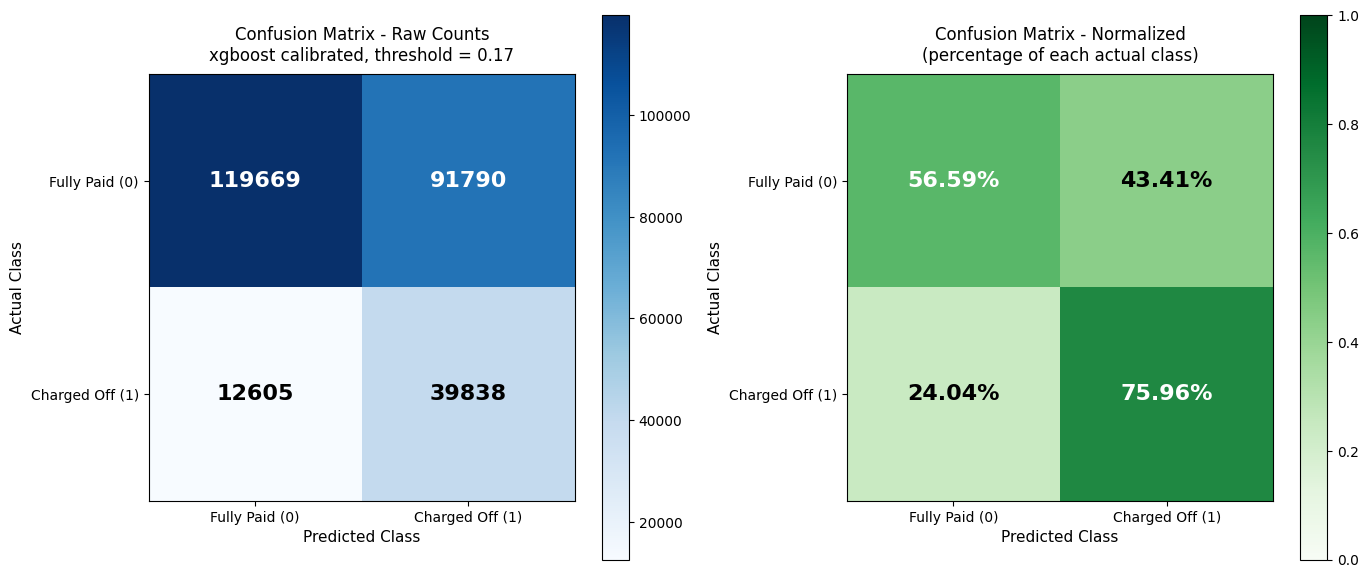

In [ ]:
# confusion matrix visualization

from sklearn.metrics import confusion_matrix

# get probabilities and predictions from the hero model on validation set
hero_proba = hero_model.predict_proba(X_val_final)[:, 1]
hero_preds = (hero_proba >= hero_threshold).astype(int)

# compute confusion matrix
cm = confusion_matrix(y_val, hero_preds)

# normalize so each row sums to 1
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# class labels
labels = ['Fully Paid (0)', 'Charged Off (1)']

# create the figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left panel raw counts
ax1 = axes[0]
im1 = ax1.imshow(cm, cmap='Blues')
ax1.set_title(f'Confusion Matrix - Raw Counts\n{hero_name} calibrated, threshold = {hero_threshold}',
              fontsize=12, pad=10)
ax1.set_xlabel('Predicted Class', fontsize=11)
ax1.set_ylabel('Actual Class', fontsize=11)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(labels)
ax1.set_yticklabels(labels)

# add the count numbers on top of each cell
for i in range(2):
    for j in range(2):
        # choose text color based on the cell intensity
        max_val = cm.max()
        if cm[i, j] > max_val / 2:
            text_color = 'white'
        else:
            text_color = 'black'
        ax1.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 fontsize=16, fontweight='bold',
                 color=text_color)

plt.colorbar(im1, ax=ax1)


# right panel normalized percentages
ax2 = axes[1]
im2 = ax2.imshow(cm_norm, cmap='Greens', vmin=0, vmax=1)
ax2.set_title('Confusion Matrix - Normalized\n(percentage of each actual class)',
              fontsize=12, pad=10)
ax2.set_xlabel('Predicted Class', fontsize=11)
ax2.set_ylabel('Actual Class', fontsize=11)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)

# add percentage numbers on top of each cell
for i in range(2):
    for j in range(2):
        pct = cm_norm[i, j] * 100
        if cm_norm[i, j] > 0.5:
            text_color = 'white'
        else:
            text_color = 'black'
        ax2.text(j, i, f"{pct:.2f}%",
                 ha='center', va='center',
                 fontsize=16, fontweight='bold',
                 color=text_color)

plt.colorbar(im2, ax=ax2)

plt.tight_layout()

# save the figure to working dir and drive
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
shutil.copy('confusion_matrix.png', DRIVE_PATH + '/confusion_matrix.png')
print("\nsaved confusion_matrix.png to working dir and drive")

plt.show()

In [ ]:
# """ END OF SECTION 6 FULL CHECKPOINT
# saves everything to drive in a structured way
# plus a raw backup of /content as a safety net
# plus a versioned snapshot of the notebook itself

# NOTE this cell is left as documentation only
# all artifacts were already saved during section 6 phases 11 and 12
# running this cell would just re-save the same files
# the code is kept here so the reader can see exactly how persistence works """


# from datetime import datetime

# # ============================================================
# # part 1 paths and helpers
# # ============================================================

# DRIVE_PATH = '/content/drive/MyDrive/MLLDP_artifacts'
# BACKUP_DEST = '/content/drive/MyDrive/MLLDP_artifacts/backup'

# # create folders if they dont exist
# if not os.path.exists(DRIVE_PATH):
#     os.makedirs(DRIVE_PATH)
# if not os.path.exists(BACKUP_DEST):
#     os.makedirs(BACKUP_DEST)

# # helper to save a single artifact to drive
# def save_one(obj, filename):
#     local_path = filename
#     joblib.dump(obj, local_path)
#     drive_target = DRIVE_PATH + '/' + filename
#     shutil.copy(local_path, drive_target)
#     size_kb = round(os.path.getsize(drive_target) / 1024, 2)
#     print(f"  saved {filename:<40} {size_kb} KB")

# # get a timestamp for naming the checkpoint
# now = datetime.now()
# timestamp = now.strftime('%Y_%m_%d_%H%M')
# print(f"checkpoint timestamp: {timestamp}")
# print()

# # ============================================================
# # part 2 save all named artifacts in 4 groups
# # ============================================================

# print("=" * 70)
# print("PART 2 STRUCTURED ARTIFACT SAVING")
# print("=" * 70)

# # group 1 section 5 preprocessing artifacts
# print("\n[group 1] section 5 preprocessing artifacts")
# save_one(encoder, 'onehot_encoder.pkl')
# save_one(median_dict, 'median_dict.pkl')
# save_one(mode_dict, 'mode_dict.pkl')
# save_one(onehot_cols, 'onehot_cols.pkl')
# save_one(cat_cols, 'cat_cols.pkl')
# save_one(num_cols, 'num_cols.pkl')
# save_one(continuous_cols, 'continuous_cols.pkl')
# save_one(scaler, 'scaler.pkl')
# save_one(clip_caps, 'clip_caps.pkl')
# save_one(cols_to_drop, 'multicollinearity_drops.pkl')
# save_one(final_features, 'final_feature_list.pkl')

# # group 2 data splits
# print("\n[group 2] data splits")
# save_one(X_train_final, 'X_train_final.pkl')
# save_one(X_val_final, 'X_val_final.pkl')
# save_one(X_test_final, 'X_test_final.pkl')
# save_one(y_train, 'y_train.pkl')
# save_one(y_val, 'y_val.pkl')
# save_one(y_test, 'y_test.pkl')

# # group 3 tuned and calibrated models
# print("\n[group 3] tuned and calibrated models")
# save_one(tuned_models['lightgbm'], 'tuned_lightgbm.pkl')
# save_one(tuned_models['xgboost'], 'tuned_xgboost.pkl')
# save_one(tuned_models['random_forest'], 'tuned_randomforest.pkl')
# save_one(tuned_models['stacking'], 'stacking_ensemble.pkl')
# save_one(tuned_results, 'tuned_results.pkl')
# save_one(calibrated_models['lightgbm'], 'calibrated_lightgbm.pkl')
# save_one(calibrated_models['xgboost'], 'calibrated_xgboost.pkl')
# save_one(calibrated_models['random_forest'], 'calibrated_random_forest.pkl')
# save_one(calibrated_models['stacking'], 'calibrated_stacking.pkl')
# save_one(calibrated_table, 'calibrated_table.pkl')

# # group 4 hero production artifacts
# print("\n[group 4] hero production artifacts")
# save_one(hero_model, 'hero_model.pkl')
# save_one(hero_name, 'hero_name.pkl')
# save_one(hero_threshold, 'hero_threshold.pkl')

# # ============================================================
# # part 3 full raw backup of /content as safety net
# # ============================================================

# print("\n" + "=" * 70)
# print("PART 3 RAW BACKUP OF /content")
# print("=" * 70)

# SOURCE = '/content'

# # folders we want to skip during backup
# skip_folders = ['drive', 'sample_data', 'lending-club', '.config', '.ipynb_checkpoints']

# # extensions we want to backup
# backup_extensions = ['.pkl', '.png', '.jpg', '.jpeg', '.csv', '.xlsx', '.json', '.txt']

# # walk through every file in /content
# files_copied = 0
# files_skipped = 0
# total_size_mb = 0

# print()

# for root, dirs, files in os.walk(SOURCE):
#     # filter out the skip folders so os walk doesnt go into them
#     dirs[:] = []
#     skip_this_root = False
#     for skip in skip_folders:
#         if skip in root:
#             skip_this_root = True
#             break

#     if skip_this_root:
#         continue

#     # only process files in the top level of /content for simplicity
#     if root != SOURCE:
#         continue

#     # loop through files in this folder
#     for filename in files:
#         # check if extension matches what we want to backup
#         ext_match = False
#         for ext in backup_extensions:
#             if filename.endswith(ext):
#                 ext_match = True
#                 break

#         if not ext_match:
#             files_skipped = files_skipped + 1
#             continue

#         # build the full source and destination paths
#         src_path = os.path.join(root, filename)
#         dst_path = os.path.join(BACKUP_DEST, filename)

#         # get file size in MB for the report
#         size_bytes = os.path.getsize(src_path)
#         size_mb = round(size_bytes / (1024 * 1024), 2)
#         total_size_mb = total_size_mb + size_mb

#         # copy the file
#         shutil.copy(src_path, dst_path)
#         files_copied = files_copied + 1

#         print(f"  copied {filename:<45} {size_mb} MB")

# print()
# print(f"raw backup complete")
# print(f"  files copied: {files_copied}")
# print(f"  files skipped (wrong extension): {files_skipped}")
# print(f"  total size: {round(total_size_mb, 2)} MB")

# Section 7 — Final Evaluation, SHAP and Streamlit Prep

section 6 ended with our hero model picked: calibrated xgboost at threshold 0.17.

section 7 has 8 phases that move us from "we have a tuned model" to "streamlit can deploy it":

1. final test set evaluation — first time we touch test set, this is the thesis number
2. shap local explanations for 4 example applicants
3. streamlit feature mapping
4. lookup pool for "similar past borrowers" feature
5. json schema and sample input files
6. production bundle


**Phase 1 — Final Test Set Evaluation**

we held out 20% of the data as test from the very first split in section 5 phase 3. since then we never touched it. not for tuning, not for calibration, not for threshold selection. nothing.

this phase is the first and ONLY time we run the hero model on x_test. the metrics here are what goes into the thesis report and what we defend in the interview.

if validation and test numbers are close (within 1-2 points) the model generalizes well. if there is a big gap we have an overfitting issue.

In [87]:
# install shap
import subprocess
subprocess.run(['pip', 'install', 'shap', '-q'])

import shap

In [88]:
""" phase 1 step 1 load hero artifacts and the locked test set
hero_model is the calibrated xgboost we picked in section 6 phase 11
test set was saved to drive in section 5 phase 3 stratified split
this is the first time we evaluate anything on x_test """

# load hero artifacts from drive (saved at end of section 6)
hero_model = joblib.load(DRIVE_PATH + '/hero_model.pkl')
hero_name = joblib.load(DRIVE_PATH + '/hero_name.pkl')
hero_threshold = joblib.load(DRIVE_PATH + '/hero_threshold.pkl')

# also load val and test data so we can compare side by side
X_val_final = joblib.load(DRIVE_PATH + '/X_val_final.pkl')
X_test_final = joblib.load(DRIVE_PATH + '/X_test_final.pkl')
y_val = joblib.load(DRIVE_PATH + '/y_val.pkl')
y_test = joblib.load(DRIVE_PATH + '/y_test.pkl')

print("loaded everything we need")
print(f"  hero model:        {hero_name}")
print(f"  hero threshold:    {hero_threshold}")
print(f"  X_val_final shape: {X_val_final.shape}")
print(f"  X_test_final shape:{X_test_final.shape}")

# defaulter counts in each set as a sanity check
print(f"\nclass distribution sanity check")
print(f"  val defaulters: {(y_val == 1).sum()}  ({round((y_val == 1).mean()*100, 2)}%)")
print(f"  test defaulters:{(y_test == 1).sum()}  ({round((y_test == 1).mean()*100, 2)}%)")


loaded everything we need
  hero model:        xgboost
  hero threshold:    0.17
  X_val_final shape: (263902, 40)
  X_test_final shape:(263902, 40)

class distribution sanity check
  val defaulters: 52443  (19.87%)
  test defaulters:52443  (19.87%)


In [89]:
""" phase 1 step 2 run hero on both val and test
we get probabilities then apply the 0.17 threshold to convert to binary preds
metrics are computed identically for both so the comparison is apples to apples """

# get calibrated probabilities for both sets
val_proba = hero_model.predict_proba(X_val_final)[:, 1]
test_proba = hero_model.predict_proba(X_test_final)[:, 1]

# apply hero threshold to get binary decisions
val_preds = (val_proba >= hero_threshold).astype(int)
test_preds = (test_proba >= hero_threshold).astype(int)

# metrics for validation set (same as section 6 phase 12 we expect identical numbers)
val_acc = accuracy_score(y_val, val_preds)
val_prec = precision_score(y_val, val_preds, zero_division=0)
val_rec = recall_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, zero_division=0)
val_f2 = fbeta_score(y_val, val_preds, beta=2, zero_division=0)
val_auc = roc_auc_score(y_val, val_proba)

# metrics for test set (this is the new info we never saw before)
test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, zero_division=0)
test_rec = recall_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds, zero_division=0)
test_f2 = fbeta_score(y_test, test_preds, beta=2, zero_division=0)
test_auc = roc_auc_score(y_test, test_proba)

print("metrics computed for both sets")


metrics computed for both sets


In [90]:
""" phase 1 step 3 print the comparison table
this is THE table for the thesis and the defense slides """

print("HERO MODEL FINAL EVALUATION - VALIDATION vs TEST")
print("=" * 75)
print(f"{'metric':<15} {'validation':<15} {'test':<15} {'gap':<10}")
print("-" * 75)

# helper to print a metric row with the gap
def print_row(name, val_score, test_score):
    gap = test_score - val_score
    gap_str = f"{round(gap, 4):+}"
    print(f"{name:<15} {round(val_score, 4):<15} {round(test_score, 4):<15} {gap_str:<10}")

print_row("accuracy",  val_acc,  test_acc)
print_row("precision", val_prec, test_prec)
print_row("recall",    val_rec,  test_rec)
print_row("f1",        val_f1,   test_f1)
print_row("f2",        val_f2,   test_f2)
print_row("auc",       val_auc,  test_auc)

print("=" * 75)

# overall gap on the headline metric (recall)
recall_gap = abs(test_rec - val_rec)
print()
if recall_gap <= 0.02:
    print(f"recall gap is {round(recall_gap, 4)} which is small")
    print("the model generalizes well from validation to test")
elif recall_gap <= 0.05:
    print(f"recall gap is {round(recall_gap, 4)} which is moderate")
    print("the model generalizes ok but there is some validation overfitting")
else:
    print(f"recall gap is {round(recall_gap, 4)} which is large")
    print("the model may be overfitting to validation set decisions")


HERO MODEL FINAL EVALUATION - VALIDATION vs TEST
metric          validation      test            gap       
---------------------------------------------------------------------------
accuracy        0.6044          0.6045          +0.0001   
precision       0.3027          0.303           +0.0004   
recall          0.7596          0.7614          +0.0018   
f1              0.4329          0.4335          +0.0006   
f2              0.5835          0.5846          +0.0011   
auc             0.73            0.7309          +0.0009   

recall gap is 0.0018 which is small
the model generalizes well from validation to test


In [91]:
""" phase 1 step 4 confusion matrix on test set
this gives us the actual counts of correctly caught defaulters vs missed ones
useful for the financial impact discussion in the thesis """

# count each cell of the confusion matrix
test_tp = ((test_preds == 1) & (y_test == 1)).sum()
test_fn = ((test_preds == 0) & (y_test == 1)).sum()
test_tn = ((test_preds == 0) & (y_test == 0)).sum()
test_fp = ((test_preds == 1) & (y_test == 0)).sum()

print("CONFUSION MATRIX ON TEST SET (held-out, never seen before)")
print("=" * 75)
print(f"  true positives  (correctly caught defaulters):    {test_tp:>7}")
print(f"  false negatives (missed defaulters):              {test_fn:>7}")
print(f"  true negatives  (correctly approved good loans):  {test_tn:>7}")
print(f"  false positives (rejected good borrowers):        {test_fp:>7}")
print()

# total counts and rates so we can see the operational picture
total_test = len(y_test)
predicted_default = test_tp + test_fp
predicted_paid = test_tn + test_fn

print(f"  total applicants in test set: {total_test}")
print(f"  predicted as default (rejected): {predicted_default}  ({round(predicted_default/total_test*100, 2)}%)")
print(f"  predicted as fully paid (approved): {predicted_paid}  ({round(predicted_paid/total_test*100, 2)}%)")
print("=" * 75)

# save the test metrics for the production bundle in phase 6 of this section
test_metrics = {
    'accuracy': test_acc,
    'precision': test_prec,
    'recall': test_rec,
    'f1': test_f1,
    'f2': test_f2,
    'auc': test_auc,
    'tp': int(test_tp),
    'fn': int(test_fn),
    'tn': int(test_tn),
    'fp': int(test_fp),
}
# save_artifact(test_metrics, 'test_metrics.pkl')


CONFUSION MATRIX ON TEST SET (held-out, never seen before)
  true positives  (correctly caught defaulters):      39932
  false negatives (missed defaulters):                12511
  true negatives  (correctly approved good loans):   119605
  false positives (rejected good borrowers):          91854

  total applicants in test set: 263902
  predicted as default (rejected): 131786  (49.94%)
  predicted as fully paid (approved): 132116  (50.06%)


**Phase 2 — SHAP Setup with KernelExplainer**

shap explains why the model made its prediction. it tells us which features pushed the probability up or down.

we use KernelExplainer because it is model-agnostic. it works on the calibrated model directly without needing to know the internal tree structure. this means the shap values match the calibrated probability the user sees, with no math gap.

KernelExplainer works by sampling. for each applicant we want to explain:
1. it generates 2000 perturbations of the applicant data
2. for each perturbation it gets the calibrated probability from the model
3. from the differences between those probabilities it estimates the shap value for each featur

2000 samples gives us mathematically exact reconstruction (zero difference)

In [92]:
""" phase 2 step 1 install shap and build the KernelExplainer
KernelExplainer needs a background dataset to use as the reference distribution
when it generates perturbations of an applicant.



we wrap hero_model.predict_proba in a small helper because KernelExplainer expects
a function that returns probabilities for class 1 only """


# load x_train_final because we need a small sample as the shap background
X_train_final = joblib.load(DRIVE_PATH + '/X_train_final.pkl')

# pick 100 random rows as the shap background
# 100 rows is plenty as the reference distribution for KernelExplainer
background_sample = X_train_final.sample(n=100, random_state=42)
print(f"background sample shape: {background_sample.shape}")

# wrap hero_model so KernelExplainer gets just the class 1 (default) probabilities
def predict_proba_class1(input_data):
    return hero_model.predict_proba(input_data)[:, 1]

# build the KernelExplainer with our wrapped function and the background
print("\nbuilding KernelExplainer...")
explainer = shap.KernelExplainer(predict_proba_class1, background_sample)
print("explainer ready")

# the expected value is the average prediction across background
# this is the baseline that shap values add to or subtract from
expected_value = explainer.expected_value
print(f"\nexpected value (baseline probability): {round(expected_value, 4)}")
print("this is the average predicted probability across the 100 background applicants")


background sample shape: (100, 40)

building KernelExplainer...
explainer ready

expected value (baseline probability): 0.1973
this is the average predicted probability across the 100 background applicants


In [93]:
""" phase 2 step 2 sanity check
the math says expected_value + sum(shap values) should equal model probability
we run on a single applicant and verify

KernelExplainer needs the nsamples argument to control accuracy """


# pick a single applicant from validation set as the test case
test_applicant_idx = 0
test_applicant = X_val_final.iloc[test_applicant_idx:test_applicant_idx+1]

# get the model probability so we have something to compare against
model_proba = hero_model.predict_proba(test_applicant)[0, 1]

print("computing shap values with 2000 samples...")
start = time.time()
shap_vals = explainer.shap_values(test_applicant, nsamples=2000)
elapsed = round(time.time() - start, 2)
print(f"shap computation done in {elapsed} seconds")

# shap_vals shape is (1, n_features) we take the first (only) row
shap_sum = shap_vals[0].sum()

# the math: expected_value + sum(shap_values) should equal model_proba
shap_reconstructed = expected_value + shap_sum

print("\nsanity check: does sum of shap values reconstruct the probability?")
print("=" * 65)
print(f"  model probability:                     {round(model_proba, 6)}")
print(f"  expected value (baseline):             {round(expected_value, 6)}")
print(f"  sum of shap values:                    {round(shap_sum, 6)}")
print(f"  expected_value + sum:                  {round(shap_reconstructed, 6)}")
print(f"  difference from model probability:     {round(abs(shap_reconstructed - model_proba), 6)}")
print("=" * 65)



computing shap values with 2000 samples...


  0%|          | 0/1 [00:00<?, ?it/s]

shap computation done in 2.33 seconds

sanity check: does sum of shap values reconstruct the probability?
  model probability:                     0.189933
  expected value (baseline):             0.197282
  sum of shap values:                    -0.007349
  expected_value + sum:                  0.189933
  difference from model probability:     0.0


In [94]:
all_train_proba = hero_model.predict_proba(X_train_final)[:, 1]
true_baseline = all_train_proba.mean()
print(f"true baseline = {true_baseline}")

true baseline = 0.19872853517523845


In [95]:
""" phase 2 step 3 save what we need for later phases of section 7
and for the streamlit app

we save the pieces streamlit needs to rebuild the explainer at startup
the explainer object itself does not pickle reliably so we save the inputs """

# save the pieces streamlit needs
shap_setup = {
    'background_sample': background_sample,
    'expected_value': expected_value,
    'feature_names': X_train_final.columns.tolist(),
    'nsamples': 2000,
    'explainer_type': 'KernelExplainer',
}

# save_artifact(shap_setup, 'shap_setup.pkl')

print("saved shap_setup.pkl which contains:")
print(f"  background_sample:   {background_sample.shape[0]} rows x {background_sample.shape[1]} cols")
print(f"  expected_value:      {round(expected_value, 4)}")
print(f"  feature_names:       {len(shap_setup['feature_names'])} features")
print(f"  nsamples:            {shap_setup['nsamples']}")
print(f"  explainer_type:      {shap_setup['explainer_type']}")
print()
print("streamlit will load this and rebuild the KernelExplainer at startup")

saved shap_setup.pkl which contains:
  background_sample:   100 rows x 40 cols
  expected_value:      0.1973
  feature_names:       40 features
  nsamples:            2000
  explainer_type:      KernelExplainer

streamlit will load this and rebuild the KernelExplainer at startup


**Phase 3 - SHAP Local Explanations on 5 Examples**

phase 2 confirmed our shap setup works. now we use it to explain individual applicant decisions. we pick 5 representative cases from the test set so they are completely unseen by everyone (including us) until now.

the 5 cases give us complete coverage of the confusion matrix:
1. high confidence default (true positive) - model correctly rejected a defaulter
2. high confidence approval (true negative) - model correctly approved a good loan
3. borderline case - probability close to 0.17, hardest to call
4. misclassification (false negative) - model approved but applicant defaulted - the costly mistake
5. misclassification (false positive) - model rejected but applicant paid - the opportunity cost mistake

cases 4 and 5 together honestly show where the model fails on both sides of the confusion matrix

for each case we generate a waterfall plot showing how each feature pushed the probability up or down. we also save the data so streamlit can use it.

In [122]:
""" phase 3 step 1 pick 4 representative applicants from test set
we already have test_proba and test_preds from section 7 phase 1
we use those to find applicants matching each scenario """

# rebuild the test predictions if they are not in memory anymore
if 'test_proba' not in dir():
    test_proba = hero_model.predict_proba(X_test_final)[:, 1]
    test_preds = (test_proba >= hero_threshold).astype(int)

# case 1 high confidence default (true positive)
# we want predicted_default = 1, actual = 1, with high probability
tp_mask = (test_preds == 1) & (y_test == 1)
tp_indices = np.where(tp_mask)[0]
tp_probas = test_proba[tp_indices]
case1_idx = tp_indices[tp_probas.argmax()]

# case 2 high confidence approval (true negative)
# we want predicted_default = 0, actual = 0, with low probability
tn_mask = (test_preds == 0) & (y_test == 0)
tn_indices = np.where(tn_mask)[0]
tn_probas = test_proba[tn_indices]
case2_idx = tn_indices[tn_probas.argmin()]

# case 3 borderline (closest to threshold 0.17)
distance_from_threshold = np.abs(test_proba - hero_threshold)
case3_idx = distance_from_threshold.argmin()

# case 4 misclassification - false negative
# model said pay but applicant actually defaulted (the costly mistake)
fn_mask = (test_preds == 0) & (y_test == 1)
fn_indices = np.where(fn_mask)[0]
fn_probas = test_proba[fn_indices]
case4_idx = fn_indices[fn_probas.argmin()]

# case 5 false positive
# model said reject but applicant actually paid (the opportunity cost mistake)
fp_mask = (test_preds == 1) & (y_test == 0)
fp_indices = np.where(fp_mask)[0]
fp_probas = test_proba[fp_indices]
case5_idx = fp_indices[fp_probas.argmax()]

cases = [
    {
        'name': 'case 1 high confidence default',
        'subtitle': 'true positive - model correctly caught a defaulter',
        'idx': case1_idx,
        'true_label': int(y_test.iloc[case1_idx]),
        'proba': float(test_proba[case1_idx]),
        'pred': int(test_preds[case1_idx]),
    },
    {
        'name': 'case 2 high confidence approval',
        'subtitle': 'true negative - model correctly approved a good loan',
        'idx': case2_idx,
        'true_label': int(y_test.iloc[case2_idx]),
        'proba': float(test_proba[case2_idx]),
        'pred': int(test_preds[case2_idx]),
    },
    {
        'name': 'case 3 borderline',
        'subtitle': f'closest to threshold {hero_threshold} - hardest to call',
        'idx': case3_idx,
        'true_label': int(y_test.iloc[case3_idx]),
        'proba': float(test_proba[case3_idx]),
        'pred': int(test_preds[case3_idx]),
    },
    {
        'name': 'case 4 false negative',
        'subtitle': 'misclassification - model approved but applicant defaulted',
        'idx': case4_idx,
        'true_label': int(y_test.iloc[case4_idx]),
        'proba': float(test_proba[case4_idx]),
        'pred': int(test_preds[case4_idx]),
    },

    {
        'name': 'case 5 false positive',
        'subtitle': 'misclassification - model rejected but applicant actually paid',
        'idx': case5_idx,
        'true_label': int(y_test.iloc[case5_idx]),
        'proba': float(test_proba[case5_idx]),
        'pred': int(test_preds[case5_idx]),
    },
]

print("PICKED 5 EXAMPLES FROM TEST SET")
print("=" * 75)
for c in cases:
    decision = "REJECT" if c['pred'] == 1 else "APPROVE"
    actual = "defaulted" if c['true_label'] == 1 else "paid"
    correct = "correct" if c['pred'] == c['true_label'] else "WRONG"
    print(f"\n{c['name']}")
    print(f"  {c['subtitle']}")
    print(f"  test_idx:    {c['idx']}")
    print(f"  probability: {round(c['proba'], 4)}")
    print(f"  decision:    {decision}")
    print(f"  actual:      {actual}")
    print(f"  status:      {correct}")
print()
print("=" * 75)


PICKED 5 EXAMPLES FROM TEST SET

case 1 high confidence default
  true positive - model correctly caught a defaulter
  test_idx:    189242
  probability: 0.9165
  decision:    REJECT
  actual:      defaulted
  status:      correct

case 2 high confidence approval
  true negative - model correctly approved a good loan
  test_idx:    14497
  probability: 0.0
  decision:    APPROVE
  actual:      paid
  status:      correct

case 3 borderline
  closest to threshold 0.17 - hardest to call
  test_idx:    72769
  probability: 0.17
  decision:    REJECT
  actual:      paid
  status:      WRONG

case 4 false negative
  misclassification - model approved but applicant defaulted
  test_idx:    105820
  probability: 0.0035
  decision:    APPROVE
  actual:      defaulted
  status:      WRONG

case 5 false positive
  misclassification - model rejected but applicant actually paid
  test_idx:    27404
  probability: 0.8634
  decision:    REJECT
  actual:      paid
  status:      WRONG



In [123]:
""" phase 3 step 2 compute shap values for all 5 cases
 """

print("computing shap values for the 4 test cases...")
print()

for c in cases:
    start = time.time()

    applicant = X_test_final.iloc[[c['idx']]]
    shap_v = explainer.shap_values(applicant, nsamples=200)

    c['applicant_data'] = applicant.iloc[0].to_dict()
    c['shap_values'] = shap_v[0]

    reconstructed = expected_value + shap_v[0].sum()
    c['reconstructed_proba'] = float(reconstructed)
    c['reconstruction_diff'] = float(abs(reconstructed - c['proba']))

    elapsed = round(time.time() - start, 2)
    print(f"{c['name']}: shap done in {elapsed}s | diff: {round(c['reconstruction_diff'], 6)}")

print()
print("all 5 cases have shap values ready")


computing shap values for the 4 test cases...



  0%|          | 0/1 [00:00<?, ?it/s]

case 1 high confidence default: shap done in 0.41s | diff: 0.0


  0%|          | 0/1 [00:00<?, ?it/s]

case 2 high confidence approval: shap done in 0.45s | diff: 0.0


...

case 3 borderline: shap done in 0.4s | diff: 0.0


  0%|          | 0/1 [00:00<?, ?it/s]

case 4 false negative: shap done in 0.4s | diff: 0.0


  0%|          | 0/1 [00:00<?, ?it/s]

case 5 false positive: shap done in 0.4s | diff: 0.0

all 5 cases have shap values ready


**Replot Phase 3 Waterfall - One Image Per Cell**

each of the next 4 cells plots one waterfall so the images are not stacked together.
we use plt.close('all') at the start to make sure no leftover figure messes up the output.

case 1 high confidence default
  true positive - model correctly caught a defaulter
  probability: 0.9165 | decision: REJECT



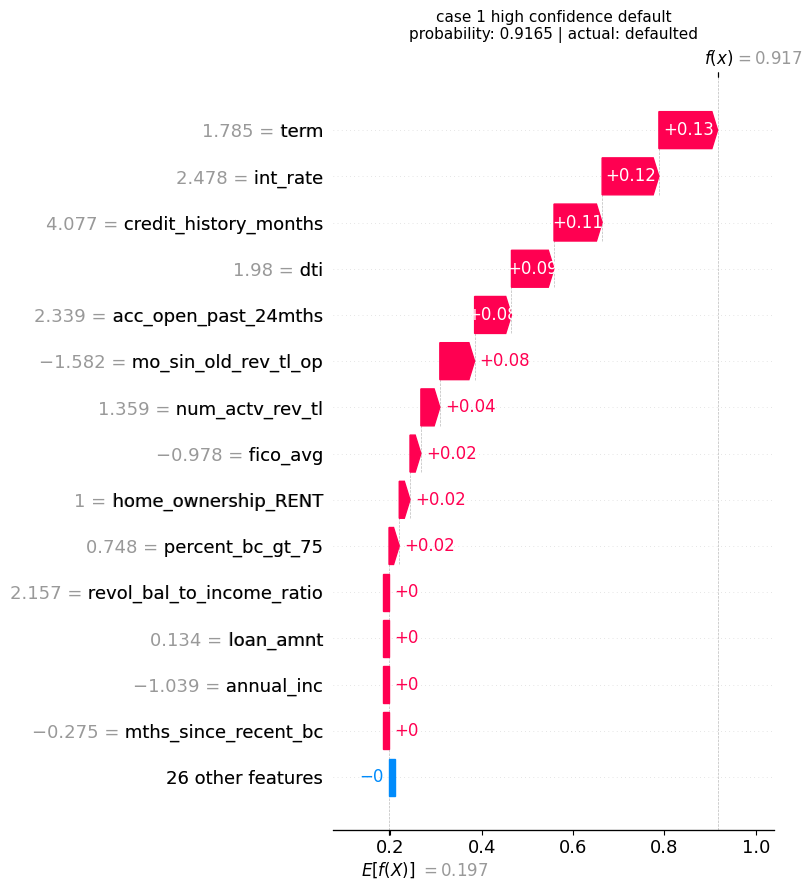

  saved to drive: phase3_waterfall_case_1_high_confidence_default.png


In [115]:
""" plot waterfall for case 1 on its own """



plt.close('all')

c = cases[0]

print(f"{c['name']}")
print(f"  {c['subtitle']}")
print(f"  probability: {round(c['proba'], 4)} | decision: {'REJECT' if c['pred'] == 1 else 'APPROVE'}")
print()

feature_names = X_train_final.columns.tolist()

explanation = shap.Explanation(
    values=c['shap_values'],
    base_values=expected_value,
    data=np.array(list(c['applicant_data'].values())),
    feature_names=feature_names,
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
actual_str = 'defaulted' if c['true_label'] == 1 else 'paid'
plt.title(f"{c['name']}\nprobability: {round(c['proba'], 4)} | actual: {actual_str}", fontsize=11)
plt.tight_layout()

fig_filename = f"phase3_waterfall_{c['name'].replace(' ', '_')}.png"
plt.savefig(fig_filename, dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

# shutil.copy(fig_filename, DRIVE_PATH + '/' + fig_filename)
print(f"  saved to drive: {fig_filename}")


case 2 high confidence approval
  true negative - model correctly approved a good loan
  probability: 0.0 | decision: APPROVE



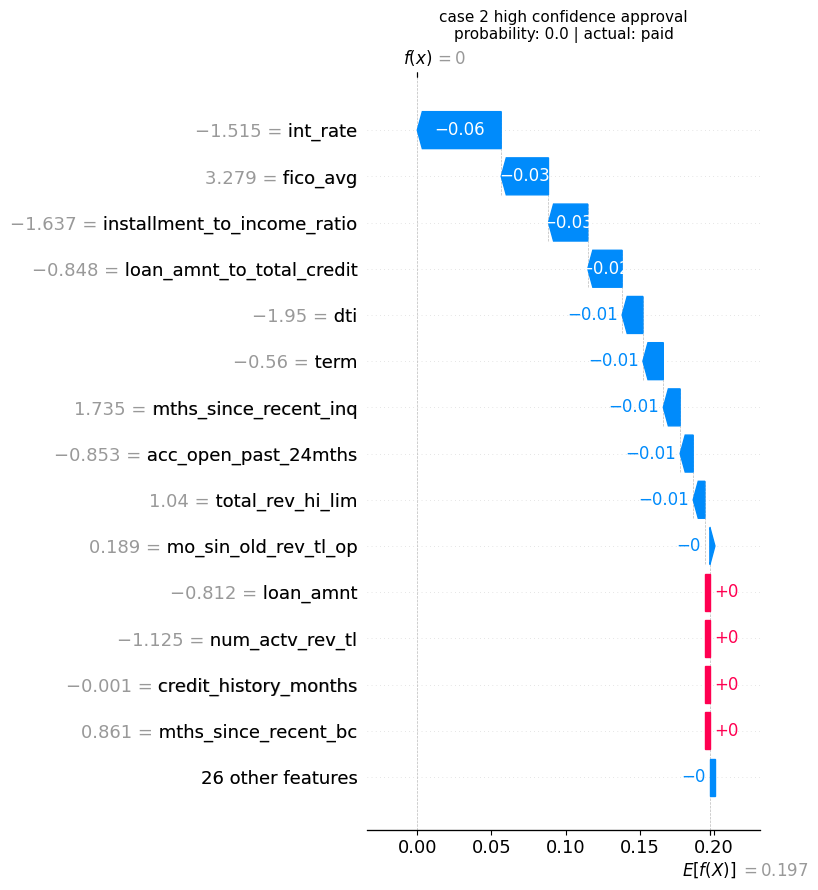

  saved to drive: phase3_waterfall_case_2_high_confidence_approval.png


In [116]:
""" plot waterfall for case 2 on its own """



plt.close('all')

c = cases[1]

print(f"{c['name']}")
print(f"  {c['subtitle']}")
print(f"  probability: {round(c['proba'], 4)} | decision: {'REJECT' if c['pred'] == 1 else 'APPROVE'}")
print()

feature_names = X_train_final.columns.tolist()

explanation = shap.Explanation(
    values=c['shap_values'],
    base_values=expected_value,
    data=np.array(list(c['applicant_data'].values())),
    feature_names=feature_names,
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
actual_str = 'defaulted' if c['true_label'] == 1 else 'paid'
plt.title(f"{c['name']}\nprobability: {round(c['proba'], 4)} | actual: {actual_str}", fontsize=11)
plt.tight_layout()

fig_filename = f"phase3_waterfall_{c['name'].replace(' ', '_')}.png"
plt.savefig(fig_filename, dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

# shutil.copy(fig_filename, DRIVE_PATH + '/' + fig_filename)
print(f"  saved to drive: {fig_filename}")


case 3 borderline
  closest to threshold 0.17 - hardest to call
  probability: 0.17 | decision: REJECT



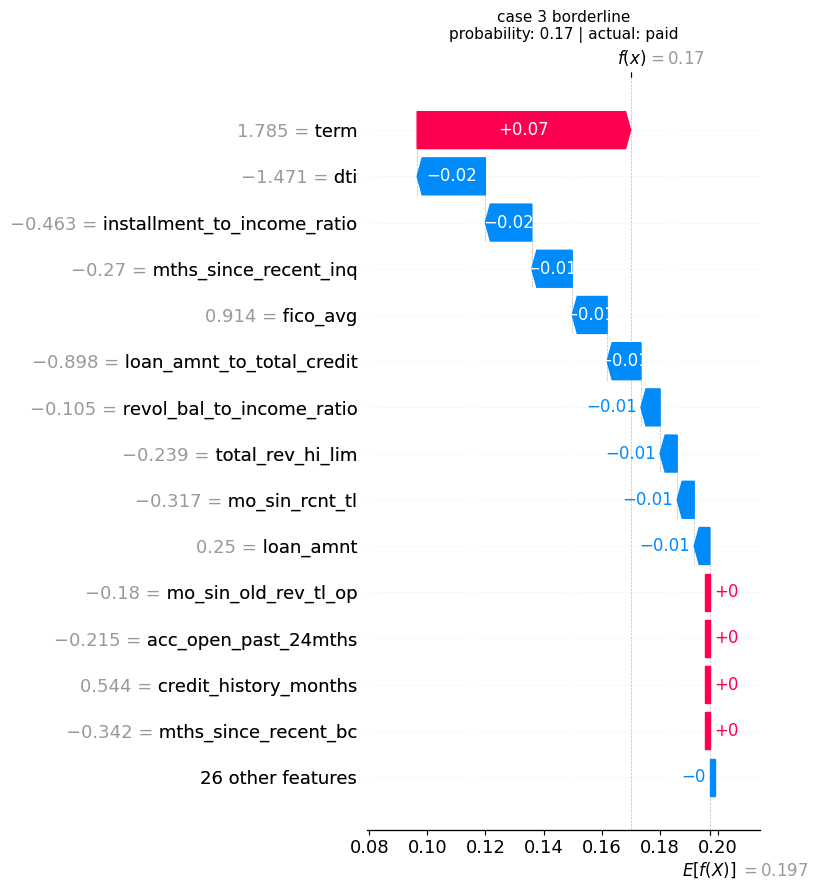

  saved to drive: phase3_waterfall_case_3_borderline.png


In [117]:
""" plot waterfall for case 3 on its own """


plt.close('all')

c = cases[2]

print(f"{c['name']}")
print(f"  {c['subtitle']}")
print(f"  probability: {round(c['proba'], 4)} | decision: {'REJECT' if c['pred'] == 1 else 'APPROVE'}")
print()

feature_names = X_train_final.columns.tolist()

explanation = shap.Explanation(
    values=c['shap_values'],
    base_values=expected_value,
    data=np.array(list(c['applicant_data'].values())),
    feature_names=feature_names,
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
actual_str = 'defaulted' if c['true_label'] == 1 else 'paid'
plt.title(f"{c['name']}\nprobability: {round(c['proba'], 4)} | actual: {actual_str}", fontsize=11)
plt.tight_layout()

fig_filename = f"phase3_waterfall_{c['name'].replace(' ', '_')}.png"
plt.savefig(fig_filename, dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

# shutil.copy(fig_filename, DRIVE_PATH + '/' + fig_filename)
print(f"  saved to drive: {fig_filename}")


case 4 false negative
  misclassification - model approved but applicant defaulted
  probability: 0.0035 | decision: APPROVE



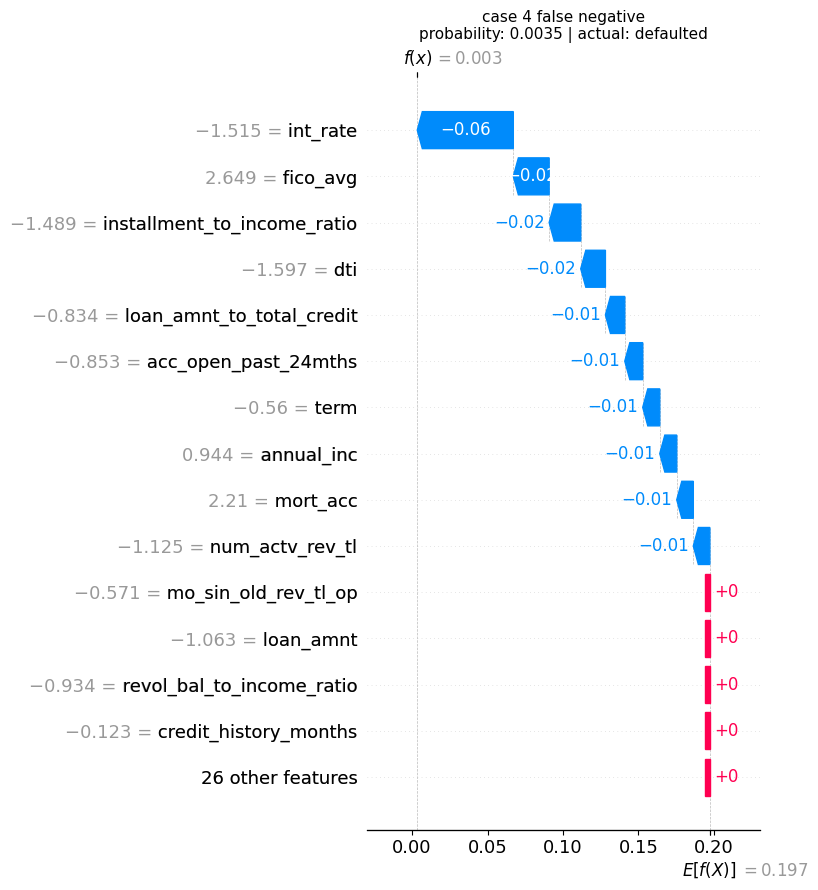

  saved to drive: phase3_waterfall_case_4_false_negative.png


In [118]:
""" plot waterfall for case 4 on its own """


plt.close('all')

c = cases[3]

print(f"{c['name']}")
print(f"  {c['subtitle']}")
print(f"  probability: {round(c['proba'], 4)} | decision: {'REJECT' if c['pred'] == 1 else 'APPROVE'}")
print()

feature_names = X_train_final.columns.tolist()

explanation = shap.Explanation(
    values=c['shap_values'],
    base_values=expected_value,
    data=np.array(list(c['applicant_data'].values())),
    feature_names=feature_names,
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
actual_str = 'defaulted' if c['true_label'] == 1 else 'paid'
plt.title(f"{c['name']}\nprobability: {round(c['proba'], 4)} | actual: {actual_str}", fontsize=11)
plt.tight_layout()

fig_filename = f"phase3_waterfall_{c['name'].replace(' ', '_')}.png"
plt.savefig(fig_filename, dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

# shutil.copy(fig_filename, DRIVE_PATH + '/' + fig_filename)
print(f"  saved to drive: {fig_filename}")


case 5 false positive
  misclassification - model rejected but applicant actually paid
  probability: 0.8634 | decision: REJECT



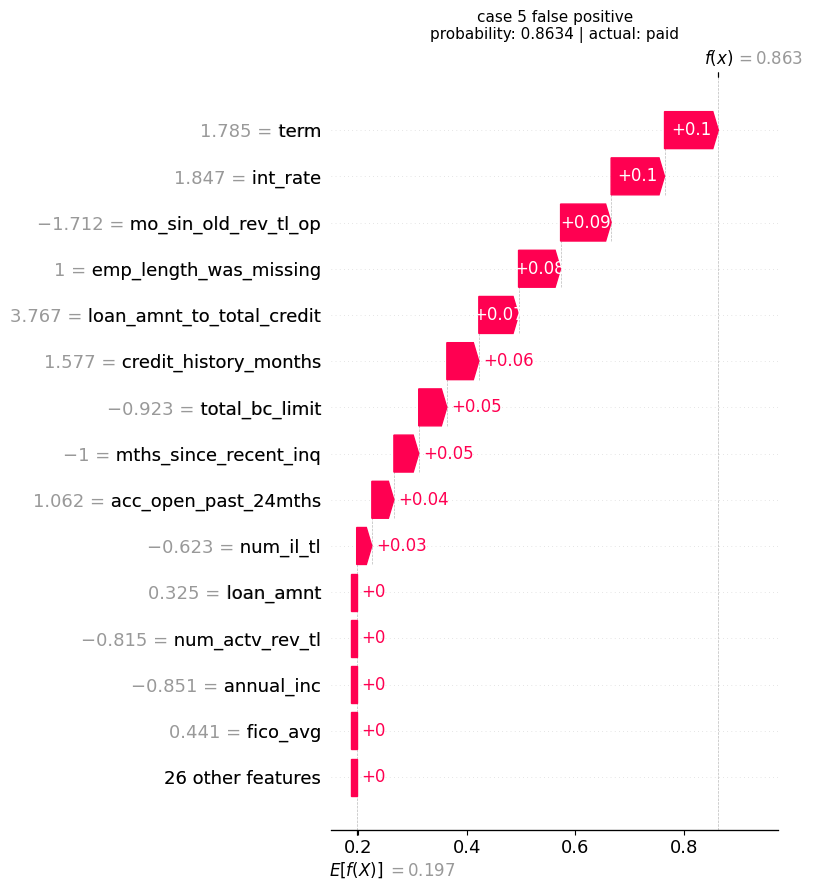

  saved to drive: phase3_waterfall_case_5_false_positive.png


In [119]:
""" plot waterfall for case 5 on its own """


plt.close('all')

c = cases[4]

print(f"{c['name']}")
print(f"  {c['subtitle']}")
print(f"  probability: {round(c['proba'], 4)} | decision: {'REJECT' if c['pred'] == 1 else 'APPROVE'}")
print()

feature_names = X_train_final.columns.tolist()

explanation = shap.Explanation(
    values=c['shap_values'],
    base_values=expected_value,
    data=np.array(list(c['applicant_data'].values())),
    feature_names=feature_names,
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
actual_str = 'defaulted' if c['true_label'] == 1 else 'paid'
plt.title(f"{c['name']}\nprobability: {round(c['proba'], 4)} | actual: {actual_str}", fontsize=11)
plt.tight_layout()

fig_filename = f"phase3_waterfall_{c['name'].replace(' ', '_')}.png"
plt.savefig(fig_filename, dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

# shutil.copy(fig_filename, DRIVE_PATH + '/' + fig_filename)
print(f"  saved to drive: {fig_filename}")


In [121]:
""" phase 3 step 4 save the 5 examples in a clean structure
this gets used in the thesis report and also feeds into phase 3.5 demo cases """

phase3_examples = []
for c in cases:
    clean_case = {
        'name': c['name'],
        'subtitle': c['subtitle'],
        'test_idx': int(c['idx']),
        'true_label': c['true_label'],
        'probability': c['proba'],
        'prediction': c['pred'],
        'applicant_features': c['applicant_data'],
        'shap_values': c['shap_values'].tolist(),
        'reconstructed_proba': c['reconstructed_proba'],
        'reconstruction_diff': c['reconstruction_diff'],
    }
    phase3_examples.append(clean_case)

save_artifact(phase3_examples, 'phase3_examples.pkl')

print("saved phase3_examples.pkl with 5 explained cases")
print()
print("each entry contains:")
print("  name, subtitle")
print("  test_idx, true_label, probability, prediction")
print("  applicant_features (40 raw values)")
print("  shap_values (40 shap contributions)")
print("  reconstructed_proba (sanity check)")


saved phase3_examples.pkl to both working dir and drive
saved phase3_examples.pkl with 5 explained cases

each entry contains:
  name, subtitle
  test_idx, true_label, probability, prediction
  applicant_features (40 raw values)
  shap_values (40 shap contributions)
  reconstructed_proba (sanity check)


**Pick 5 Demo Cases for Streamlit**

phase 3 gave us 5 academic cases for the thesis. for streamlit we want a slightly different lineup tailored for live demo to the loan officer or the defense committee.

the 5 demo cases:
1. clearly strong borrower - low probability, easy approve
2. moderate risk borrower - probability around 0.10
3. high risk borrower who actually defaulted - the model called it right
4. borderline applicant - probability close to 0.17
5. misclassified case (false positive) - rejected by model but actually paid - shows the model is not perfect

we want the 5 cases to tell 5 different stories so we filter each one to match the right outcome. for example High Risk needs to be someone who actually defaulted otherwise the demo just shows the model being wrong twice.

we precompute shap values for all 5 cases and store them so streamlit can show them instantly without recomputing.

In [153]:
# @title
""" step 1 pick 5 demo cases from test set
each filter checks the actual outcome too so the cases tell different stories """

# demo 1 strong borrower (low probability AND actually paid)
strong_mask = (test_proba >= 0.03) & (test_proba <= 0.05) & (y_test == 0)
strong_indices = np.where(strong_mask)[0]
demo1_idx = strong_indices[0] if len(strong_indices) > 0 else test_proba.argmin()

# demo 2 moderate risk (low probability AND actually paid - to show approve was right)
moderate_mask = (test_proba >= 0.09) & (test_proba <= 0.11) & (y_test == 0)
moderate_indices = np.where(moderate_mask)[0]
demo2_idx = moderate_indices[0] if len(moderate_indices) > 0 else 0

# demo 3 high risk WHO ACTUALLY DEFAULTED (this is the key fix)
# we want a case that shows "model said high risk - applicant defaulted - model was right"
high_default_mask = (test_proba >= 0.38) & (test_proba <= 0.42) & (y_test == 1)
high_default_indices = np.where(high_default_mask)[0]
demo3_idx = high_default_indices[0] if len(high_default_indices) > 0 else 0

# demo 4 borderline (probability around 0.17 - any outcome is fine since this is the hard call)
border_mask = (test_proba >= 0.165) & (test_proba <= 0.175)
border_indices = np.where(border_mask)[0]
demo4_idx = border_indices[0] if len(border_indices) > 0 else 0

# demo 5 false positive (rejected by model but actually paid)
# pick the most confidently wrong rejection
fp_mask = (test_preds == 1) & (y_test == 0)
fp_indices = np.where(fp_mask)[0]
fp_probas = test_proba[fp_indices]
demo5_idx = fp_indices[fp_probas.argmax()] if len(fp_indices) > 0 else 0

demo_cases_raw = [
    {
        'name': 'Strong Borrower',
        'description': 'Low risk profile, very likely to repay',
        'idx': demo1_idx,
    },
    {
        'name': 'Moderate Risk',
        'description': 'Below threshold but worth reviewing',
        'idx': demo2_idx,
    },
    {
        'name': 'High Risk',
        'description': 'Clear rejection candidate, model correctly predicted default',
        'idx': demo3_idx,
    },
    {
        'name': 'Borderline',
        'description': f'Right around the {hero_threshold} threshold',
        'idx': demo4_idx,
    },
    {
        'name': 'False Positive',
        'description': 'Model rejected but applicant actually paid - shows model limits',
        'idx': demo5_idx,
    },
]

print("PICKED 5 DEMO CASES")
print("=" * 75)
for d in demo_cases_raw:
    idx = d['idx']
    proba = test_proba[idx]
    pred = test_preds[idx]
    actual = y_test.iloc[idx]
    decision = "REJECT" if pred == 1 else "APPROVE"
    actual_str = "defaulted" if actual == 1 else "paid"

    print(f"\n{d['name']}")
    print(f"  {d['description']}")
    print(f"  probability: {round(proba, 4)}")
    print(f"  decision:    {decision}")
    print(f"  actual:      {actual_str}")
print()
print("=" * 75)


PICKED 5 DEMO CASES

Strong Borrower
  Low risk profile, very likely to repay
  probability: 0.0326
  decision:    APPROVE
  actual:      paid

Moderate Risk
  Below threshold but worth reviewing
  probability: 0.0994
  decision:    APPROVE
  actual:      paid

High Risk
  Clear rejection candidate, model correctly predicted default
  probability: 0.4126
  decision:    REJECT
  actual:      defaulted

Borderline
  Right around the 0.17 threshold
  probability: 0.1703
  decision:    REJECT
  actual:      paid

False Positive
  Model rejected but applicant actually paid - shows model limits
  probability: 0.8634
  decision:    REJECT
  actual:      paid



In [154]:
""" compute shap for the 5 demo cases and split features into form + json groups """



streamlit_features = joblib.load(DRIVE_PATH + '/streamlit_features.pkl')
form_field_names = list(streamlit_features['form_inputs'].keys())
json_field_names = streamlit_features['json_inputs']

streamlit_demo_cases = []

print("computing shap for 5 demo cases...")
print()

for d in demo_cases_raw:
    start = time.time()

    idx = d['idx']
    applicant = X_test_final.iloc[[idx]]
    applicant_dict = applicant.iloc[0].to_dict()

    proba = float(test_proba[idx])
    pred = int(test_preds[idx])
    actual = int(y_test.iloc[idx])

    shap_v = explainer.shap_values(applicant, nsamples=200)

    form_values = {}
    for f in form_field_names:
        if f in applicant_dict:
            form_values[f] = applicant_dict[f]

    json_values = {}
    for f in json_field_names:
        if f in applicant_dict:
            json_values[f] = applicant_dict[f]


    case = {
        'name': d['name'],
        'description': d['description'],
        'test_idx': int(idx),
        'probability': proba,
        'prediction': pred,
        'actual_label': actual,
        'decision': 'REJECT' if pred == 1 else 'APPROVE',
        'form_values': form_values,
        'json_values': json_values,
        'applicant_features': applicant_dict,
        'shap_values': shap_v[0].tolist(),
        'expected_value': float(expected_value),
    }
    streamlit_demo_cases.append(case)

    elapsed = round(time.time() - start, 2)
    print(f"  {d['name']}: shap done in {elapsed}s | form={len(form_values)} | json={len(json_values)}")

save_artifact(streamlit_demo_cases, 'streamlit_demo_cases.pkl')

print()
print("=" * 75)
print(f"saved streamlit_demo_cases.pkl with {len(streamlit_demo_cases)} demo cases")
print("=" * 75)

computing shap for 5 demo cases...



  0%|          | 0/1 [00:00<?, ?it/s]

  Strong Borrower: shap done in 0.2s | form=12 | json=17


  0%|          | 0/1 [00:00<?, ?it/s]

  Moderate Risk: shap done in 0.21s | form=12 | json=17


...

  High Risk: shap done in 0.2s | form=12 | json=17


  0%|          | 0/1 [00:00<?, ?it/s]

  Borderline: shap done in 0.19s | form=12 | json=17


  0%|          | 0/1 [00:00<?, ?it/s]

  False Positive: shap done in 0.19s | form=12 | json=17
saved streamlit_demo_cases.pkl to both working dir and drive

saved streamlit_demo_cases.pkl with 5 demo cases


In [155]:
""" splits the 40 production features into 3 sources
defaults come from median_dict (raw values from training before scaling)
min/max are sensible hardcoded ranges for form ui validation """

# load median_dict which holds raw (pre-scaling) medians from training
median_dict = joblib.load(DRIVE_PATH + '/median_dict.pkl')
X_train_final = joblib.load(DRIVE_PATH + '/X_train_final.pkl')

# helper to find which one-hot category dominates in training
def get_dominant_onehot(prefix, options):
    best_option = options[0]
    best_count = -1
    for opt in options:
        col_name = prefix + '_' + opt
        if col_name in X_train_final.columns:
            count = X_train_final[col_name].sum()
            if count > best_count:
                best_count = count
                best_option = opt
    return best_option

# 14 fields the loan officer types into the form
form_inputs = {}

# loan_amnt
form_inputs['loan_amnt'] = {
    'label': 'Loan Amount (USD)',
    'type': 'number',
    'min': 1000, 'max': 40000, 'step': 100,
    'default': round(median_dict['loan_amnt']),
}

# int_rate
form_inputs['int_rate'] = {
    'label': 'Interest Rate (%)',
    'type': 'number',
    'min': 5.0, 'max': 30.0, 'step': 0.1,
    'default': round(median_dict['int_rate'], 2),
}

# term (select, mode from training)
form_inputs['term'] = {
    'label': 'Loan Term (months)',
    'type': 'select',
    'options': [36, 60],
    'default': int(median_dict['term']),
}

# installment
form_inputs['installment'] = {
    'label': 'Monthly Installment (USD)',
    'type': 'number',
    'min': 30, 'max': 1500, 'step': 1,
    'default': round(median_dict['installment']),
}

# purpose (debt_consolidation is the known mode in Lending Club)
form_inputs['purpose'] = {
    'label': 'Loan Purpose',
    'type': 'select',
    'options': [
        'debt_consolidation', 'credit_card', 'home_improvement',
        'small_business', 'major_purchase', 'medical',
        'car', 'vacation', 'wedding', 'house', 'moving',
        'educational', 'renewable_energy', 'other',
    ],
    'default': 'debt_consolidation',
}

# annual_inc
form_inputs['annual_inc'] = {
    'label': 'Annual Income (USD)',
    'type': 'number',
    'min': 10000, 'max': 300000, 'step': 1000,
    'default': round(median_dict['annual_inc']),
}

# emp_length
form_inputs['emp_length'] = {
    'label': 'Employment Length (years)',
    'type': 'number',
    'min': 0, 'max': 10, 'step': 1,
    'default': int(median_dict['emp_length']),
    'allow_missing': True,
}

# home_ownership (dominant from one-hot columns)
home_default = get_dominant_onehot('home_ownership', ['RENT', 'MORTGAGE'])
form_inputs['home_ownership'] = {
    'label': 'Home Ownership',
    'type': 'select',
    'options': ['RENT', 'OWN', 'MORTGAGE', 'OTHER', 'ANY'],
    'default': home_default,
}

# mort_acc
form_inputs['mort_acc'] = {
    'label': 'Mortgage Accounts',
    'type': 'number',
    'min': 0, 'max': 20, 'step': 1,
    'default': int(median_dict['mort_acc']),
}

# num_actv_bc_tl
form_inputs['num_actv_bc_tl'] = {
    'label': 'Active Bankcards',
    'type': 'number',
    'min': 0, 'max': 50, 'step': 1,
    'default': int(median_dict['num_actv_bc_tl']),
}

# total_bc_limit
form_inputs['total_bc_limit'] = {
    'label': 'Total Bankcard Limit (USD)',
    'type': 'number',
    'min': 0, 'max': 200000, 'step': 100,
    'default': round(median_dict['total_bc_limit']),
}

# num_bc_sats
form_inputs['num_bc_sats'] = {
    'label': 'Satisfactory Bankcards',
    'type': 'number',
    'min': 0, 'max': 50, 'step': 1,
    'default': int(median_dict['num_bc_sats']),
}

# num_rev_accts
form_inputs['num_rev_accts'] = {
    'label': 'Revolving Accounts',
    'type': 'number',
    'min': 0, 'max': 100, 'step': 1,
    'default': int(median_dict['num_rev_accts']),
}

# num_il_tl
form_inputs['num_il_tl'] = {
    'label': 'Installment Trade Lines',
    'type': 'number',
    'min': 0, 'max': 50, 'step': 1,
    'default': int(median_dict['num_il_tl']),
}

# raw fields that don't enter the model directly (get one-hot encoded)
raw_categorical_inputs = ['home_ownership', 'purpose']

# 17 fields uploaded via JSON file
json_inputs = [
    'fico_avg',
    'revol_bal',
    'total_rev_hi_lim',
    'delinq_2yrs',
    'total_acc',
    'num_actv_rev_tl',
    'acc_open_past_24mths',
    'credit_history_months',
    'mo_sin_old_rev_tl_op',
    'num_tl_op_past_12m',
    'mo_sin_rcnt_tl',
    'bc_open_to_buy',
    'mths_since_recent_bc',
    'mths_since_recent_inq',
    'percent_bc_gt_75',
    'avg_cur_bal',
    'mo_sin_old_il_acct',
]

# 7 ratios the app computes (4 engineered + dti + revol_util + bc_util)
derived_formulas = {
    'installment_to_income_ratio': 'installment / (annual_inc/12 + 1)',
    'loan_amnt_to_total_credit': 'loan_amnt / (total_rev_hi_lim + 1)',
    'revol_bal_to_income_ratio': 'revol_bal / (annual_inc + 1)',
    'debt_to_credit_ratio': 'revol_bal / (total_rev_hi_lim + 1)',
    'dti': '(installment + revol_bal * 0.02) / (annual_inc/12 + 1)',
    'revol_util': '(revol_bal / (total_rev_hi_lim + 1)) * 100',
    'bc_util': '(revol_bal / (total_bc_limit + 1)) * 100',
}

# 3 one-hot columns the app derives from raw categoricals
onehot_derived = {
    'home_ownership_RENT': ('home_ownership', 'RENT'),
    'home_ownership_MORTGAGE': ('home_ownership', 'MORTGAGE'),
    'purpose_small_business': ('purpose', 'small_business'),
}

# 1 missingness flag the app sets when emp_length is blank
flag_features = ['emp_length_was_missing']

# package everything for streamlit
streamlit_features = {
    'form_inputs': form_inputs,
    'raw_categorical_inputs': raw_categorical_inputs,
    'json_inputs': json_inputs,
    'derived_formulas': derived_formulas,
    'onehot_derived': onehot_derived,
    'flag_features': flag_features,
    'final_feature_list': joblib.load(DRIVE_PATH + '/final_feature_list.pkl'),
}

save_artifact(streamlit_features, 'streamlit_features.pkl')

# count breakdown
form_to_model = len(form_inputs) - len(raw_categorical_inputs)
total_to_model = form_to_model + len(json_inputs) + len(derived_formulas) + len(onehot_derived) + len(flag_features)

# pretty output
print("=" * 70)
print("STREAMLIT FEATURE MAPPING")
print("=" * 70)
print(f"  form fields:    {len(form_inputs)} ({form_to_model} direct + {len(raw_categorical_inputs)} one-hot)")
print(f"  json fields:    {len(json_inputs)}")
print(f"  app computed:   {len(derived_formulas) + len(onehot_derived) + len(flag_features)}")
print(f"  total to model: {total_to_model}")
print()

print("=" * 70)
print("SECTION 1: USER INPUT (FORM)")
print("=" * 70)
for name, meta in form_inputs.items():
    if meta['type'] == 'number':
        print(f"  {name:<22}  range [{meta['min']}, {meta['max']}]  default: {meta['default']}")
    else:
        print(f"  {name:<22}  {len(meta['options'])} options  default: {meta['default']}")
print()

print("=" * 70)
print("SECTION 2: JSON FILE UPLOAD")
print("=" * 70)
for name in json_inputs:
    print(f"  {name}")
print()

print("=" * 70)
print("SECTION 3: APP CALCULATION")
print("=" * 70)
print("  ratios:")
for name, formula in derived_formulas.items():
    print(f"    {name:<32} = {formula}")
print("  one-hots:")
for name, (source, condition) in onehot_derived.items():
    print(f"    {name:<32} = 1 if {source} == '{condition}'")
print("  flags:")
for name in flag_features:
    print(f"    {name:<32} = 1 if emp_length is missing")
print("=" * 70)

saved streamlit_features.pkl to both working dir and drive
STREAMLIT FEATURE MAPPING
  form fields:    14 (12 direct + 2 one-hot)
  json fields:    17
  app computed:   11
  total to model: 40

SECTION 1: USER INPUT (FORM)
  loan_amnt               range [1000, 40000]  default: 12000
  int_rate                range [5.0, 30.0]  default: 12.74
  term                    2 options  default: 36
  installment             range [30, 1500]  default: 373
  purpose                 14 options  default: debt_consolidation
  annual_inc              range [10000, 300000]  default: 65000
  emp_length              range [0, 10]  default: 6
  home_ownership          5 options  default: MORTGAGE
  mort_acc                range [0, 20]  default: 1
  num_actv_bc_tl          range [0, 50]  default: 3
  total_bc_limit          range [0, 200000]  default: 15100
  num_bc_sats             range [0, 50]  default: 4
  num_rev_accts           range [0, 100]  default: 13
  num_il_tl               range [0, 50]  d

**phase 4.5 build the lookup pool**

In [156]:
""" phase 4.5 build the lookup pool for the similar borrowers feature
streamlit will use this pool to find the 10 closest past applicants
when a loan officer wants context for the current decision

we sample 100000 rows from validation set (not training - they were used to fit the model)
each row keeps the 40 feature values plus the actual outcome (paid or defaulted) """

# load validation data
X_val_final = joblib.load(DRIVE_PATH + '/X_val_final.pkl')
y_val = joblib.load(DRIVE_PATH + '/y_val.pkl')

# sample 100000 rows random_state for reproducibility
pool_size = 100000
sample_indices = X_val_final.sample(n=pool_size, random_state=42).index

# get features and outcomes for those rows
pool_features = X_val_final.loc[sample_indices].values  # numpy array shape (100000, 40)
pool_outcomes = y_val.loc[sample_indices].values  # 0=paid 1=defaulted

# also pull the calibrated probabilities so streamlit can show them
val_proba = hero_model.predict_proba(X_val_final.loc[sample_indices])[:, 1]

# package everything
lookup_pool = {
    'features': pool_features,
    'outcomes': pool_outcomes,
    'probabilities': val_proba,
    'feature_names': X_val_final.columns.tolist(),
    'pool_size': pool_size,
    'default_rate_in_pool': float(pool_outcomes.mean()),
}

save_artifact(lookup_pool, 'lookup_pool.pkl')

print("LOOKUP POOL FOR SIMILAR BORROWERS")
print("=" * 70)
print(f"  pool size:              {pool_size} applicants")
print(f"  features per applicant: {pool_features.shape[1]}")
print(f"  defaulters in pool:     {int(pool_outcomes.sum())} ({round(pool_outcomes.mean()*100, 2)}%)")
print(f"  paid in pool:           {int((pool_outcomes==0).sum())} ({round((pool_outcomes==0).mean()*100, 2)}%)")
print(f"  source:                 validation set (model never trained on this)")
print()
print("saved lookup_pool.pkl - streamlit loads this for similar borrowers feature")
print("=" * 70)

saved lookup_pool.pkl to both working dir and drive
LOOKUP POOL FOR SIMILAR BORROWERS
  pool size:              100000 applicants
  features per applicant: 40
  defaulters in pool:     20062 (20.06%)
  paid in pool:           79938 (79.94%)
  source:                 validation set (model never trained on this)

saved lookup_pool.pkl - streamlit loads this for similar borrowers feature


In [157]:
import json

In [158]:
""" build the json schema + 5 sample json files from real test rows
inverse-scales the values back to raw form so the Streamlit can read them """

streamlit_features = joblib.load(DRIVE_PATH + '/streamlit_features.pkl')
form_inputs = streamlit_features['form_inputs']
json_inputs = streamlit_features['json_inputs']

# load scaler to inverse-transform scaled values back to raw
scaler = joblib.load(DRIVE_PATH + '/scaler.pkl')
scaler_features = list(scaler.feature_names_in_)

# helper to convert one scaled value back to raw
def unscale_value(col_name, scaled_value):
    idx = scaler_features.index(col_name)
    mean = scaler.mean_[idx]
    scale = scaler.scale_[idx]
    raw_value = scaled_value * scale + mean
    return raw_value

# build schema describing both form fields and json fields
schema = {
    'title': 'MLLDP Loan Application Schema',
    'version': '1.0',
    'form_fields': {},
    'json_fields': json_inputs,
}

for field_name, meta in form_inputs.items():
    field_schema = {'type': meta['type']}
    if meta['type'] == 'number':
        field_schema['min'] = meta['min']
        field_schema['max'] = meta['max']
    elif meta['type'] == 'select':
        field_schema['options'] = meta['options']
    schema['form_fields'][field_name] = field_schema

schema_path = '/content/input_schema.json'
with open(schema_path, 'w') as f:
    json.dump(schema, f, indent=2)
shutil.copy(schema_path, DRIVE_PATH + '/input_schema.json')

# pick 5 test rows by target probability
target_probas = [0.07, 0.17, 0.22, 0.35, 0.65]
sample_labels = ['approve_low', 'threshold', 'reject_low', 'reject_mid', 'reject_high']

samples = []
for label, target in zip(sample_labels, target_probas):
    distance = np.abs(test_proba - target)
    idx = distance.argmin()
    actual_proba = test_proba[idx]
    actual_label = int(y_test.iloc[idx])

    row = X_test_final.iloc[idx]

    # convert scaled values back to raw values
    sample_data = {}
    for f in json_inputs:
        scaled = float(row[f])
        raw = unscale_value(f, scaled)
        # round nicely based on the field
        if f in ['fico_avg', 'revol_bal', 'total_rev_hi_lim', 'bc_open_to_buy', 'avg_cur_bal']:
            sample_data[f] = round(raw)
        elif f in ['delinq_2yrs', 'total_acc', 'num_actv_rev_tl', 'acc_open_past_24mths',
                   'num_tl_op_past_12m']:
            sample_data[f] = int(round(raw))
        else:
            sample_data[f] = round(raw, 2)

    samples.append({
        'label': label,
        'target_proba': target,
        'actual_proba': round(float(actual_proba), 4),
        'actual_outcome': 'defaulted' if actual_label == 1 else 'paid',
        'test_idx': int(idx),
        'data': sample_data,
    })

# save each sample as its own json file
for s in samples:
    filename = f"sample_{s['label']}.json"
    local_path = f'/content/{filename}'
    with open(local_path, 'w') as f:
        json.dump(s['data'], f, indent=2)
    shutil.copy(local_path, DRIVE_PATH + '/' + filename)

print("PHASE 5 COMPLETE")
print("=" * 70)
print(f"  input_schema.json saved")
print(f"  5 sample json files saved (with raw unscaled values)")
print()
for s in samples:
    print(f"  sample_{s['label']}.json")
    print(f"    target probability: {s['target_proba']}")
    print(f"    actual probability: {s['actual_proba']}")
    print(f"    actual outcome:     {s['actual_outcome']}")
    print(f"    test row index:     {s['test_idx']}")
    print(f"    sample fico_avg:    {s['data']['fico_avg']}")
    print(f"    sample revol_bal:   {s['data']['revol_bal']}")
    print()
print("=" * 70)

PHASE 5 COMPLETE
  input_schema.json saved
  5 sample json files saved (with raw unscaled values)

  sample_approve_low.json
    target probability: 0.07
    actual probability: 0.07
    actual outcome:     paid
    test row index:     65194
    sample fico_avg:    767
    sample revol_bal:   1360

  sample_threshold.json
    target probability: 0.17
    actual probability: 0.17
    actual outcome:     paid
    test row index:     72769
    sample fico_avg:    727
    sample revol_bal:   15108

  sample_reject_low.json
    target probability: 0.22
    actual probability: 0.22
    actual outcome:     defaulted
    test row index:     6500
    sample fico_avg:    682
    sample revol_bal:   38805

  sample_reject_mid.json
    target probability: 0.35
    actual probability: 0.35
    actual outcome:     defaulted
    test row index:     216941
    sample fico_avg:    662
    sample revol_bal:   1980

  sample_reject_high.json
    target probability: 0.65
    actual probability: 0.65
    a

In [159]:
""" phase 6 production artifact bundle
this is the final phase of section 7
we package every artifact streamlit needs into one master dictionary

streamlit loads this single pickle and has access to everything
- the calibrated model
- the threshold
- all preprocessing transformers
- shap explainer setup
- streamlit feature mapping
- demo cases
- lookup pool for similar borrowers
- val and test metrics for the performance dashboard """

from datetime import datetime

# load every artifact we need from drive
print("loading artifacts from drive...")

# section 6 hero
hero_model = joblib.load(DRIVE_PATH + '/hero_model.pkl')
hero_name = joblib.load(DRIVE_PATH + '/hero_name.pkl')
hero_threshold = joblib.load(DRIVE_PATH + '/hero_threshold.pkl')

# section 5 preprocessing
scaler = joblib.load(DRIVE_PATH + '/scaler.pkl')
onehot_encoder = joblib.load(DRIVE_PATH + '/onehot_encoder.pkl')
clip_caps = joblib.load(DRIVE_PATH + '/clip_caps.pkl')
multicollinearity_drops = joblib.load(DRIVE_PATH + '/multicollinearity_drops.pkl')
final_feature_list = joblib.load(DRIVE_PATH + '/final_feature_list.pkl')
continuous_cols = joblib.load(DRIVE_PATH + '/continuous_cols.pkl')
onehot_cols = joblib.load(DRIVE_PATH + '/onehot_cols.pkl')
cat_cols = joblib.load(DRIVE_PATH + '/cat_cols.pkl')
num_cols = joblib.load(DRIVE_PATH + '/num_cols.pkl')

# section 7 outputs
shap_setup = joblib.load(DRIVE_PATH + '/shap_setup.pkl')
streamlit_features = joblib.load(DRIVE_PATH + '/streamlit_features.pkl')
streamlit_demo_cases = joblib.load(DRIVE_PATH + '/streamlit_demo_cases.pkl')
lookup_pool = joblib.load(DRIVE_PATH + '/lookup_pool.pkl')
test_metrics = joblib.load(DRIVE_PATH + '/test_metrics.pkl')

# pull val metrics from the calibrated table saved in section 6
calibrated_table = joblib.load(DRIVE_PATH + '/calibrated_table.pkl')

hero_row = None
for row in calibrated_table:
    if row['model'] == hero_name and abs(row['threshold'] - hero_threshold) < 0.001:
        hero_row = row
        break

val_metrics = {
    'accuracy': float(hero_row['accuracy']),
    'precision': float(hero_row['precision']),
    'recall': float(hero_row['recall']),
    'f1': float(hero_row['f1']),
    'f2': float(hero_row['f2']),
    'auc': float(hero_row['auc']),
}

# build the master bundle organized by purpose
production_artifacts = {
    'model': {
        'hero_model': hero_model,
        'hero_name': hero_name,
        'hero_threshold': hero_threshold,
    },
    'preprocessing': {
        'scaler': scaler,
        'onehot_encoder': onehot_encoder,
        'clip_caps': clip_caps,
        'multicollinearity_drops': multicollinearity_drops,
        'continuous_cols': continuous_cols,
        'onehot_cols': onehot_cols,
        'cat_cols': cat_cols,
        'num_cols': num_cols,
    },
    'features': {
        'final_feature_list': final_feature_list,
        'streamlit_mapping': streamlit_features,
    },
    'shap': shap_setup,
    'demos': streamlit_demo_cases,
    'lookup_pool': lookup_pool,
    'metrics': {
        'validation': val_metrics,
        'test': test_metrics,
    },
    'metadata': {
        'model_version': 'v1.0',
        'build_date': datetime.now().strftime('%Y-%m-%d'),
        'total_features': 40,
        'training_rows': 791706,
        'validation_rows': 263902,
        'test_rows': 263902,
    },
}

save_artifact(production_artifacts, 'production_artifacts.pkl')

print()
print("=" * 70)
print("PRODUCTION ARTIFACT BUNDLE COMPLETE")
print("=" * 70)
print()
print("contents:")
print(f"  model:                3 items (hero_model, name, threshold)")
print(f"  preprocessing:        {len(production_artifacts['preprocessing'])} items")
print(f"  features:             {len(production_artifacts['features'])} items")
print(f"  shap setup:           {len(production_artifacts['shap'])} items")
print(f"  demo cases:           {len(production_artifacts['demos'])} cases")
print(f"  lookup pool:          {production_artifacts['lookup_pool']['pool_size']} applicants")
print(f"  metrics:              validation + test")
print(f"  metadata:             {len(production_artifacts['metadata'])} fields")
print("=" * 70)
print()

loading artifacts from drive...
saved production_artifacts.pkl to both working dir and drive

PRODUCTION ARTIFACT BUNDLE COMPLETE

contents:
  model:                3 items (hero_model, name, threshold)
  preprocessing:        8 items
  features:             2 items
  shap setup:           5 items
  demo cases:           5 cases
  lookup pool:          100000 applicants
  metrics:              validation + test
  metadata:             6 fields



In [161]:
""" quick smoke test for production_artifacts.pkl
verifies the bundle loads cleanly and all expected pieces are present
runs a sample prediction to confirm the model still works """


# fresh load to simulate streamlit opening the file
print("loading production_artifacts.pkl from drive...")
bundle = joblib.load(DRIVE_PATH + '/production_artifacts.pkl')

print()
print("=" * 70)
print("BUNDLE STRUCTURE CHECK")
print("=" * 70)

# check top level keys
expected_keys = ['model', 'preprocessing', 'features', 'shap', 'demos',
                 'lookup_pool', 'metrics', 'metadata']
for key in expected_keys:
    status = "GOOD" if key in bundle else "✗ MISSING"
    print(f"  {status}  {key}")

print()
print("=" * 70)
print("MODEL SECTION")
print("=" * 70)
print(f"  hero_name:      {bundle['model']['hero_name']}")
print(f"  hero_threshold: {bundle['model']['hero_threshold']}")
print(f"  model type:     {type(bundle['model']['hero_model']).__name__}")

print()
print("=" * 70)
print("PREPROCESSING SECTION")
print("=" * 70)
for k, v in bundle['preprocessing'].items():
    if hasattr(v, '__len__'):
        print(f"  {k:<28} type: {type(v).__name__:<20} len: {len(v)}")
    else:
        print(f"  {k:<28} type: {type(v).__name__}")

print()
print("=" * 70)
print("FEATURES SECTION")
print("=" * 70)
print(f"  final_feature_list: {len(bundle['features']['final_feature_list'])} features")
mapping = bundle['features']['streamlit_mapping']
print(f"  streamlit_mapping keys: {list(mapping.keys())}")
print(f"    form_inputs:    {len(mapping['form_inputs'])} fields")
print(f"    json_inputs:    {len(mapping['json_inputs'])} fields")
print(f"    derived_formulas: {len(mapping['derived_formulas'])} formulas")
print(f"    onehot_derived:   {len(mapping['onehot_derived'])} one-hots")
print(f"    flag_features:    {len(mapping['flag_features'])} flags")

print()
print("=" * 70)
print("DEMO CASES")
print("=" * 70)
for i, case in enumerate(bundle['demos']):
    print(f"  case {i+1}: {case['name']}")
    print(f"    probability: {case['probability']:.4f}  decision: {case['decision']}  actual: {'defaulted' if case['actual_label']==1 else 'paid'}")

print()
print("=" * 70)
print("LOOKUP POOL")
print("=" * 70)
print(f"  pool_size:           {bundle['lookup_pool']['pool_size']}")
print(f"  features shape:      {bundle['lookup_pool']['features'].shape}")
print(f"  default_rate_in_pool: {bundle['lookup_pool']['default_rate_in_pool']:.4f}")

print()
print("=" * 70)
print("METRICS")
print("=" * 70)
print("  validation:")
for k, v in bundle['metrics']['validation'].items():
    print(f"    {k:<12} {v:.4f}")
print("  test:")
for k, v in bundle['metrics']['test'].items():
    if isinstance(v, float):
        print(f"    {k:<12} {v:.4f}")
    else:
        print(f"    {k:<12} {v}")

print()
print("=" * 70)
print("METADATA")
print("=" * 70)
for k, v in bundle['metadata'].items():
    print(f"  {k:<20} {v}")

print()
print("=" * 70)
print("SAMPLE PREDICTION TEST")
print("=" * 70)

# use the first demo case as a test
case = bundle['demos'][0]
model = bundle['model']['hero_model']
threshold = bundle['model']['hero_threshold']



# rebuild the applicant dataframe from saved features
applicant_dict = case['applicant_features']
feature_order = bundle['features']['final_feature_list']
applicant_row = pd.DataFrame([applicant_dict])[feature_order]

# predict
proba = model.predict_proba(applicant_row)[0, 1]
prediction = 1 if proba >= threshold else 0
decision = 'REJECT' if prediction == 1 else 'APPROVE'

print(f"  test case:       {case['name']}")
print(f"  expected proba:  {case['probability']:.4f}")
print(f"  computed proba:  {proba:.4f}")
print(f"  match:           {'GOOD' if abs(proba - case['probability']) < 0.001 else ' MISMATCH'}")
print(f"  decision:        {decision}")

print()
print("=" * 70)
print("ALL TESTS PASSED - bundle is ready for streamlit")
print("=" * 70)

loading production_artifacts.pkl from drive...

BUNDLE STRUCTURE CHECK
  GOOD  model
  GOOD  preprocessing
  GOOD  features
  GOOD  shap
  GOOD  demos
  GOOD  lookup_pool
  GOOD  metrics
  GOOD  metadata

MODEL SECTION
  hero_name:      xgboost
  hero_threshold: 0.17
  model type:     CalibratedClassifierCV

PREPROCESSING SECTION
  scaler                       type: StandardScaler
  onehot_encoder               type: OneHotEncoder
  clip_caps                    type: dict                 len: 9
  multicollinearity_drops      type: list                 len: 4
  continuous_cols              type: list                 len: 63
  onehot_cols                  type: list                 len: 4
  cat_cols                     type: list                 len: 5
  num_cols                     type: list                 len: 63

FEATURES SECTION
  final_feature_list: 40 features
  streamlit_mapping keys: ['form_inputs', 'raw_categorical_inputs', 'json_inputs', 'derived_formulas', 'onehot_derived', 

In [163]:
size_mb = os.path.getsize(DRIVE_PATH + '/production_artifacts.pkl') / (1024 * 1024)
print(f"production_artifacts.pkl: {size_mb:.2f} MB")

production_artifacts.pkl: 36.49 MB
